# 05 Species Specific Transfer-Operator Analysis in Shared Cluster Space

This notebook diagnoses species-specific transfer operators after the shared cluster space has already been built. It asks whether low-support clusters are creating unstable operators, then sweeps support thresholds and tracks occupancy, eigenspectrum, and transition entropy convergence.

The intended workflow is:

1. Load the shared `global_kmeans_manifest.csv` and species transition counts.
2. Plot occupancy and outgoing-transition support per species.
3. Cut low-occupied / low-transition-support clusters.
4. Recompute active transfer operators without artificial self-loops.
5. Check whether eigenvalues and transition entropy converge as the cutoff increases.

In [45]:
from pathlib import Path
import pickle
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('/Users/meganbishop/slowmodeevo').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pipeline as pp

N_CLUSTERS = 1000
SPECIES_TRANSFER_LAG_FRAMES = None
N_EIGENVALUES = 20

# Tune these after inspecting the support distributions below.
MIN_OUTGOING_SWEEP = [1, 5, 10, 25, 50, 100, 250, 500, 1000]
MIN_OCCUPANCY_SWEEP = [1]
REQUIRE_INCOMING_SUPPORT = False

RUN_SELECTED_OPERATOR_EXPORT = True
SELECTED_MIN_OUTGOING = 50
SELECTED_MIN_OCCUPANCY = 1

PLOT_DPI = 240

In [46]:
def find_kmeans_root():
    base = REPO_ROOT / 'outputs/single_species_distance_comparison'
    candidates = []
    for value in [
        'pca_multispecies_evensamp',
        'multispecies_pca_wavelet_pca/pca_before_wavelet_pca_after_multispecies',
        'pca_before_wavelet_pca_after_multispecies',
    ]:
        run_root = base / value
        candidates.extend([
            run_root / 'global_kmeans_N1000_balanced_species',
            run_root / 'global_kmeans_N1000',
        ])
    manifests = sorted(
        base.glob('**/global_kmeans_manifest.csv'),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    candidates.extend(path.parent for path in manifests)

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / 'global_kmeans_manifest.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find global_kmeans_manifest.csv. Run notebook 03 first.')


def infer_transfer_lag_frames(kmeans_root):
    if SPECIES_TRANSFER_LAG_FRAMES is not None:
        return int(SPECIES_TRANSFER_LAG_FRAMES)
    params_csv = kmeans_root.parent / 'final_outputs' / 'parameters.csv'
    if params_csv.exists():
        params = pd.read_csv(params_csv)
        values = dict(zip(params['parameter'], params['value']))
        if 'lag_frames' in values:
            return int(float(values['lag_frames']))
        if {'tau_seconds', 'fs'}.issubset(values):
            return int(float(values['tau_seconds']) * float(values['fs']))
    return 240


KMEANS_ROOT = find_kmeans_root()
MANIFEST_CSV = KMEANS_ROOT / 'global_kmeans_manifest.csv'
OUT_DIR = KMEANS_ROOT / 'species_identity_by_cluster' / 'species_specific_transfer_operator_diagnostics'
OUT_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(MANIFEST_CSV)
species_names = sorted(manifest['species'].dropna().astype(str).unique())
lag_frames = infer_transfer_lag_frames(KMEANS_ROOT)

print(f'KMEANS_ROOT = {KMEANS_ROOT}')
print(f'OUT_DIR = {OUT_DIR}')
print(f'lag_frames = {lag_frames}')
print(f'{len(species_names)} species, {len(manifest)} individuals')
display(manifest.groupby('species')['n_embedded_frames'].agg(['count', 'sum', 'min', 'median', 'max']).reset_index())

KMEANS_ROOT = /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/pca_multispecies_evensamp/global_kmeans_N1000_balanced_species
OUT_DIR = /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/pca_multispecies_evensamp/global_kmeans_N1000_balanced_species/species_identity_by_cluster/species_specific_transfer_operator_diagnostics
lag_frames = 240
8 species, 354 individuals


,species,count,sum,min,median,max
0,Mus_caroli,15,9288209,432007,648015.0,648015
1,Mus_musculus,93,85753806,215986,648015.0,1728055
2,Mus_spretus,16,9720216,432007,648015.0,648015
3,Peromyscus_californicus,23,5183673,215986,215986.0,431981
4,Peromyscus_gossypinus,20,4319720,215986,215986.0,215986
5,Peromyscus_leucopus,14,3023804,215986,215986.0,215986
6,Peromyscus_maniculatus,129,31750104,215986,215986.0,647976
7,Peromyscus_polionotus,44,10583359,215986,215986.0,431981


In [47]:
def make_transition_counts(state_arrays, lag, n_states):
    counts = np.zeros((n_states, n_states), dtype=np.float64)
    for states in state_arrays:
        states = np.asarray(states, dtype=np.int64)
        if len(states) <= lag:
            continue
        valid = (
            (states[:-lag] >= 0)
            & (states[:-lag] < n_states)
            & (states[lag:] >= 0)
            & (states[lag:] < n_states)
        )
        np.add.at(counts, (states[:-lag][valid], states[lag:][valid]), 1.0)
    return counts


def load_or_build_species_transition_counts(species):
    transfer_dir = KMEANS_ROOT / 'species_identity_by_cluster' / 'species_transfer_operators'
    counts_path = transfer_dir / f'{species}_transition_counts_lag{lag_frames}.npy'
    if counts_path.exists():
        return np.load(counts_path, mmap_mode='r')

    species_manifest = manifest.loc[manifest['species'].astype(str) == str(species)]
    state_arrays = [np.load(path, mmap_mode='r') for path in species_manifest['state_file']]
    return make_transition_counts(state_arrays, lag_frames, N_CLUSTERS)


species_transition_counts = {}
species_cluster_occupancy = {}
for species in species_names:
    counts = load_or_build_species_transition_counts(species)
    species_transition_counts[species] = counts

    species_manifest = manifest.loc[manifest['species'].astype(str) == str(species)]
    occupancy = np.zeros(N_CLUSTERS, dtype=np.float64)
    for path in species_manifest['state_file']:
        states = np.asarray(np.load(path, mmap_mode='r'), dtype=np.int64)
        valid = (states >= 0) & (states < N_CLUSTERS)
        occupancy += np.bincount(states[valid], minlength=N_CLUSTERS)
    species_cluster_occupancy[species] = occupancy

print('Loaded transition counts and cluster occupancy.')

Loaded transition counts and cluster occupancy.


In [48]:
def support_summary_table():
    rows = []
    for species in species_names:
        counts = np.asarray(species_transition_counts[species])
        occupancy = species_cluster_occupancy[species]
        outgoing = counts.sum(axis=1)
        incoming = counts.sum(axis=0)
        rows.append({
            'species': species,
            'n_individuals': int((manifest['species'].astype(str) == species).sum()),
            'total_frames': int(occupancy.sum()),
            'total_transitions': int(outgoing.sum()),
            'occupied_clusters': int((occupancy > 0).sum()),
            'clusters_with_outgoing': int((outgoing > 0).sum()),
            'clusters_with_incoming': int((incoming > 0).sum()),
            'visited_but_no_outgoing': int(((occupancy > 0) & (outgoing == 0)).sum()),
            'incoming_but_no_outgoing': int(((incoming > 0) & (outgoing == 0)).sum()),
            'max_cluster_fraction': float(occupancy.max() / max(occupancy.sum(), 1)),
        })
    return pd.DataFrame(rows)

support_summary = support_summary_table()
support_summary.to_csv(OUT_DIR / 'species_cluster_transition_support_summary.csv', index=False)
display(support_summary)

,species,n_individuals,total_frames,total_transitions,occupied_clusters,clusters_with_outgoing,clusters_with_incoming,visited_but_no_outgoing,incoming_but_no_outgoing,max_cluster_fraction
0,Mus_caroli,15,9288209,9284609,986,986,986,0,0,0.005915
1,Mus_musculus,93,85753806,85731486,997,996,997,1,1,0.005378
2,Mus_spretus,16,9720216,9716376,942,942,942,0,0,0.019815
3,Peromyscus_californicus,23,5183673,5178153,969,969,969,0,0,0.005932
4,Peromyscus_gossypinus,20,4319720,4314920,996,996,996,0,0,0.008255
5,Peromyscus_leucopus,14,3023804,3020444,983,983,983,0,0,0.019827
6,Peromyscus_maniculatus,129,31750104,31719144,997,997,997,0,0,0.004162
7,Peromyscus_polionotus,44,10583359,10572799,991,991,991,0,0,0.004366


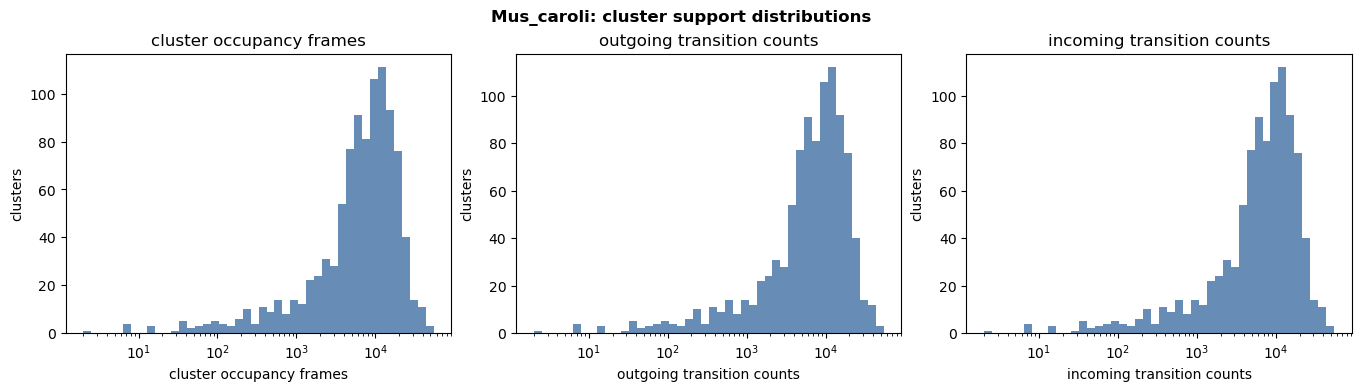

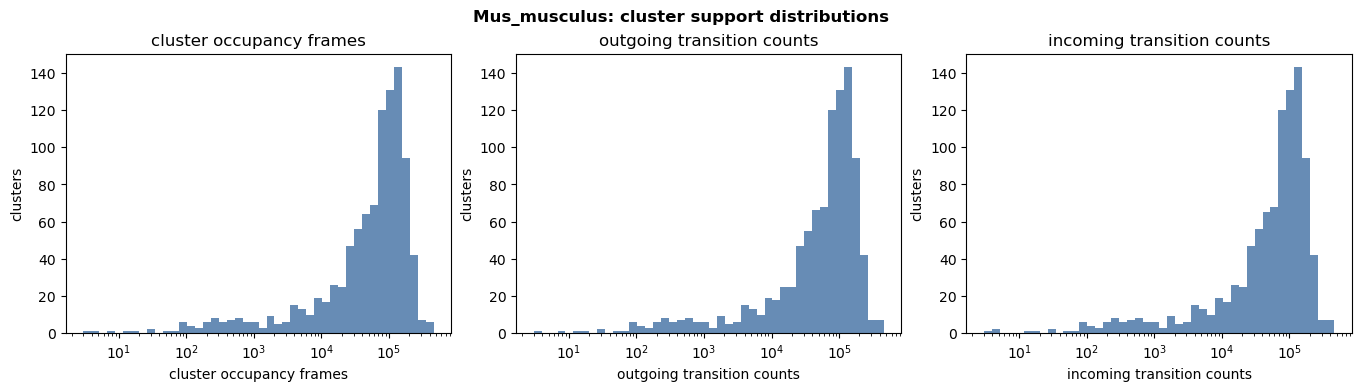

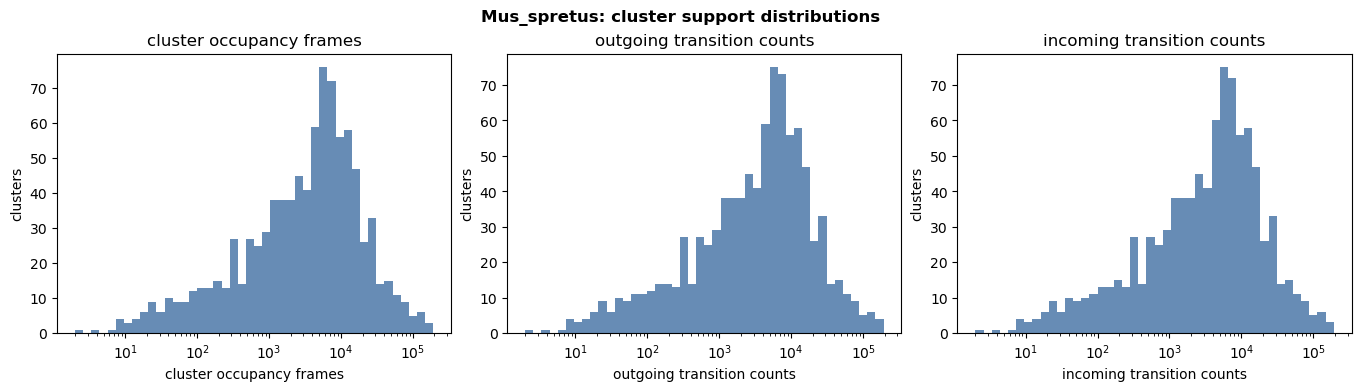

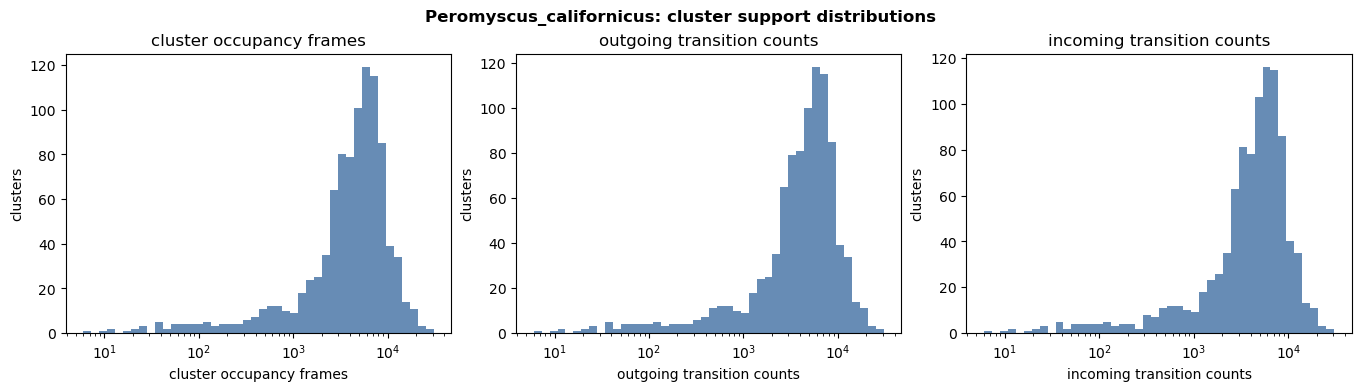

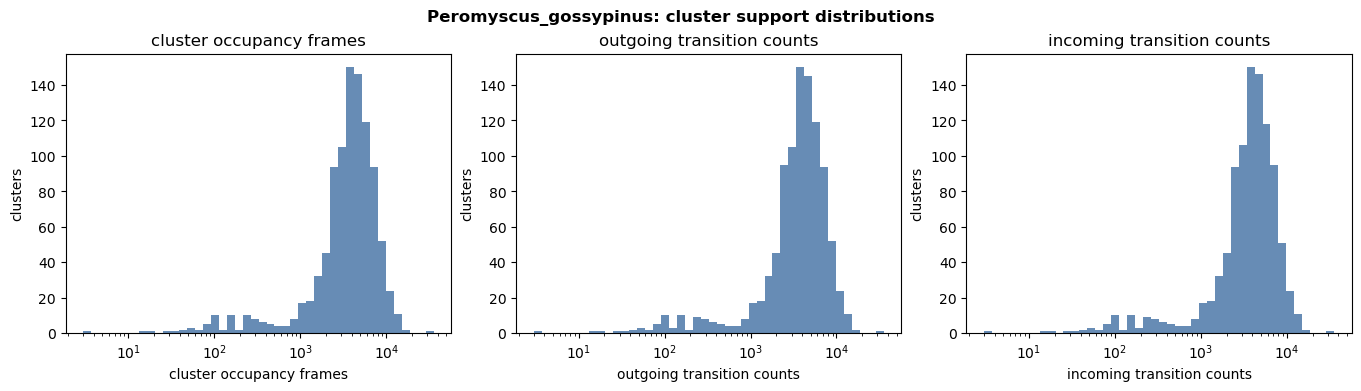

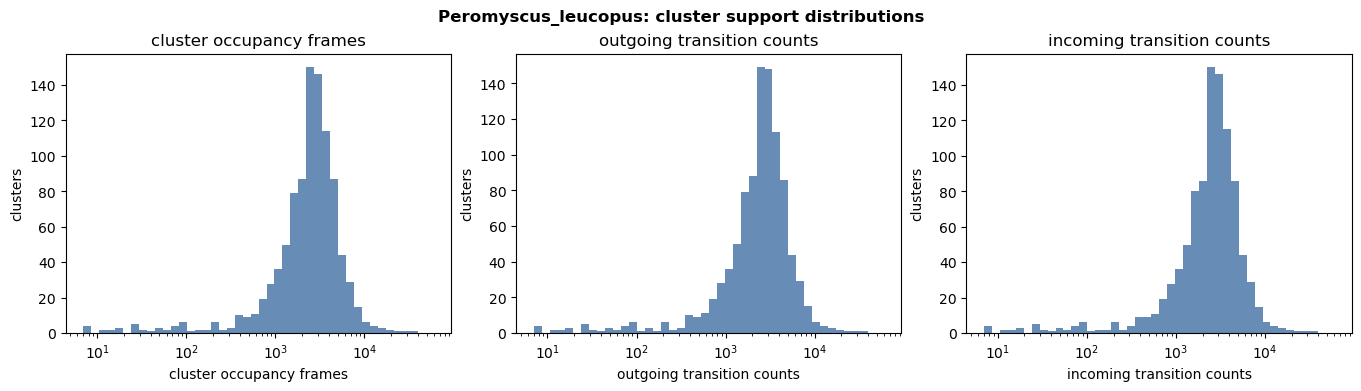

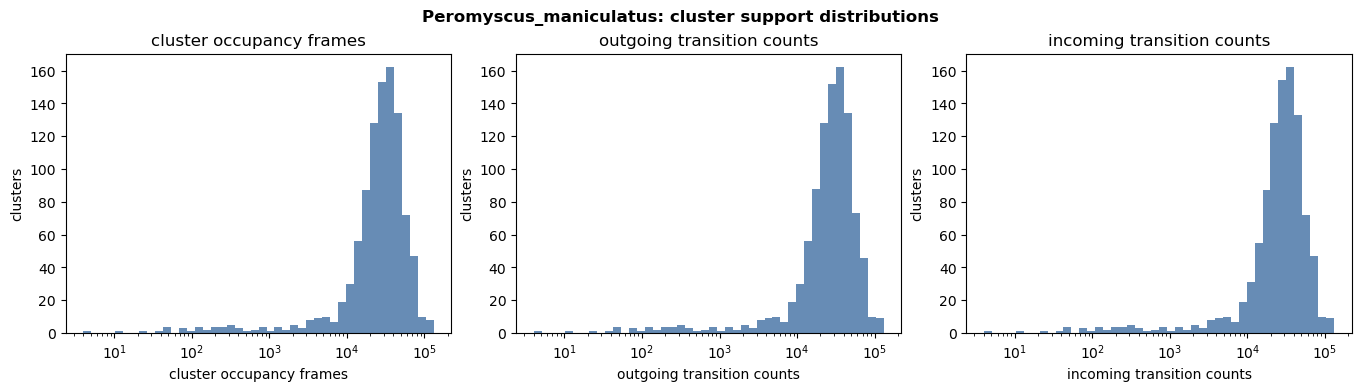

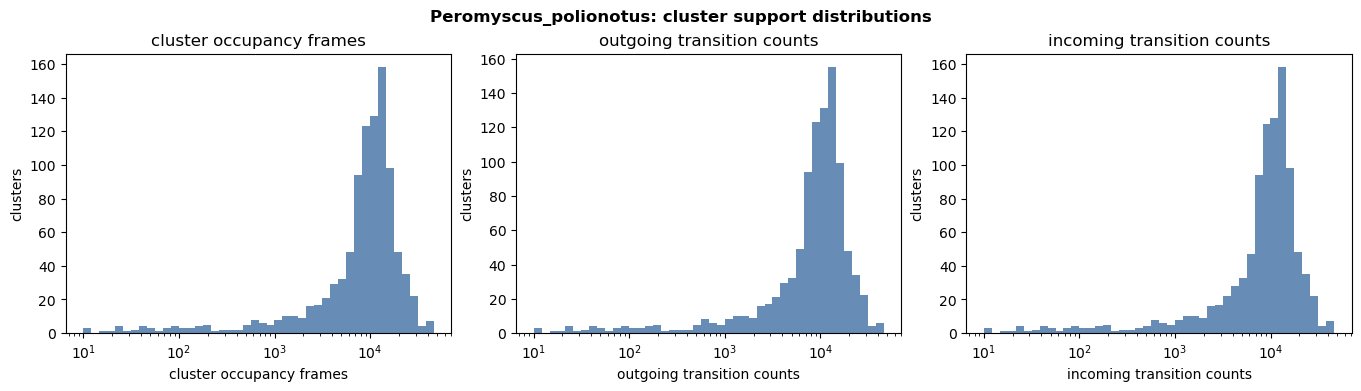

In [49]:
def plot_support_distributions(species):
    counts = np.asarray(species_transition_counts[species])
    occupancy = species_cluster_occupancy[species]
    outgoing = counts.sum(axis=1)
    incoming = counts.sum(axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
    specs = [
        (axes[0], occupancy, 'cluster occupancy frames'),
        (axes[1], outgoing, 'outgoing transition counts'),
        (axes[2], incoming, 'incoming transition counts'),
    ]
    for ax, values, label in specs:
        positive = values[values > 0]
        if positive.size:
            bins = np.logspace(np.log10(max(positive.min(), 1)), np.log10(positive.max()), 45)
            ax.hist(positive, bins=bins, color='#4C78A8', alpha=0.85)
            ax.set_xscale('log')
        ax.set_title(label)
        ax.set_xlabel(label)
        ax.set_ylabel('clusters')
    fig.suptitle(f'{species}: cluster support distributions', fontsize=12, fontweight='bold')
    fig.savefig(OUT_DIR / f'{species}_support_distributions.png', dpi=PLOT_DPI)
    plt.show()


for species in species_names:
    plot_support_distributions(species)

In [50]:
def active_clusters_for_threshold(counts, occupancy, *, min_occupancy=1, min_outgoing=1, require_incoming=False):
    counts = np.asarray(counts, dtype=np.float64)
    occupancy = np.asarray(occupancy, dtype=np.float64)
    outgoing = counts.sum(axis=1)
    incoming = counts.sum(axis=0)

    keep = (occupancy >= float(min_occupancy)) & (outgoing >= float(min_outgoing))
    if require_incoming:
        keep &= incoming > 0
    active = np.flatnonzero(keep)

    # After cutting target clusters, prune rows that no longer have outgoing
    # support inside the retained active set. This avoids artificial self-loops.
    while active.size:
        sub_outgoing = counts[np.ix_(active, active)].sum(axis=1)
        still_supported = sub_outgoing > 0
        if bool(still_supported.all()):
            break
        active = active[still_supported]
    return active


def normalize_counts_on_active_set(counts, active_clusters):
    active_clusters = np.asarray(active_clusters, dtype=int)
    if active_clusters.size == 0:
        return np.empty((0, 0), dtype=np.float64)
    sub_counts = np.asarray(counts, dtype=np.float64)[np.ix_(active_clusters, active_clusters)]
    row_sums = sub_counts.sum(axis=1, keepdims=True)
    if np.any(row_sums[:, 0] <= 0):
        raise ValueError('Active set contains rows with zero outgoing support after pruning.')
    return sub_counts / row_sums


def transition_entropy(T, pi=None, eps=1e-12):
    T = np.asarray(T, dtype=np.float64)
    row_entropy = -(T * np.log2(T + eps)).sum(axis=1)
    if pi is None:
        return float(np.mean(row_entropy)) if row_entropy.size else np.nan, row_entropy
    pi = np.asarray(pi, dtype=np.float64)
    return float(np.sum(pi * row_entropy)), row_entropy


def eigen_summary(T, k=N_EIGENVALUES):
    if T.shape[0] < 2:
        return np.array([], dtype=complex)
    eigvals, _ = pp.leading_eigvecs(T, k=min(int(k), T.shape[0] - 1), drop_stationary=True)
    return eigvals


def padded_transfer(T_active, active_clusters, n_states=N_CLUSTERS):
    full = np.zeros((n_states, n_states), dtype=np.float32)
    if len(active_clusters):
        full[np.ix_(active_clusters, active_clusters)] = np.asarray(T_active, dtype=np.float32)
    return full

In [51]:
def analyze_species_threshold_sweep(species):
    counts = np.asarray(species_transition_counts[species])
    occupancy = species_cluster_occupancy[species]
    total_occupancy = max(float(occupancy.sum()), 1.0)
    total_transitions = max(float(counts.sum()), 1.0)

    rows = []
    previous_full_T = None
    for min_occupancy in MIN_OCCUPANCY_SWEEP:
        for min_outgoing in MIN_OUTGOING_SWEEP:
            active = active_clusters_for_threshold(
                counts,
                occupancy,
                min_occupancy=min_occupancy,
                min_outgoing=min_outgoing,
                require_incoming=REQUIRE_INCOMING_SUPPORT,
            )
            if active.size < 2:
                row = {
                    'species': species,
                    'min_occupancy': int(min_occupancy),
                    'min_outgoing': int(min_outgoing),
                    'n_active_clusters': int(active.size),
                    'status': 'too_few_active_clusters',
                }
                rows.append(row)
                previous_full_T = None
                continue

            T_active = normalize_counts_on_active_set(counts, active)
            pi = pp.stationary_distribution(T_active)
            weighted_entropy, row_entropy = transition_entropy(T_active, pi=pi)
            mean_entropy, _ = transition_entropy(T_active, pi=None)
            eigvals = eigen_summary(T_active)
            abs_eigs = np.abs(eigvals)
            spectral_gap_2_3 = float(abs_eigs[0] - abs_eigs[1]) if abs_eigs.size >= 2 else np.nan
            spectral_gap_3_4 = float(abs_eigs[1] - abs_eigs[2]) if abs_eigs.size >= 3 else np.nan

            full_T = padded_transfer(T_active, active)
            frob_delta = np.nan if previous_full_T is None else float(np.linalg.norm(full_T - previous_full_T))
            previous_full_T = full_T

            sub_counts = counts[np.ix_(active, active)]
            row = {
                'species': species,
                'min_occupancy': int(min_occupancy),
                'min_outgoing': int(min_outgoing),
                'n_active_clusters': int(active.size),
                'retained_occupancy_frames': int(occupancy[active].sum()),
                'retained_occupancy_fraction': float(occupancy[active].sum() / total_occupancy),
                'retained_within_active_transitions': int(sub_counts.sum()),
                'retained_within_active_transition_fraction': float(sub_counts.sum() / total_transitions),
                'mean_transition_entropy_bits': mean_entropy,
                'stationary_weighted_transition_entropy_bits': weighted_entropy,
                'pi_max': float(pi.max()),
                'pi_effective_clusters': float(1.0 / np.sum(pi ** 2)),
                'spectral_gap_abs_lambda2_lambda3': spectral_gap_2_3,
                'spectral_gap_abs_lambda3_lambda4': spectral_gap_3_4,
                'frobenius_delta_from_previous_threshold': frob_delta,
                'status': 'ok',
            }
            for i, value in enumerate(eigvals, start=2):
                row[f'lambda_{i}_real'] = float(np.real(value))
                row[f'lambda_{i}_imag'] = float(np.imag(value))
                row[f'lambda_{i}_abs'] = float(np.abs(value))
            rows.append(row)
    return pd.DataFrame(rows)


sweep_results = pd.concat(
    [analyze_species_threshold_sweep(species) for species in species_names],
    ignore_index=True,
)
sweep_results.to_csv(OUT_DIR / 'threshold_sweep_eigen_entropy_convergence.csv', index=False)
display(sweep_results.head(20))

,species,min_occupancy,min_outgoing,n_active_clusters,retained_occupancy_frames,retained_occupancy_fraction,retained_within_active_transitions,retained_within_active_transition_fraction,mean_transition_entropy_bits,stationary_weighted_transition_entropy_bits,...,lambda_18_abs,lambda_19_real,lambda_19_imag,lambda_19_abs,lambda_20_real,lambda_20_imag,lambda_20_abs,lambda_21_real,lambda_21_imag,lambda_21_abs
0,Mus_caroli,1,1,986,9288209,1.000000,9284609,1.000000,7.515318,8.356441,...,0.100530,0.098805,0.002808,0.098845,0.098805,-0.002808,0.098845,0.098638,0.000000,0.098638
1,Mus_caroli,1,5,985,9288207,1.000000,9284605,1.000000,7.522947,8.356441,...,0.100530,0.098806,0.002808,0.098845,0.098806,-0.002808,0.098845,0.098639,0.000000,0.098639
2,Mus_caroli,1,10,981,9288177,0.999997,9284545,0.999993,7.551519,8.356457,...,0.100755,0.098889,0.003692,0.098958,0.098889,-0.003692,0.098958,0.098282,0.000000,0.098282
3,Mus_caroli,1,25,978,9288136,0.999992,9284463,0.999984,7.572498,8.356477,...,0.100745,0.098875,0.003649,0.098942,0.098875,-0.003649,0.098942,0.098318,0.000000,0.098318
4,Mus_caroli,1,50,972,9287926,0.999970,9284043,0.999939,7.611184,8.356574,...,0.100785,0.099438,0.000000,0.099438,0.098294,0.003307,0.098350,0.098294,-0.003307,0.098350
5,Mus_caroli,1,100,959,9287011,0.999871,9282213,0.999742,7.677586,8.356812,...,0.100126,0.097041,0.024662,0.100126,0.098281,0.000000,0.098281,0.091621,-0.012637,0.092489
6,Mus_caroli,1,250,939,9283521,0.999495,9275233,0.998990,7.762953,8.357638,...,0.099065,0.097864,0.006408,0.098074,0.097864,-0.006408,0.098074,0.092045,0.025741,0.095577
7,Mus_caroli,1,500,913,9273745,0.998443,9255799,0.996897,7.853686,8.359197,...,0.096780,0.093920,-0.023353,0.096780,0.096119,0.008212,0.096469,0.096119,-0.008212,0.096469
8,Mus_caroli,1,1000,878,9247725,0.995641,9204608,0.991383,7.938104,8.360634,...,0.093466,0.091584,-0.018661,0.093466,0.088688,0.011722,0.089459,0.088688,-0.011722,0.089459
9,Mus_musculus,1,1,996,85753801,1.000000,85731481,1.000000,8.177681,8.554482,...,0.170531,0.161063,0.000000,0.161063,0.154822,0.000000,0.154822,-0.153515,0.000000,0.153515


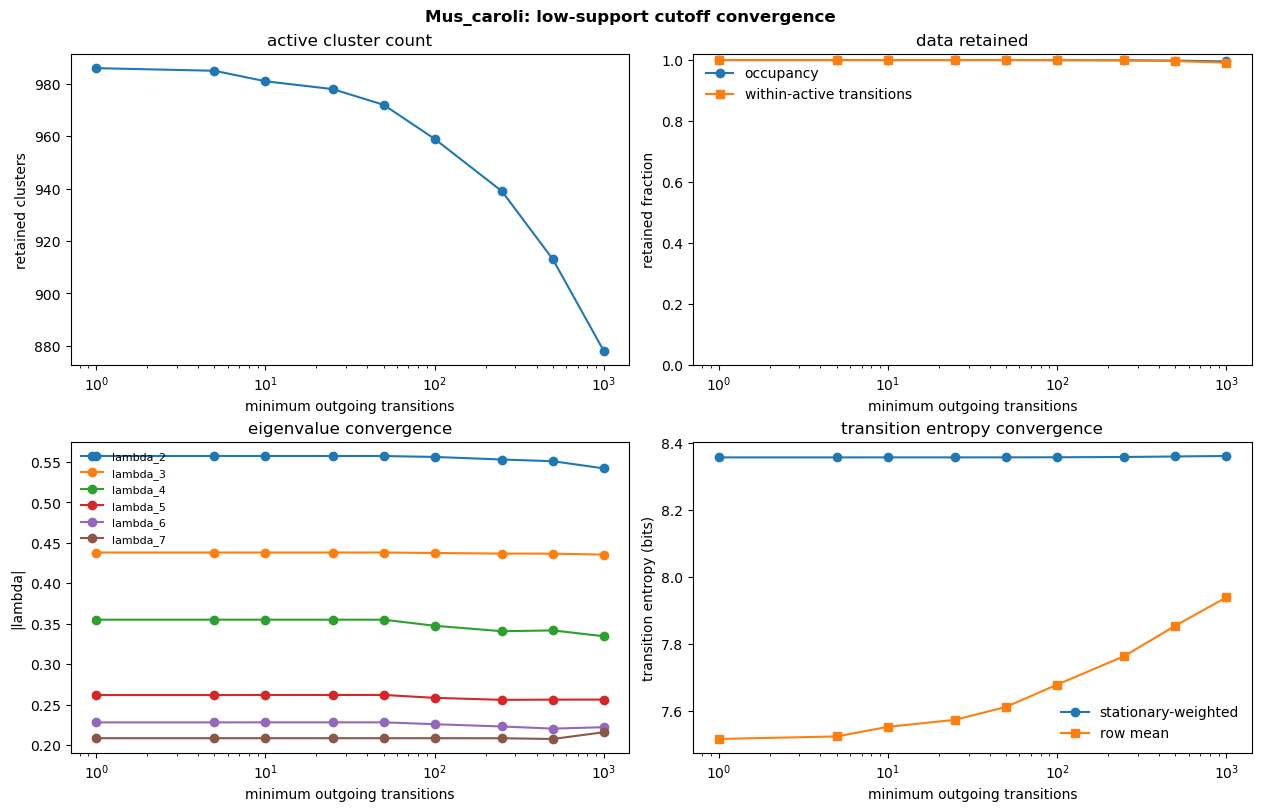

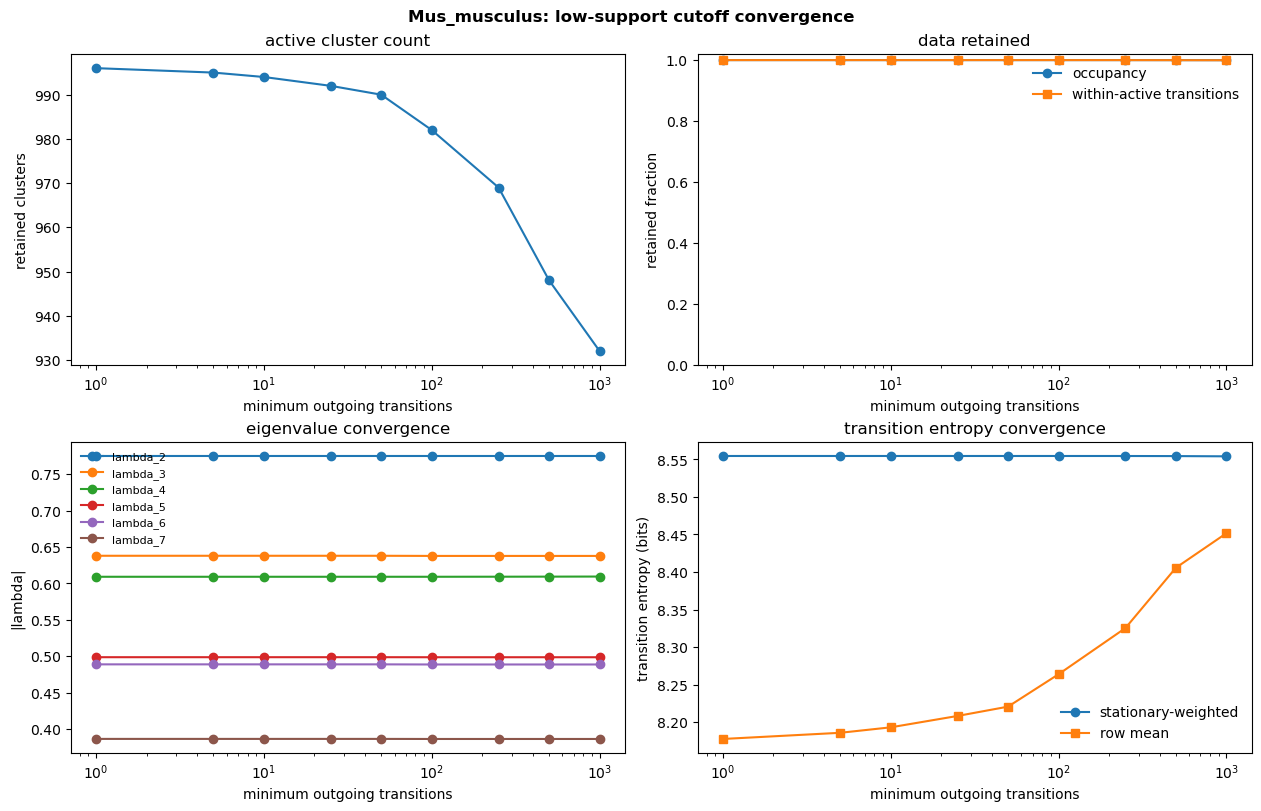

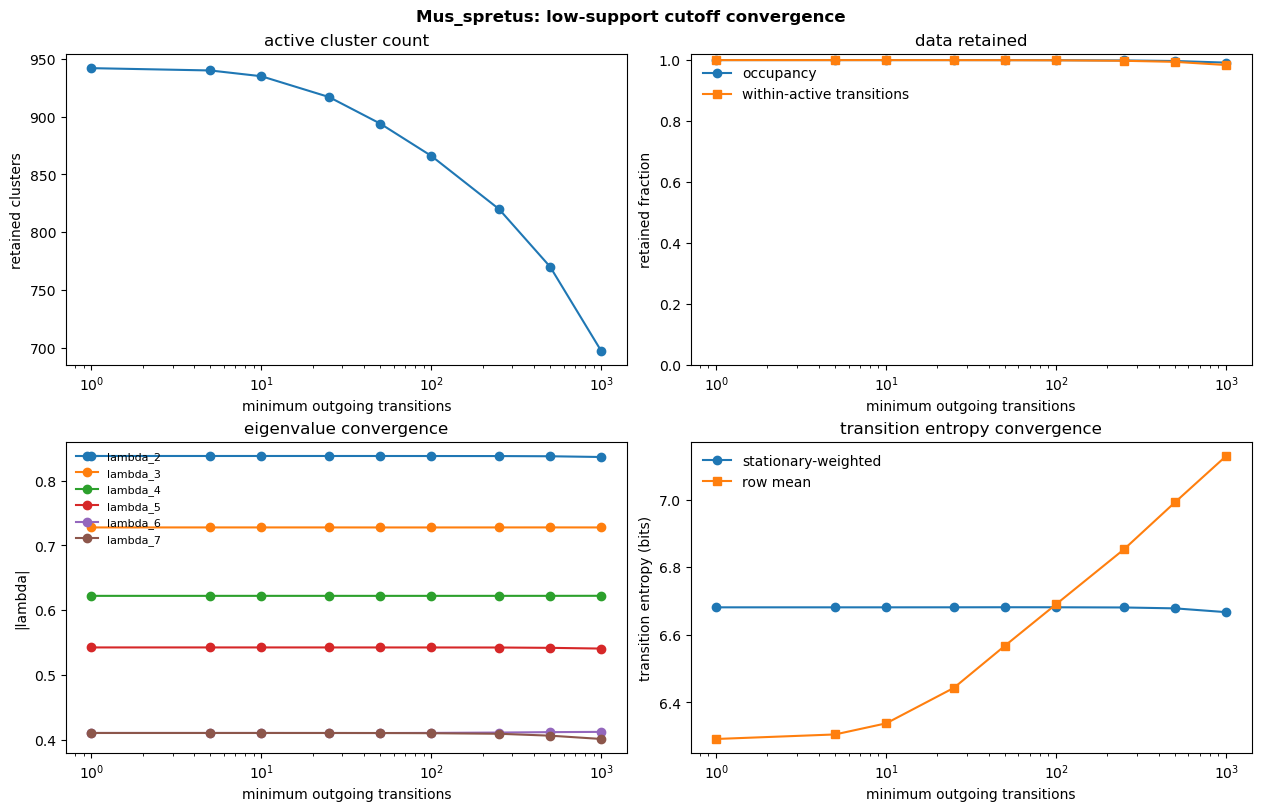

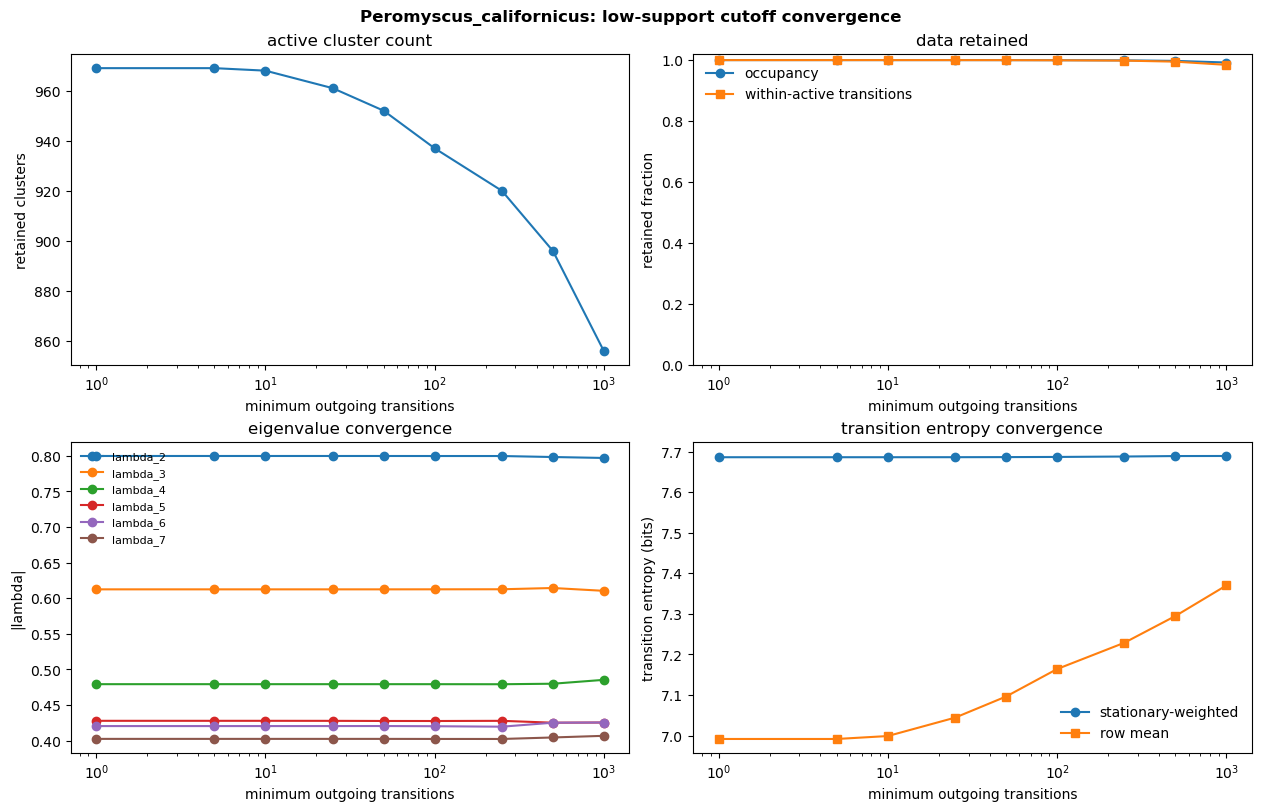

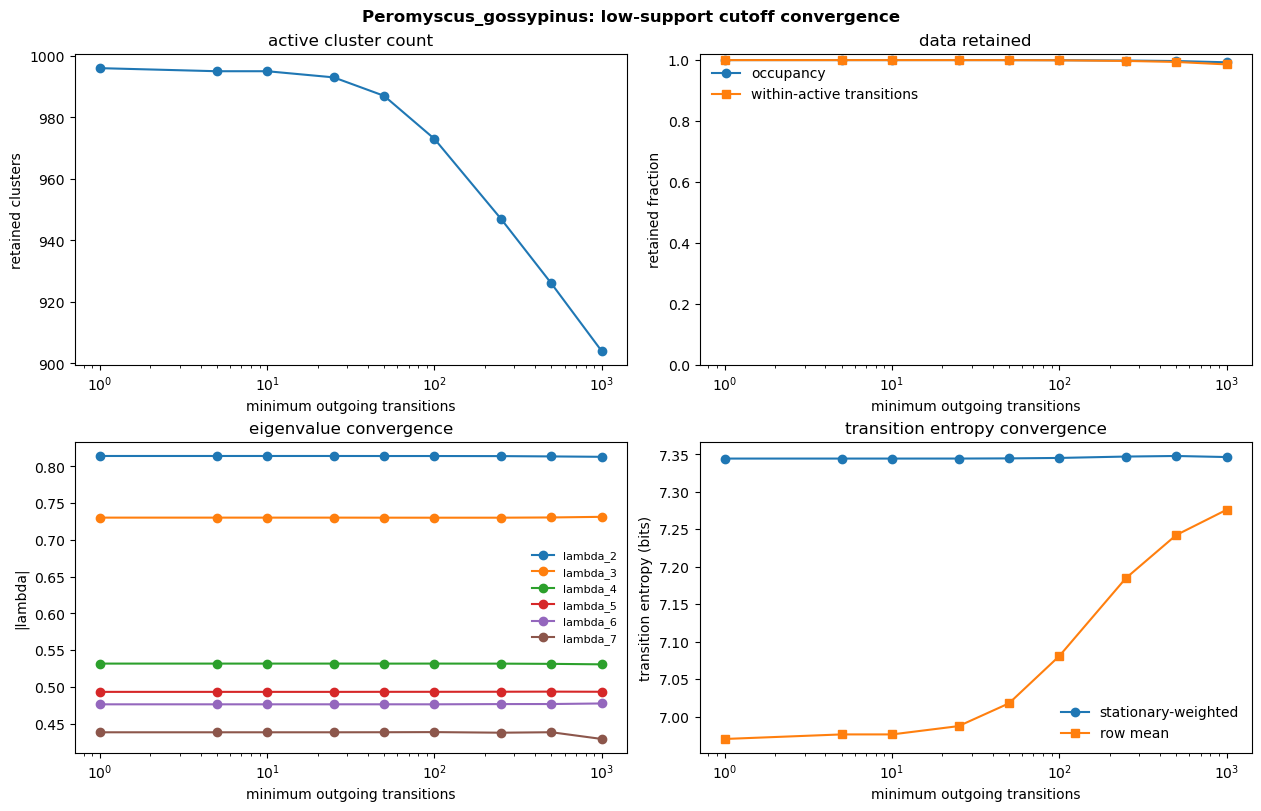

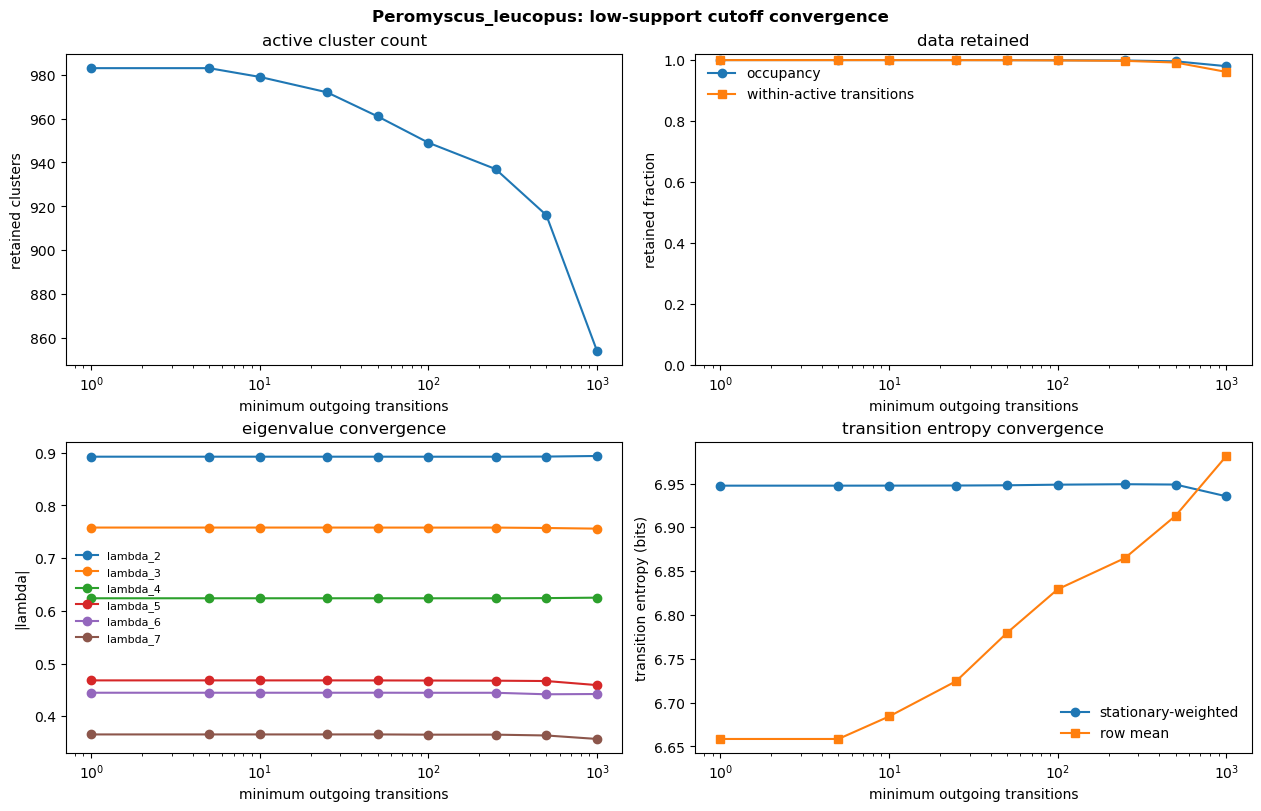

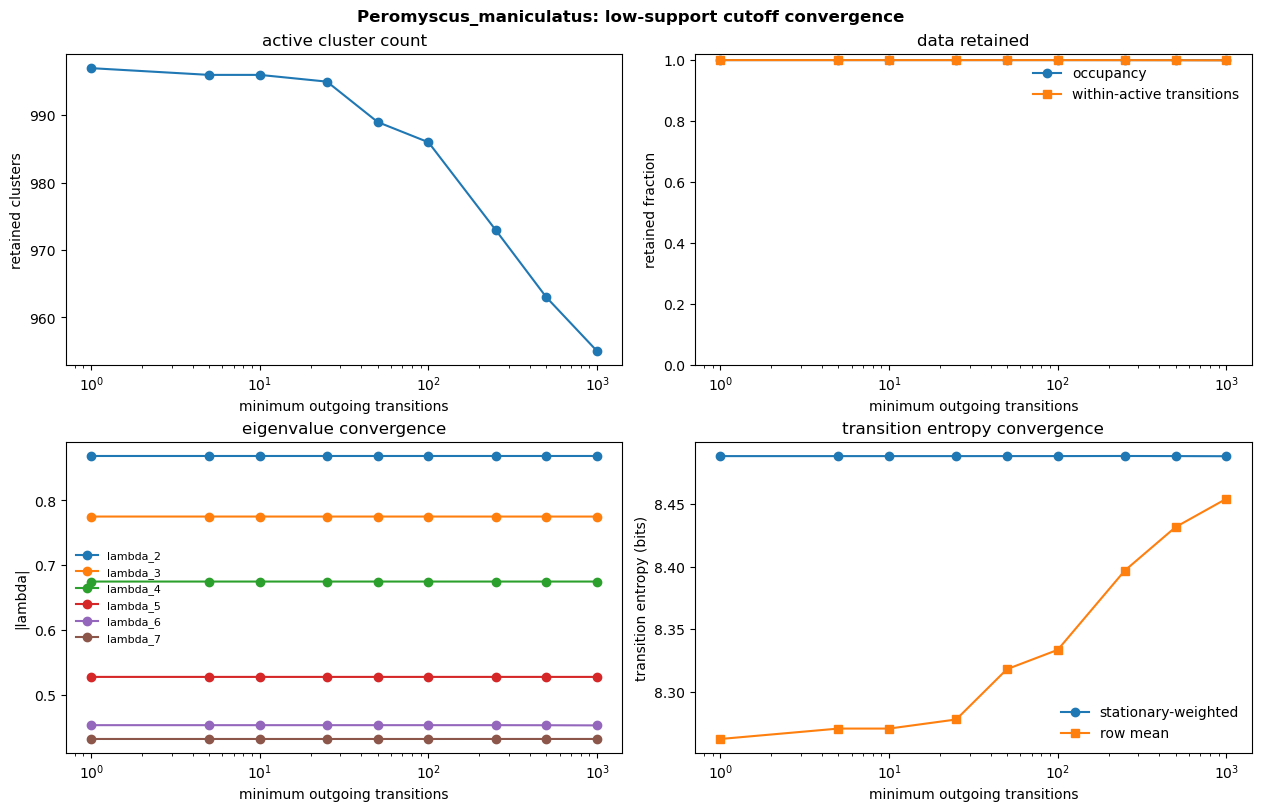

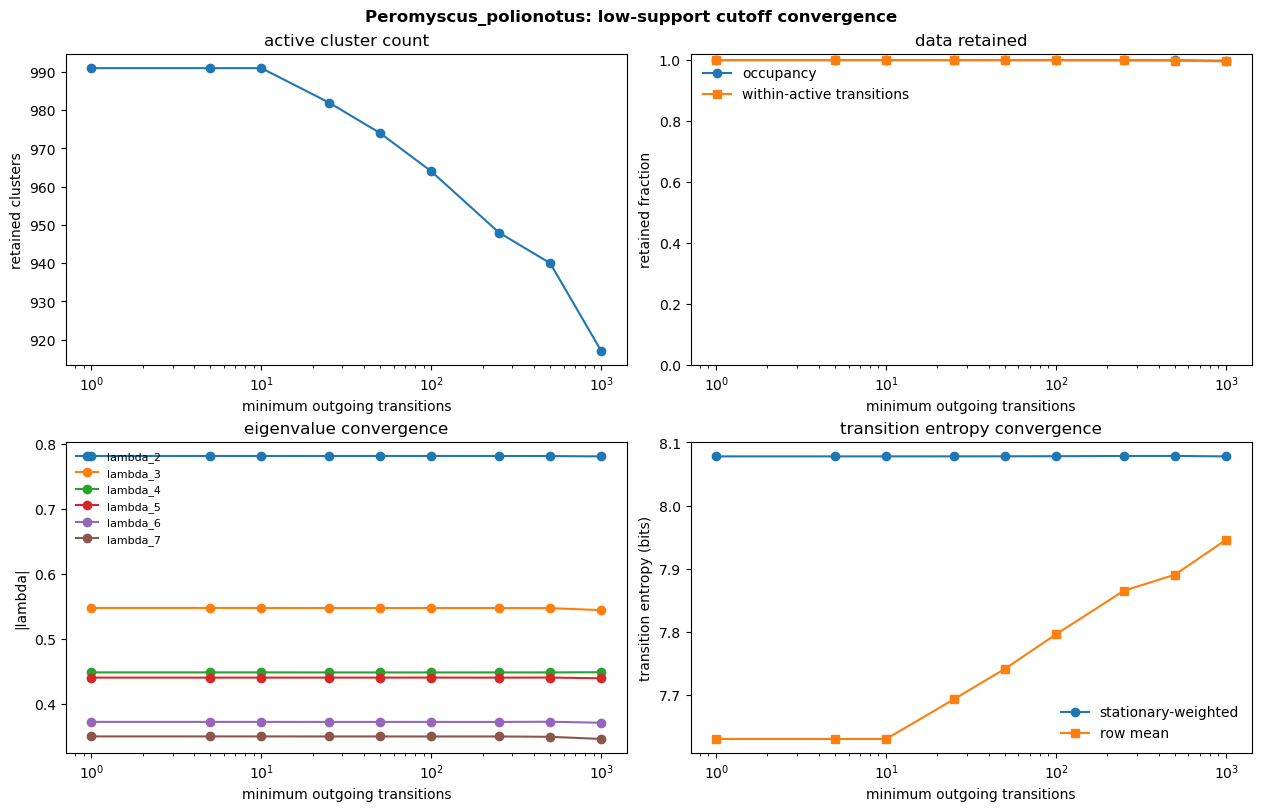

In [52]:
def plot_species_convergence(species):
    df = sweep_results.loc[
        (sweep_results['species'] == species) & (sweep_results['status'] == 'ok')
    ].copy()
    if df.empty:
        print(f'No valid sweep rows for {species}')
        return

    x = df['min_outgoing'].to_numpy(int)
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.0), constrained_layout=True)

    ax = axes[0, 0]
    ax.plot(x, df['n_active_clusters'], marker='o')
    ax.set_xscale('log')
    ax.set_xlabel('minimum outgoing transitions')
    ax.set_ylabel('retained clusters')
    ax.set_title('active cluster count')

    ax = axes[0, 1]
    ax.plot(x, df['retained_occupancy_fraction'], marker='o', label='occupancy')
    ax.plot(x, df['retained_within_active_transition_fraction'], marker='s', label='within-active transitions')
    ax.set_xscale('log')
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('minimum outgoing transitions')
    ax.set_ylabel('retained fraction')
    ax.set_title('data retained')
    ax.legend(frameon=False)

    ax = axes[1, 0]
    lambda_cols = [col for col in df.columns if col.startswith('lambda_') and col.endswith('_abs')]
    lambda_cols = lambda_cols[:6]
    for col in lambda_cols:
        ax.plot(x, df[col], marker='o', label=col.replace('_abs', ''))
    ax.set_xscale('log')
    ax.set_xlabel('minimum outgoing transitions')
    ax.set_ylabel('|lambda|')
    ax.set_title('eigenvalue convergence')
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1, 1]
    ax.plot(x, df['stationary_weighted_transition_entropy_bits'], marker='o', label='stationary-weighted')
    ax.plot(x, df['mean_transition_entropy_bits'], marker='s', label='row mean')
    ax.set_xscale('log')
    ax.set_xlabel('minimum outgoing transitions')
    ax.set_ylabel('transition entropy (bits)')
    ax.set_title('transition entropy convergence')
    ax.legend(frameon=False)

    fig.suptitle(f'{species}: low-support cutoff convergence', fontsize=12, fontweight='bold')
    fig.savefig(OUT_DIR / f'{species}_threshold_convergence.png', dpi=PLOT_DPI)
    plt.show()


for species in species_names:
    plot_species_convergence(species)

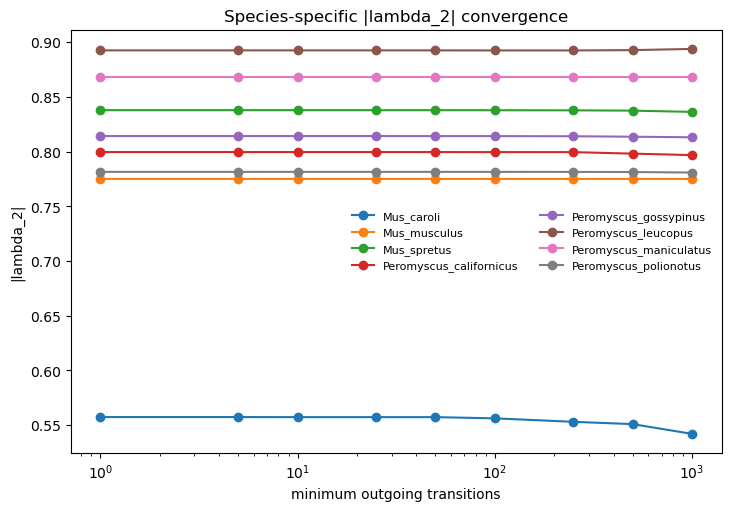

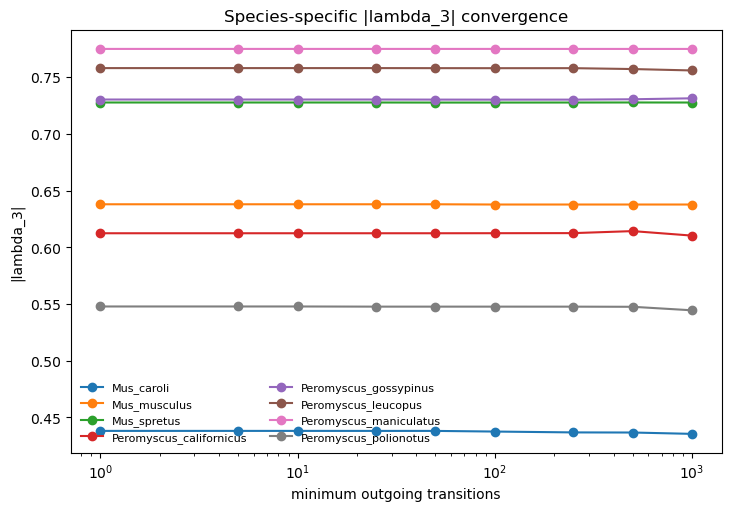

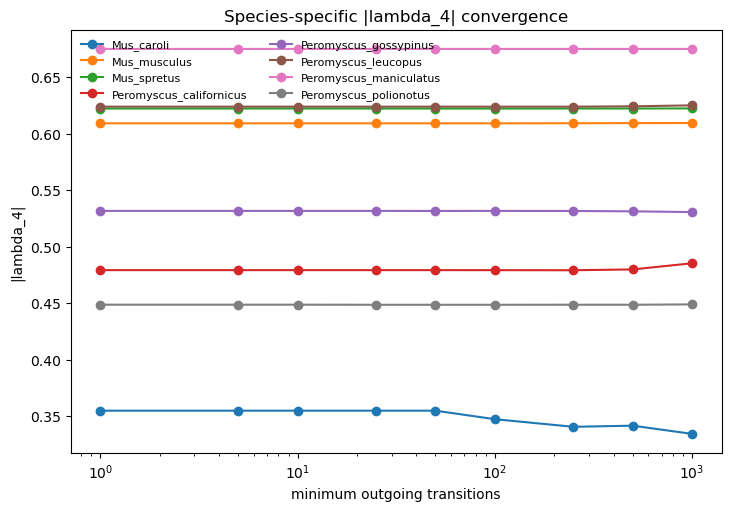

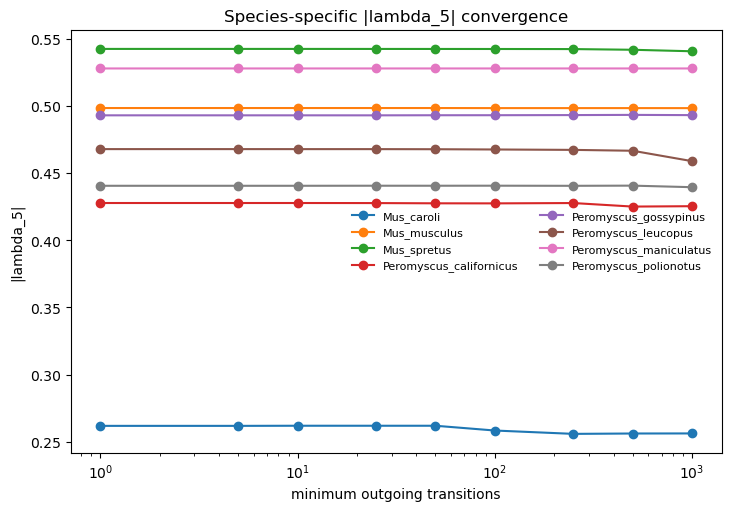

In [53]:
def plot_all_species_eigen_convergence(lambda_index=2):
    col = f'lambda_{lambda_index}_abs'
    if col not in sweep_results.columns:
        raise ValueError(f'Missing {col}')
    fig, ax = plt.subplots(figsize=(7.2, 5.0), constrained_layout=True)
    for species in species_names:
        df = sweep_results.loc[
            (sweep_results['species'] == species) & (sweep_results['status'] == 'ok')
        ].copy()
        ax.plot(df['min_outgoing'], df[col], marker='o', label=species)
    ax.set_xscale('log')
    ax.set_xlabel('minimum outgoing transitions')
    ax.set_ylabel(f'|lambda_{lambda_index}|')
    ax.set_title(f'Species-specific |lambda_{lambda_index}| convergence')
    ax.legend(frameon=False, fontsize=8, ncol=2)
    fig.savefig(OUT_DIR / f'all_species_lambda_{lambda_index}_convergence.png', dpi=PLOT_DPI)
    plt.show()


for lambda_index in [2, 3, 4, 5]:
    plot_all_species_eigen_convergence(lambda_index=lambda_index)

## Eigenvalue Convergence Diagnostics

These plots make the eigenspectrum threshold sweep easier to read. The heatmap shows how each nontrivial eigenvalue magnitude changes with the low-support cutoff. The drift plot measures threshold-to-threshold change in the leading eigenvalues. The complex-plane plot checks whether apparent convergence in magnitude hides movement in the real/imaginary plane.

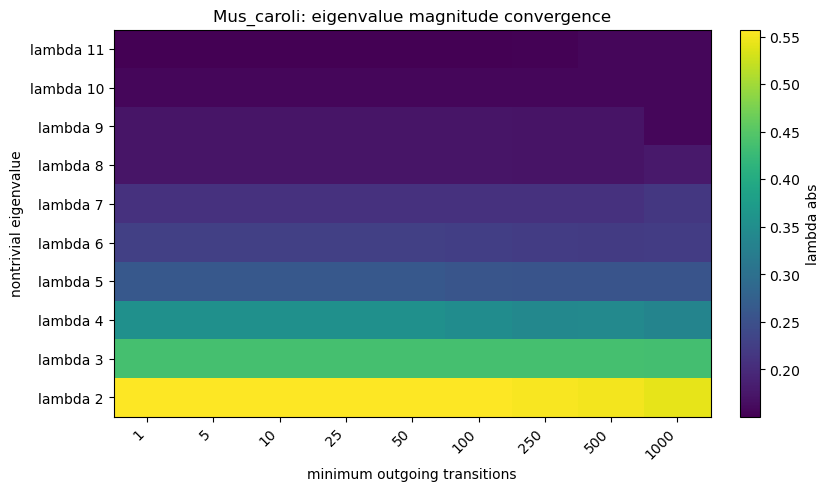

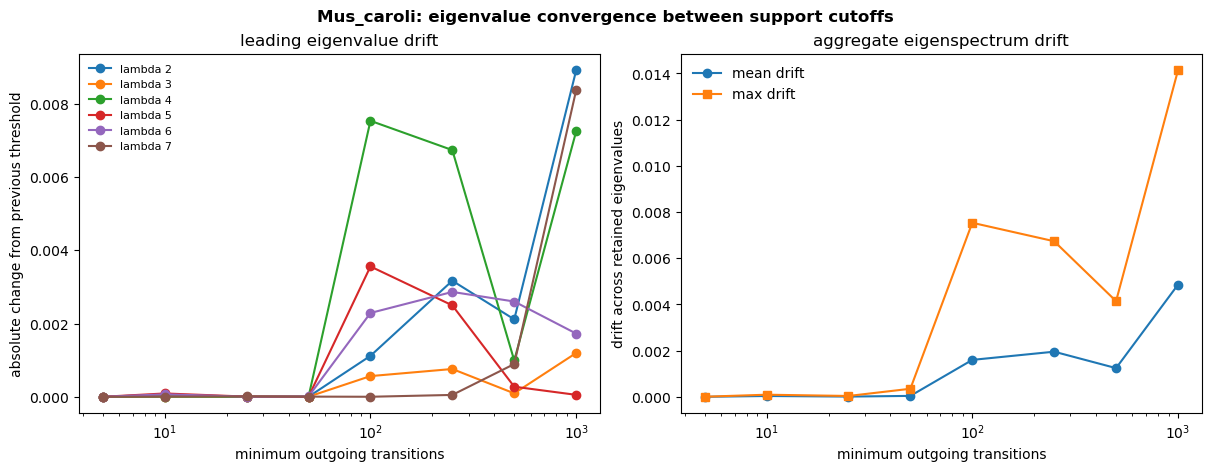

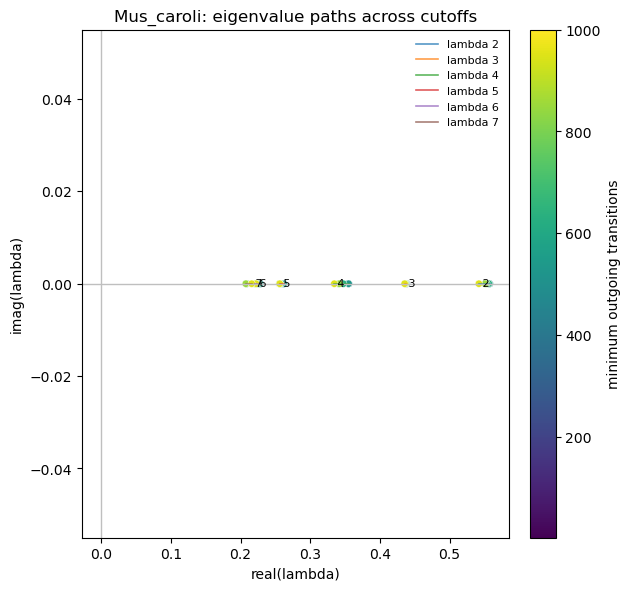

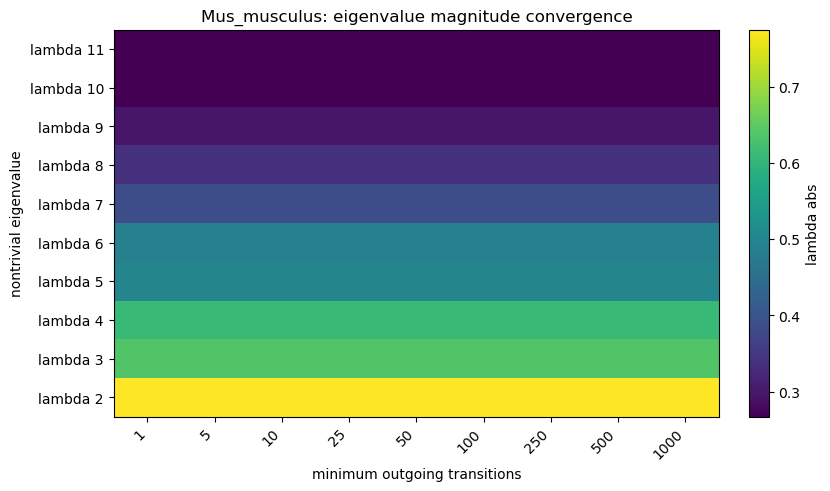

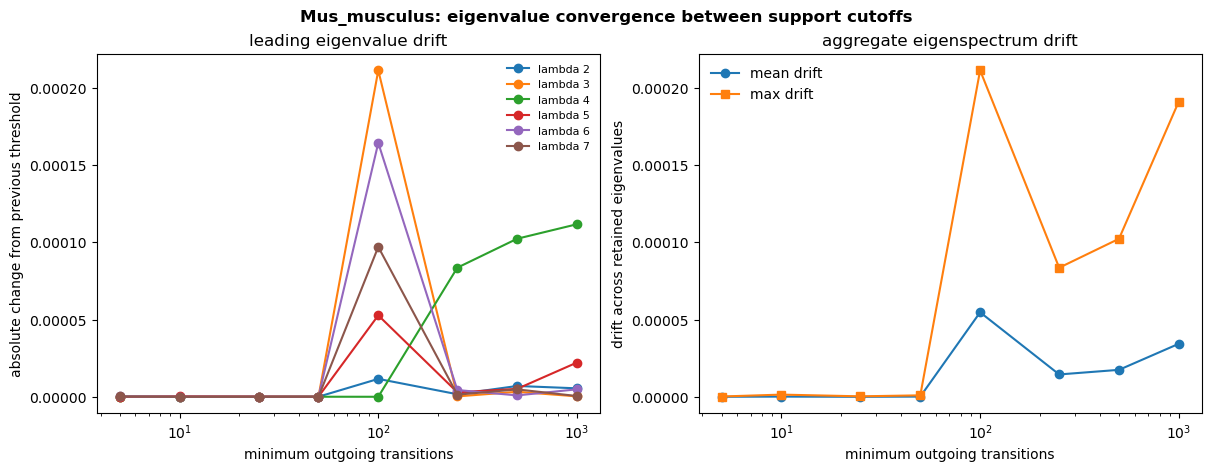

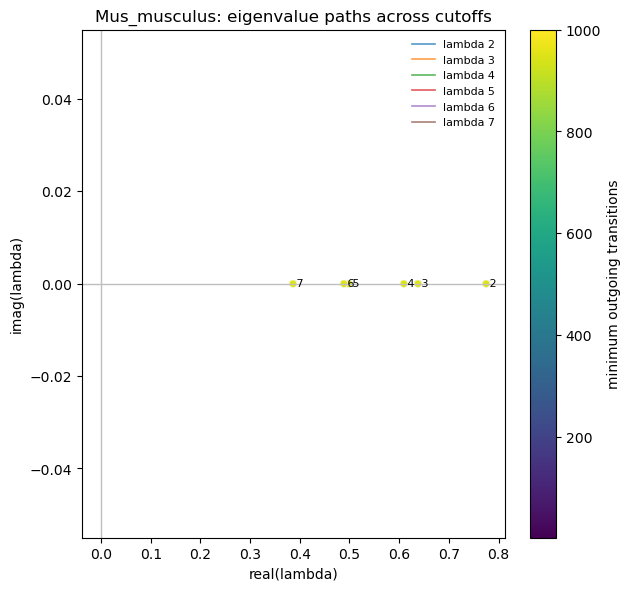

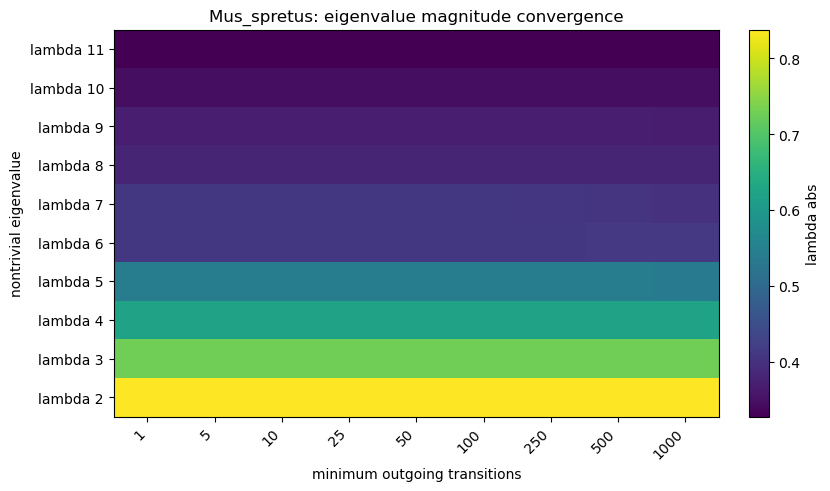

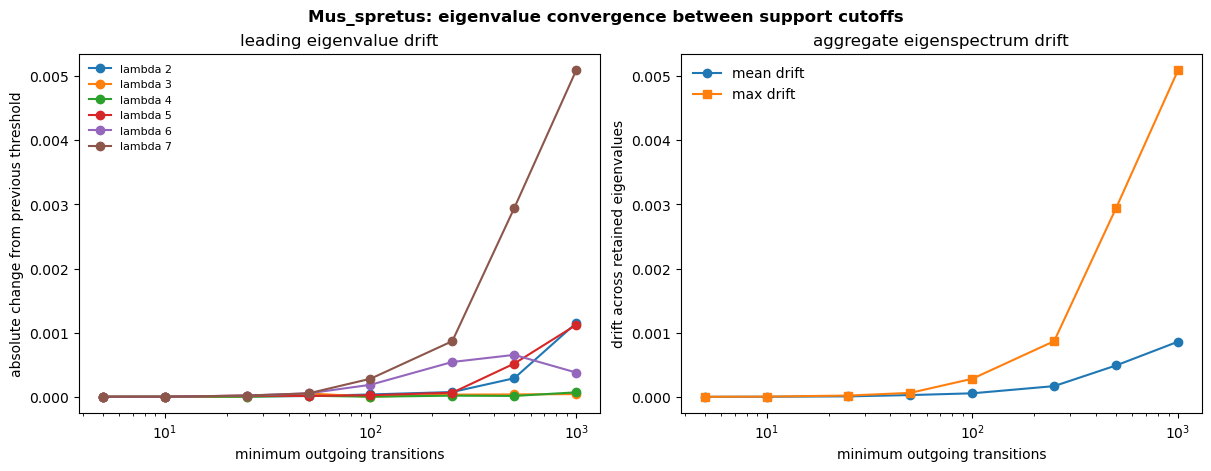

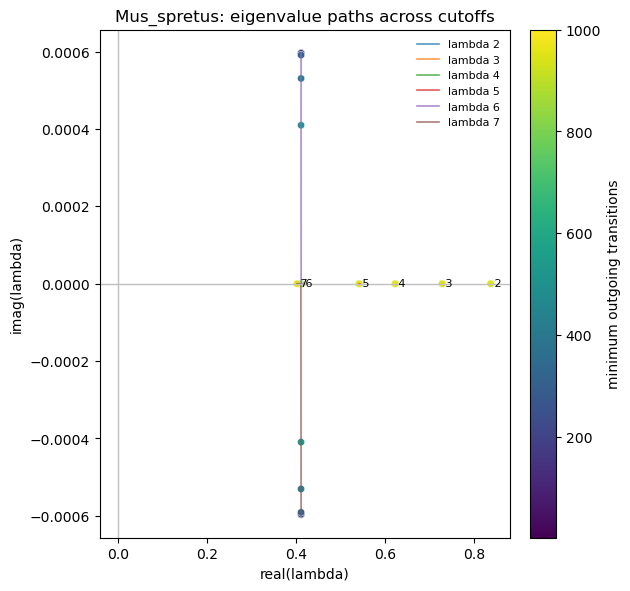

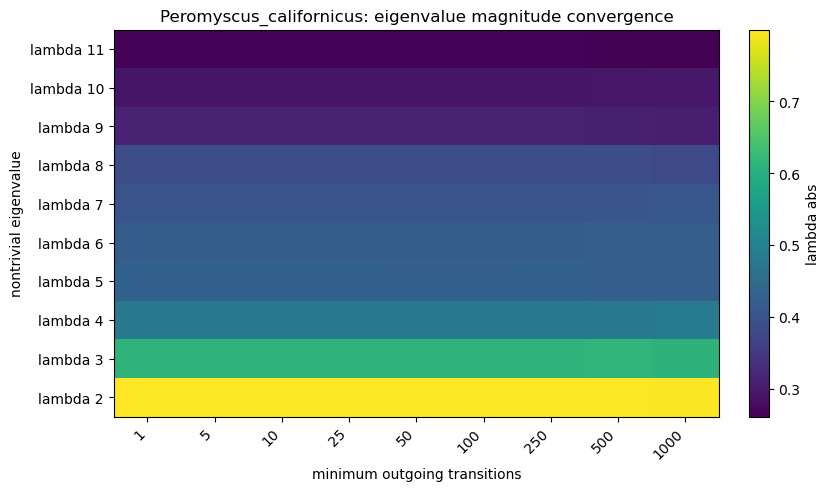

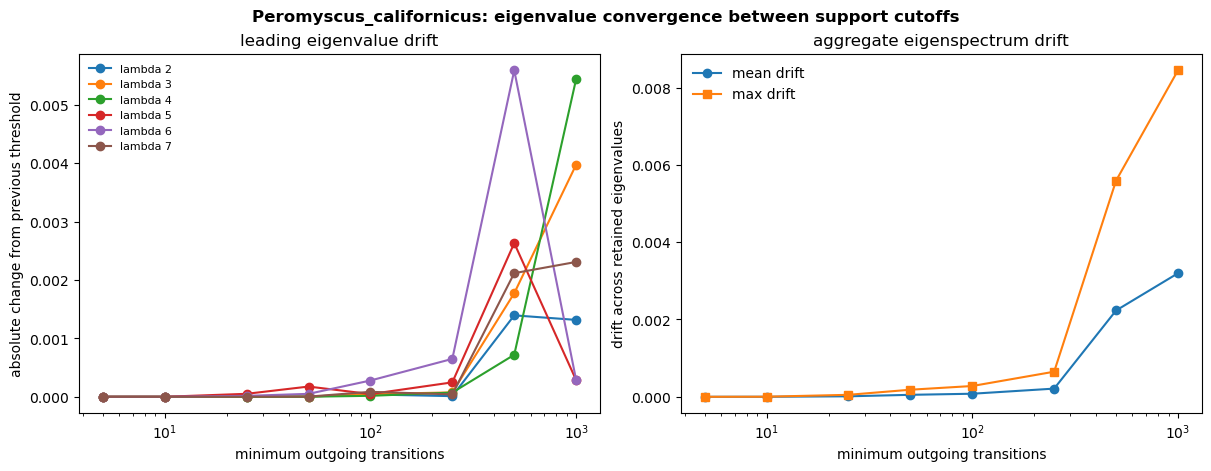

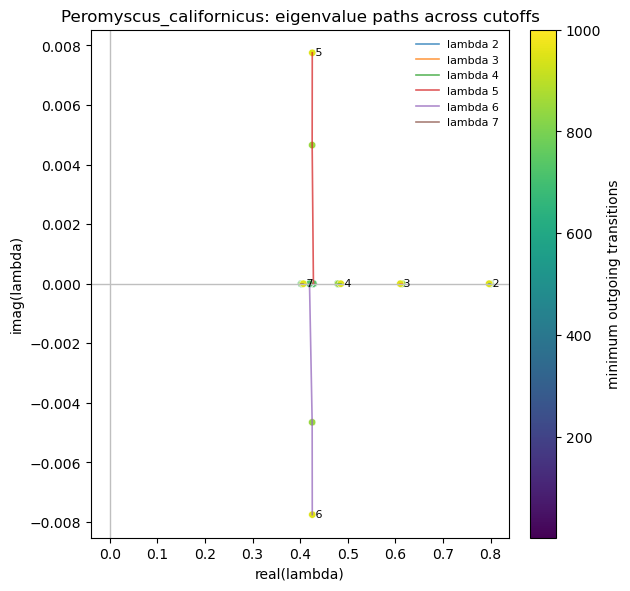

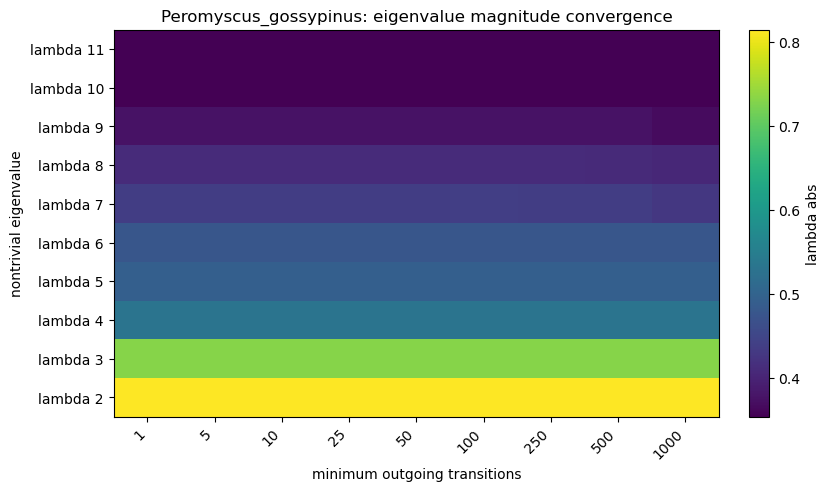

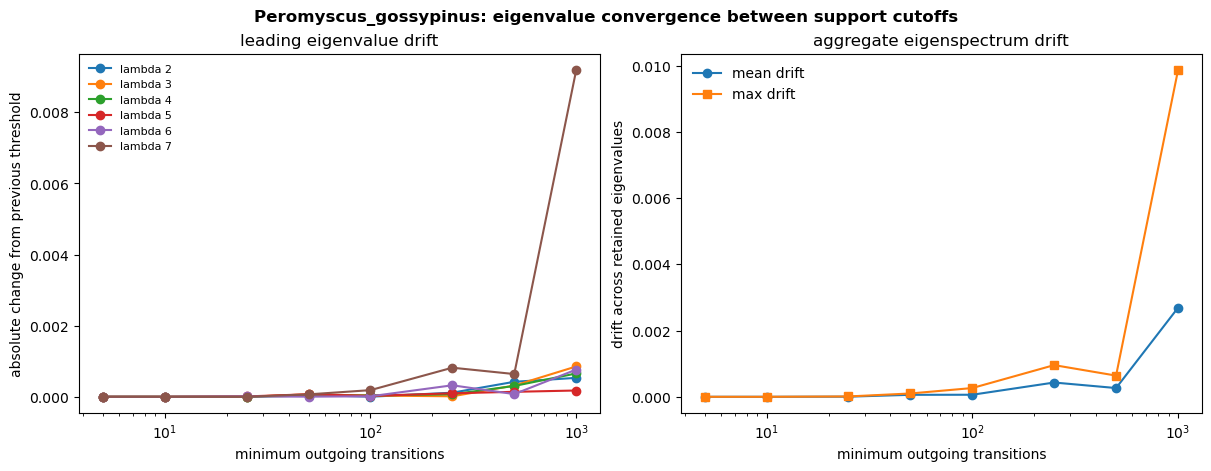

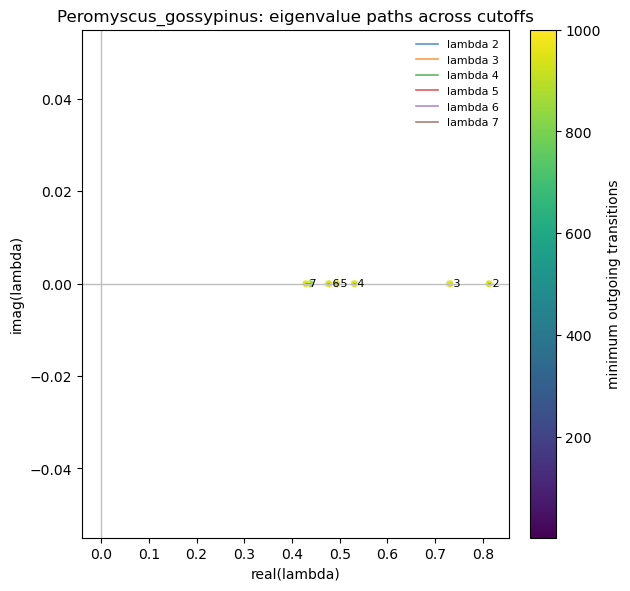

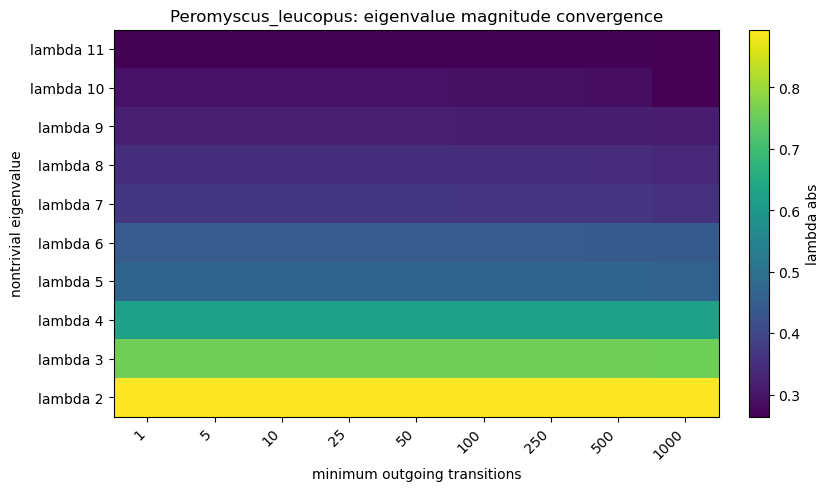

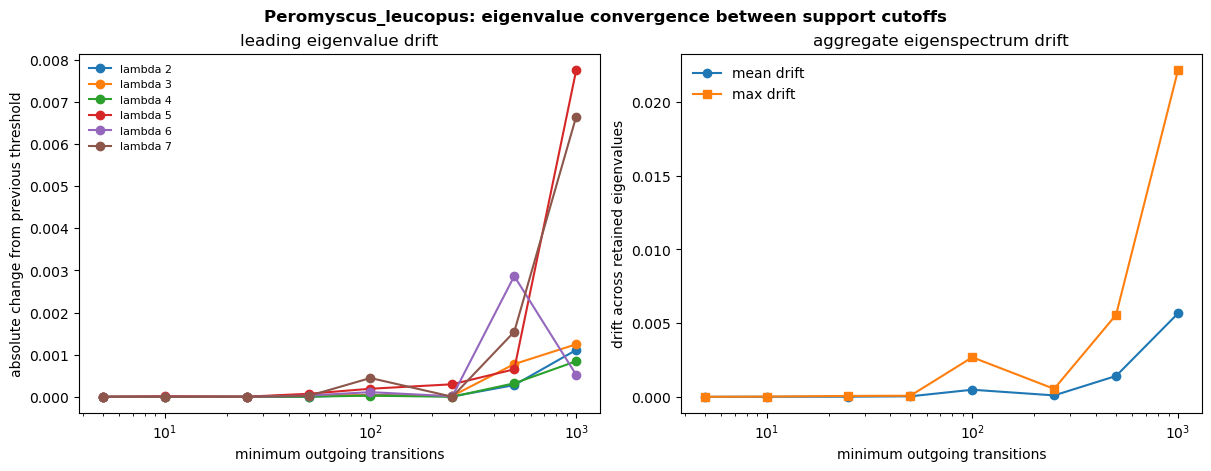

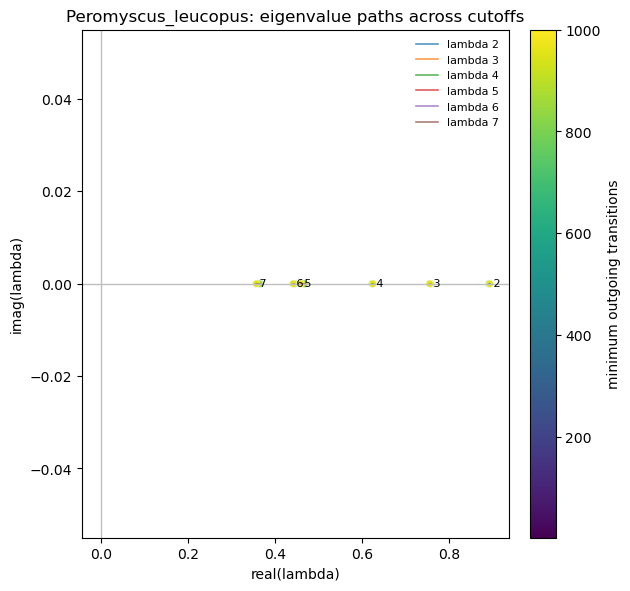

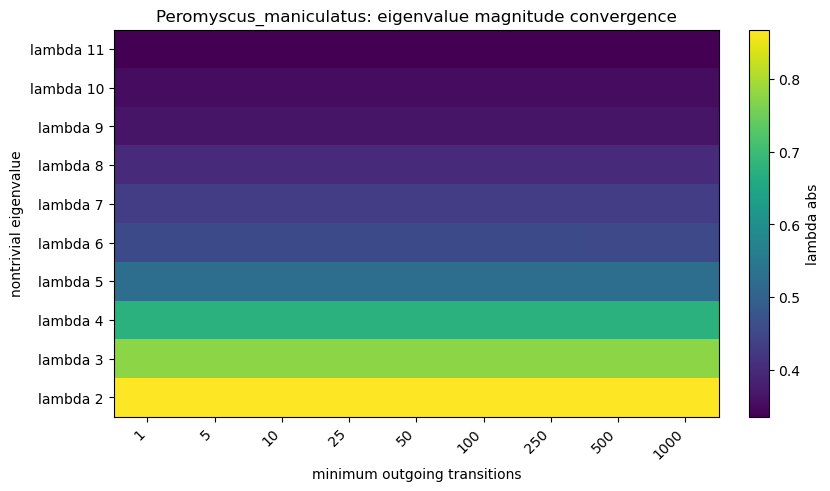

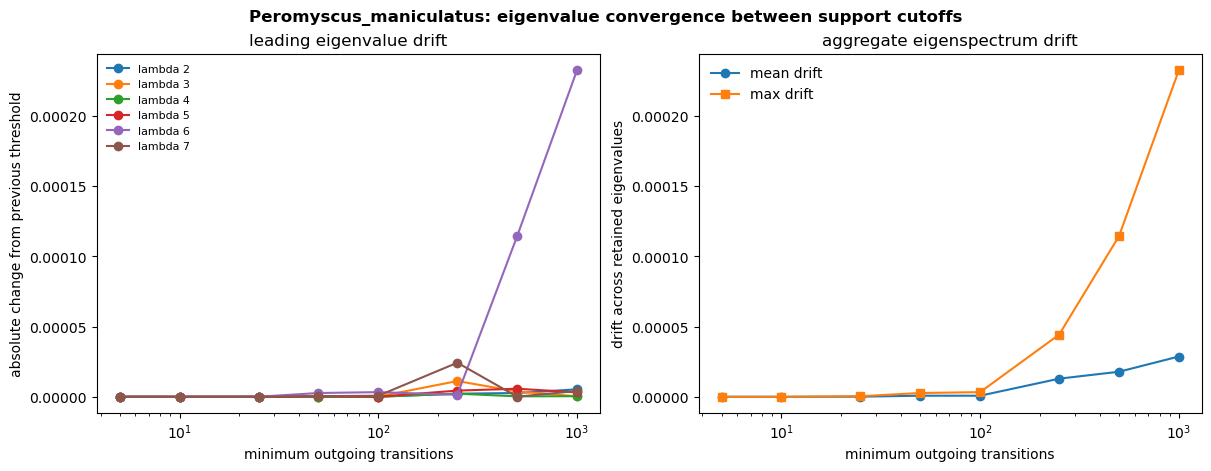

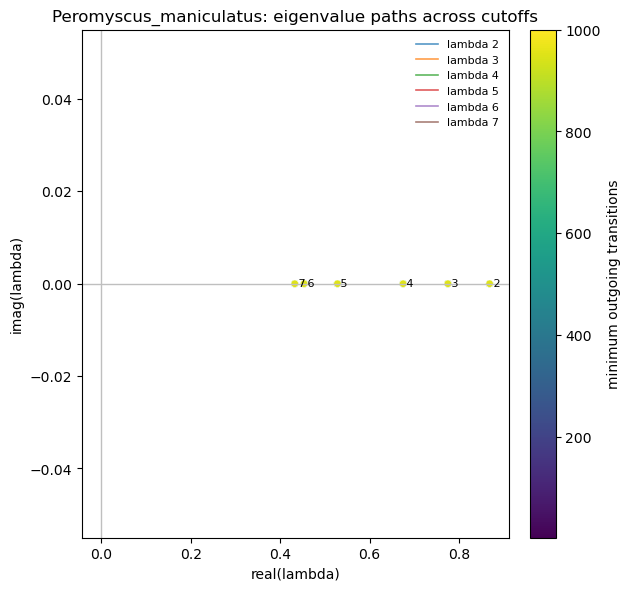

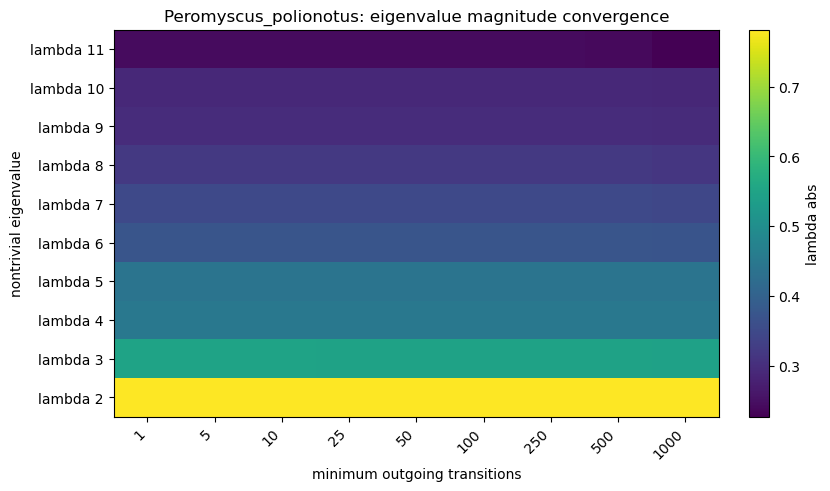

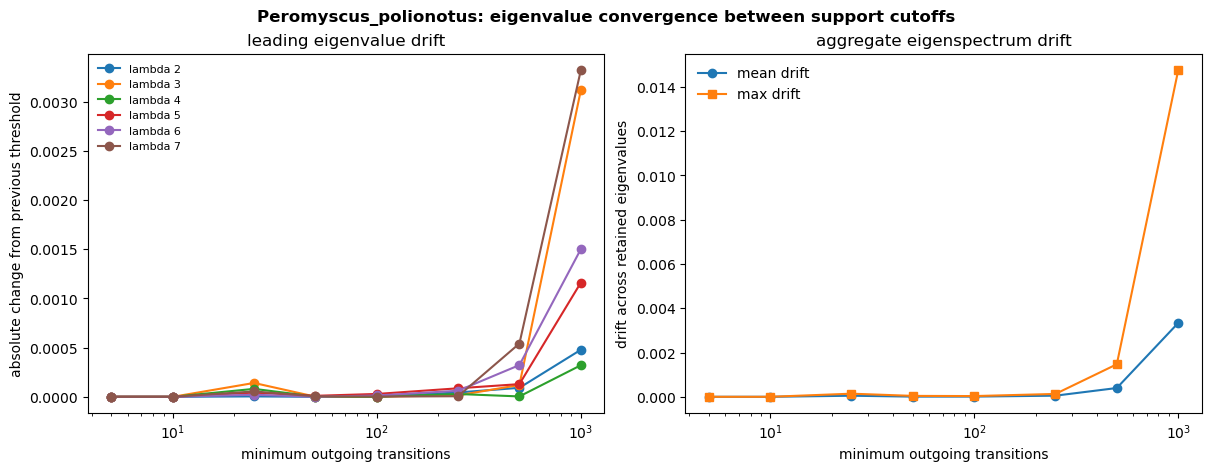

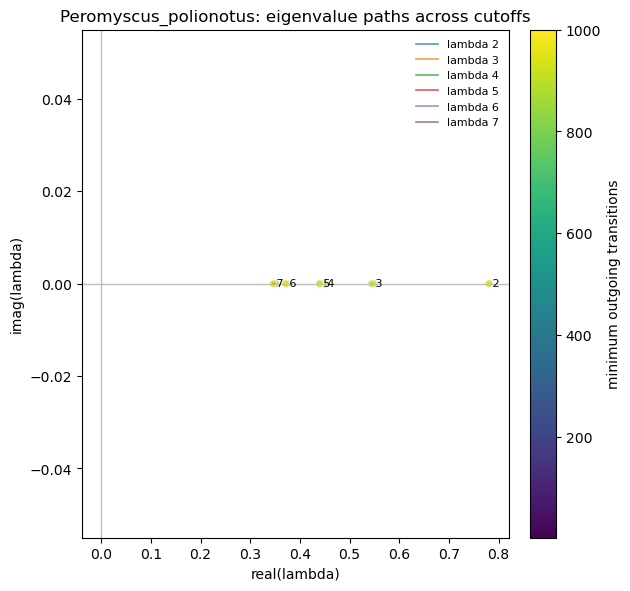

In [54]:
def eigenvalue_columns(df, *, value='abs'):
    suffix = f'_{value}'
    cols = [col for col in df.columns if col.startswith('lambda_') and col.endswith(suffix)]
    return sorted(cols, key=lambda col: int(col.split('_')[1]))


def species_eigen_matrix(species, *, value='abs'):
    df = sweep_results.loc[
        (sweep_results['species'] == species) & (sweep_results['status'] == 'ok')
    ].copy()
    df = df.sort_values(['min_occupancy', 'min_outgoing'])
    cols = eigenvalue_columns(df, value=value)
    values = df[cols].to_numpy(float) if cols else np.empty((len(df), 0))
    eigen_indices = [int(col.split('_')[1]) for col in cols]
    thresholds = df['min_outgoing'].to_numpy(int)
    return df, values, eigen_indices, thresholds


def plot_eigenvalue_heatmap(species, *, value='abs', max_eigenvalues=10):
    df, values, eigen_indices, thresholds = species_eigen_matrix(species, value=value)
    if values.size == 0:
        print(f'No eigenvalue values for {species}')
        return
    values = values[:, :max_eigenvalues]
    eigen_indices = eigen_indices[:max_eigenvalues]

    fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)
    image = ax.imshow(values.T, aspect='auto', origin='lower', cmap='viridis')
    ax.set_xticks(np.arange(len(thresholds)))
    ax.set_xticklabels(thresholds, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(eigen_indices)))
    ax.set_yticklabels([f'lambda {idx}' for idx in eigen_indices])
    ax.set_xlabel('minimum outgoing transitions')
    ax.set_ylabel('nontrivial eigenvalue')
    ax.set_title(f'{species}: eigenvalue magnitude convergence')
    fig.colorbar(image, ax=ax, label=f'lambda {value}')
    fig.savefig(OUT_DIR / f'{species}_eigenvalue_{value}_convergence_heatmap.png', dpi=PLOT_DPI)
    plt.show()


def plot_eigenvalue_drift(species, *, max_eigenvalues=10):
    df, values, eigen_indices, thresholds = species_eigen_matrix(species, value='abs')
    if values.shape[0] < 2 or values.shape[1] == 0:
        print(f'Not enough sweep rows for eigenvalue drift: {species}')
        return
    values = values[:, :max_eigenvalues]
    eigen_indices = eigen_indices[:max_eigenvalues]
    deltas = np.abs(np.diff(values, axis=0))
    x = thresholds[1:]

    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), constrained_layout=True)

    ax = axes[0]
    for j, idx in enumerate(eigen_indices[:6]):
        ax.plot(x, deltas[:, j], marker='o', label=f'lambda {idx}')
    ax.set_xscale('log')
    ax.set_xlabel('minimum outgoing transitions')
    ax.set_ylabel('absolute change from previous threshold')
    ax.set_title('leading eigenvalue drift')
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    ax.plot(x, np.nanmean(deltas, axis=1), marker='o', label='mean drift')
    ax.plot(x, np.nanmax(deltas, axis=1), marker='s', label='max drift')
    ax.set_xscale('log')
    ax.set_xlabel('minimum outgoing transitions')
    ax.set_ylabel('drift across retained eigenvalues')
    ax.set_title('aggregate eigenspectrum drift')
    ax.legend(frameon=False)

    fig.suptitle(f'{species}: eigenvalue convergence between support cutoffs', fontsize=12, fontweight='bold')
    fig.savefig(OUT_DIR / f'{species}_eigenvalue_threshold_drift.png', dpi=PLOT_DPI)
    plt.show()


def plot_eigenvalue_complex_paths(species, *, max_eigenvalues=6):
    df = sweep_results.loc[
        (sweep_results['species'] == species) & (sweep_results['status'] == 'ok')
    ].copy().sort_values(['min_occupancy', 'min_outgoing'])
    if df.empty:
        print(f'No eigenvalue values for {species}')
        return

    real_cols = eigenvalue_columns(df, value='real')[:max_eigenvalues]
    imag_cols = eigenvalue_columns(df, value='imag')[:max_eigenvalues]
    thresholds = df['min_outgoing'].to_numpy(int)

    fig, ax = plt.subplots(figsize=(6.2, 5.8), constrained_layout=True)
    cmap = plt.get_cmap('viridis')
    threshold_colors = cmap(np.linspace(0.1, 0.95, len(thresholds)))
    for j, (real_col, imag_col) in enumerate(zip(real_cols, imag_cols)):
        real = df[real_col].to_numpy(float)
        imag = df[imag_col].to_numpy(float)
        idx = int(real_col.split('_')[1])
        ax.plot(real, imag, linewidth=1.2, alpha=0.75, label=f'lambda {idx}')
        ax.scatter(real, imag, c=threshold_colors, s=28, edgecolor='white', linewidth=0.35)
        ax.text(real[-1], imag[-1], f' {idx}', fontsize=8, va='center')

    ax.axhline(0, color='0.75', linewidth=1)
    ax.axvline(0, color='0.75', linewidth=1)
    ax.set_xlabel('real(lambda)')
    ax.set_ylabel('imag(lambda)')
    ax.set_title(f'{species}: eigenvalue paths across cutoffs')
    ax.legend(frameon=False, fontsize=8, loc='best')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=thresholds.min(), vmax=thresholds.max()))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='minimum outgoing transitions')
    fig.savefig(OUT_DIR / f'{species}_eigenvalue_complex_plane_paths.png', dpi=PLOT_DPI)
    plt.show()


def plot_eigenconvergence_for_species(species):
    plot_eigenvalue_heatmap(species, value='abs', max_eigenvalues=min(10, N_EIGENVALUES))
    plot_eigenvalue_drift(species, max_eigenvalues=min(10, N_EIGENVALUES))
    plot_eigenvalue_complex_paths(species, max_eigenvalues=min(6, N_EIGENVALUES))


for species in species_names:
    plot_eigenconvergence_for_species(species)

## Nearest-Neighbor Grouping Cutoff Diagnostic

This section asks a different question from the hard-cut sweep above: instead of dropping low-support clusters, progressively merge low-support clusters into their nearest retained neighbor in the shared K-means centroid space. This preserves transition mass while simplifying fragile, poorly sampled states.

For each species and support threshold, the notebook:

1. keeps clusters above the threshold as macro-cluster anchors;
2. maps low-support clusters to the nearest retained cluster center;
3. aggregates transition counts through that mapping;
4. recomputes the transfer operator, transition entropy, and eigenspectrum;
5. flags the largest threshold before the leading eigenspectrum is materially perturbed.

In [55]:
GROUPING_SUPPORT_METRIC = 'occupancy'  # options: 'outgoing' or 'occupancy'
GROUPING_MIN_SUPPORT_SWEEP = MIN_OUTGOING_SWEEP
GROUPING_COMPARE_EIGENVALUES = [2, 3, 4, 5]
GROUPING_EIGENVALUE_IMPACT_TOLERANCE = 0.02
GROUPING_ENTROPY_IMPACT_TOLERANCE_BITS = 0.10

GROUPING_DIR = OUT_DIR / f'nearest_neighbor_grouping_by_{GROUPING_SUPPORT_METRIC}'
GROUPING_DIR.mkdir(parents=True, exist_ok=True)


def load_cluster_centers():
    result_path = KMEANS_ROOT / 'global_kmeans_result.pkl'
    if not result_path.exists():
        raise FileNotFoundError(f'Missing {result_path}; run notebook 03 first.')
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        with open(result_path, 'rb') as handle:
            result = pickle.load(handle)
    return np.asarray(result['kmeans'].cluster_centers_, dtype=np.float32)


cluster_centers = load_cluster_centers()
print(f'cluster_centers = {cluster_centers.shape}')

cluster_centers = (1000, 1000)


In [56]:
def grouping_support_values(species):
    counts = np.asarray(species_transition_counts[species])
    if GROUPING_SUPPORT_METRIC == 'outgoing':
        return counts.sum(axis=1)
    if GROUPING_SUPPORT_METRIC == 'occupancy':
        return species_cluster_occupancy[species]
    raise ValueError(f'Unknown GROUPING_SUPPORT_METRIC: {GROUPING_SUPPORT_METRIC}')


def nearest_neighbor_grouping_map(support, min_support, centers):
    support = np.asarray(support, dtype=np.float64)
    centers = np.asarray(centers, dtype=np.float32)
    keep = support >= float(min_support)

    # A transfer-operator row also needs outgoing support; otherwise a kept
    # cluster can still become a fragile macrostate with no observed exits.
    kept_clusters = np.flatnonzero(keep)
    if kept_clusters.size == 0:
        kept_clusters = np.array([int(np.argmax(support))], dtype=int)

    low_clusters = np.setdiff1d(np.arange(len(support), dtype=int), kept_clusters, assume_unique=True)
    old_to_macro = np.full(len(support), -1, dtype=int)
    old_to_macro[kept_clusters] = np.arange(kept_clusters.size, dtype=int)

    nearest_kept_cluster = np.full(len(support), -1, dtype=int)
    nearest_distance = np.zeros(len(support), dtype=np.float64)
    nearest_kept_cluster[kept_clusters] = kept_clusters

    if low_clusters.size:
        kept_centers = centers[kept_clusters]
        low_centers = centers[low_clusters]
        # 1000 clusters is small enough that the full distance block is simpler
        # and reproducible without extra nearest-neighbor dependencies.
        distances = np.sqrt(((low_centers[:, None, :] - kept_centers[None, :, :]) ** 2).sum(axis=2))
        nearest_local = np.argmin(distances, axis=1)
        nearest = kept_clusters[nearest_local]
        nearest_kept_cluster[low_clusters] = nearest
        nearest_distance[low_clusters] = distances[np.arange(low_clusters.size), nearest_local]
        old_to_macro[low_clusters] = old_to_macro[nearest]

    if np.any(old_to_macro < 0):
        raise RuntimeError('Failed to assign every cluster to a macro-cluster.')
    return old_to_macro, kept_clusters, nearest_kept_cluster, nearest_distance


def aggregate_transition_counts_by_mapping(counts, old_to_macro, n_macro):
    counts = np.asarray(counts, dtype=np.float64)
    row_idx, col_idx = np.nonzero(counts)
    grouped = np.zeros((int(n_macro), int(n_macro)), dtype=np.float64)
    np.add.at(grouped, (old_to_macro[row_idx], old_to_macro[col_idx]), counts[row_idx, col_idx])
    return grouped


def normalize_grouped_counts(grouped_counts):
    grouped_counts = np.asarray(grouped_counts, dtype=np.float64)
    row_sums = grouped_counts.sum(axis=1, keepdims=True)
    active = np.flatnonzero(row_sums[:, 0] > 0)
    if active.size != grouped_counts.shape[0]:
        grouped_counts = grouped_counts[np.ix_(active, active)]
        row_sums = grouped_counts.sum(axis=1, keepdims=True)
    if grouped_counts.shape[0] < 2:
        raise ValueError('Grouped operator has fewer than two active macrostates.')
    return grouped_counts / row_sums, active


def analyze_species_grouping_sweep(species):
    counts = np.asarray(species_transition_counts[species])
    support = grouping_support_values(species)
    rows = []
    baseline_eigs = None
    baseline_entropy = None
    previous_eigs = None

    for min_support in GROUPING_MIN_SUPPORT_SWEEP:
        old_to_macro, kept_clusters, nearest_kept_cluster, nearest_distance = nearest_neighbor_grouping_map(
            support,
            min_support,
            cluster_centers,
        )
        grouped_counts = aggregate_transition_counts_by_mapping(counts, old_to_macro, kept_clusters.size)
        T_grouped, active_macro = normalize_grouped_counts(grouped_counts)
        pi = pp.stationary_distribution(T_grouped)
        weighted_entropy, _ = transition_entropy(T_grouped, pi=pi)
        mean_entropy, _ = transition_entropy(T_grouped, pi=None)
        normalized_weighted_entropy = weighted_entropy / np.log2(max(T_grouped.shape[0], 2))
        eigvals = eigen_summary(T_grouped)
        abs_eigs = np.abs(eigvals)

        if baseline_eigs is None:
            baseline_eigs = abs_eigs.copy()
            baseline_entropy = weighted_entropy
        n_compare = min(len(abs_eigs), len(baseline_eigs), max(GROUPING_COMPARE_EIGENVALUES) - 1)
        eig_delta_from_baseline = np.full(n_compare, np.nan)
        if n_compare:
            eig_delta_from_baseline = np.abs(abs_eigs[:n_compare] - baseline_eigs[:n_compare])
        previous_delta = np.nan
        if previous_eigs is not None:
            n_prev = min(len(abs_eigs), len(previous_eigs), max(GROUPING_COMPARE_EIGENVALUES) - 1)
            if n_prev:
                previous_delta = float(np.nanmax(np.abs(abs_eigs[:n_prev] - previous_eigs[:n_prev])))
        previous_eigs = abs_eigs.copy()

        grouped_clusters = np.setdiff1d(
            np.arange(len(support), dtype=int),
            kept_clusters,
            assume_unique=True,
        )
        grouped_support = support[grouped_clusters]
        row = {
            'species': species,
            'support_metric': GROUPING_SUPPORT_METRIC,
            'min_support': int(min_support),
            'n_macro_clusters': int(T_grouped.shape[0]),
            'n_anchor_clusters': int(kept_clusters.size),
            'n_grouped_clusters': int(grouped_clusters.size),
            'grouped_support_total': float(grouped_support.sum()) if grouped_clusters.size else 0.0,
            'grouped_support_fraction': float(grouped_support.sum() / max(support.sum(), 1.0)) if grouped_clusters.size else 0.0,
            'mean_nearest_neighbor_distance': float(nearest_distance[grouped_clusters].mean()) if grouped_clusters.size else 0.0,
            'max_nearest_neighbor_distance': float(nearest_distance[grouped_clusters].max()) if grouped_clusters.size else 0.0,
            'mean_transition_entropy_bits': float(mean_entropy),
            'stationary_weighted_transition_entropy_bits': float(weighted_entropy),
            'normalized_stationary_weighted_transition_entropy': float(normalized_weighted_entropy),
            'entropy_delta_from_baseline_bits': float(weighted_entropy - baseline_entropy),
            'pi_max': float(pi.max()),
            'pi_effective_macro_clusters': float(1.0 / np.sum(pi ** 2)),
            'max_leading_eigen_delta_from_baseline': float(np.nanmax(eig_delta_from_baseline)) if eig_delta_from_baseline.size else np.nan,
            'max_leading_eigen_delta_from_previous_threshold': previous_delta,
        }
        for i, value in enumerate(eigvals, start=2):
            row[f'lambda_{i}_real'] = float(np.real(value))
            row[f'lambda_{i}_imag'] = float(np.imag(value))
            row[f'lambda_{i}_abs'] = float(np.abs(value))
        rows.append(row)
    return pd.DataFrame(rows)


grouping_sweep_results = pd.concat(
    [analyze_species_grouping_sweep(species) for species in species_names],
    ignore_index=True,
)
grouping_sweep_results.to_csv(GROUPING_DIR / 'nearest_neighbor_grouping_eigen_entropy_sweep.csv', index=False)
display(grouping_sweep_results.head(20))

,species,support_metric,min_support,n_macro_clusters,n_anchor_clusters,n_grouped_clusters,grouped_support_total,grouped_support_fraction,mean_nearest_neighbor_distance,max_nearest_neighbor_distance,...,lambda_18_abs,lambda_19_real,lambda_19_imag,lambda_19_abs,lambda_20_real,lambda_20_imag,lambda_20_abs,lambda_21_real,lambda_21_imag,lambda_21_abs
0,Mus_caroli,occupancy,1,986,986,14,0.0,0.000000e+00,0.072377,0.135920,...,0.100530,0.098805,0.002808,0.098845,0.098805,-0.002808,0.098845,0.098638,0.000000,0.098638
1,Mus_caroli,occupancy,5,985,985,15,2.0,2.153268e-07,0.074256,0.135920,...,0.100530,0.098806,-0.002807,0.098846,0.098806,0.002807,0.098846,0.098637,0.000000,0.098637
2,Mus_caroli,occupancy,10,981,981,19,32.0,3.445228e-06,0.074498,0.135920,...,0.100461,0.098679,0.003180,0.098730,0.098679,-0.003180,0.098730,0.098412,0.000000,0.098412
3,Mus_caroli,occupancy,25,978,978,22,73.0,7.859427e-06,0.076019,0.135920,...,0.100436,0.098698,0.003152,0.098749,0.098698,-0.003152,0.098749,0.098400,0.000000,0.098400
4,Mus_caroli,occupancy,50,972,972,28,283.0,3.046874e-05,0.078012,0.135920,...,0.100467,0.099592,0.000000,0.099592,0.098114,0.003004,0.098160,0.098114,-0.003004,0.098160
5,Mus_caroli,occupancy,100,959,959,41,1198.0,1.289807e-04,0.078795,0.135920,...,0.100432,0.097515,-0.024030,0.100432,0.098137,0.000000,0.098137,0.092615,0.000000,0.092615
6,Mus_caroli,occupancy,250,939,939,61,4688.0,5.047259e-04,0.077311,0.135920,...,0.099262,0.099110,-0.005488,0.099262,0.096662,0.000000,0.096662,0.088131,0.022931,0.091066
7,Mus_caroli,occupancy,500,913,913,87,14464.0,1.557243e-03,0.073298,0.135920,...,0.099839,0.097481,0.000000,0.097481,0.092598,0.000000,0.092598,0.088008,-0.020514,0.090367
8,Mus_caroli,occupancy,1000,878,878,122,40484.0,4.358644e-03,0.071932,0.135920,...,0.095524,0.089518,0.000000,0.089518,0.087221,0.013966,0.088332,0.087221,-0.013966,0.088332
9,Mus_musculus,occupancy,1,996,997,3,0.0,0.000000e+00,0.086528,0.101810,...,0.170531,0.161063,0.000000,0.161063,0.154822,0.000000,0.154822,-0.153515,0.000000,0.153515


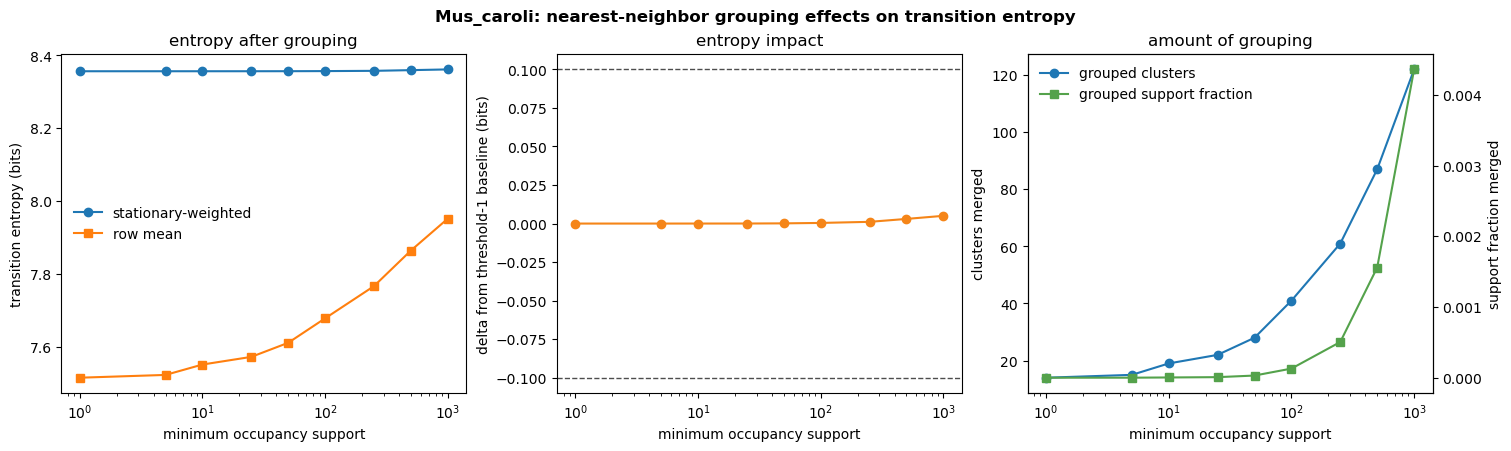

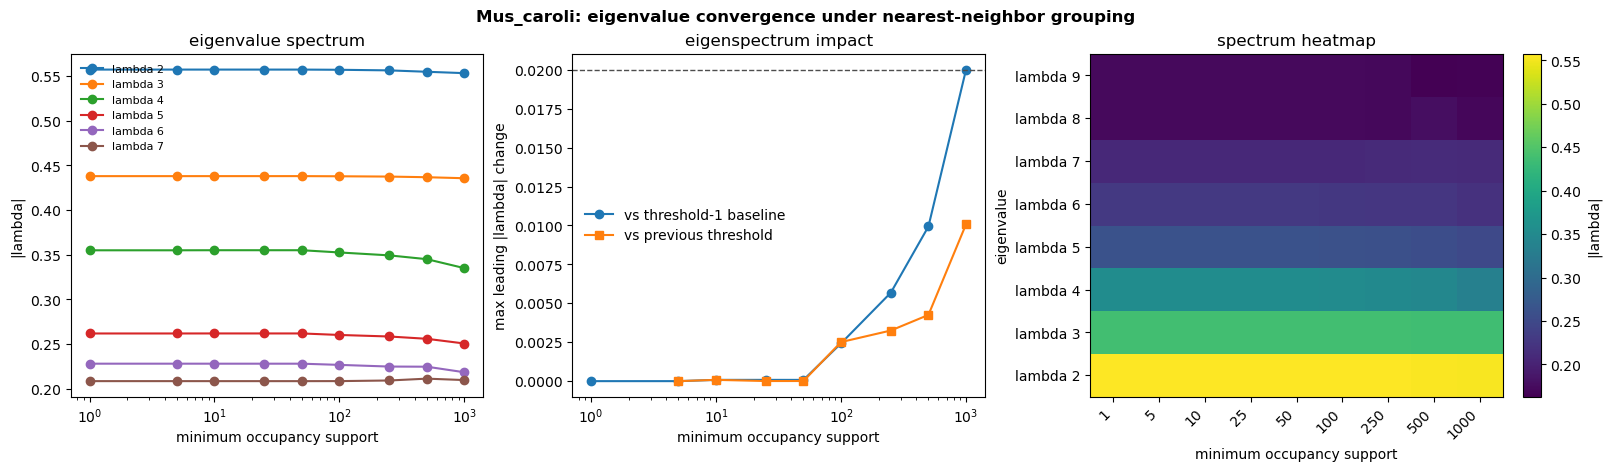

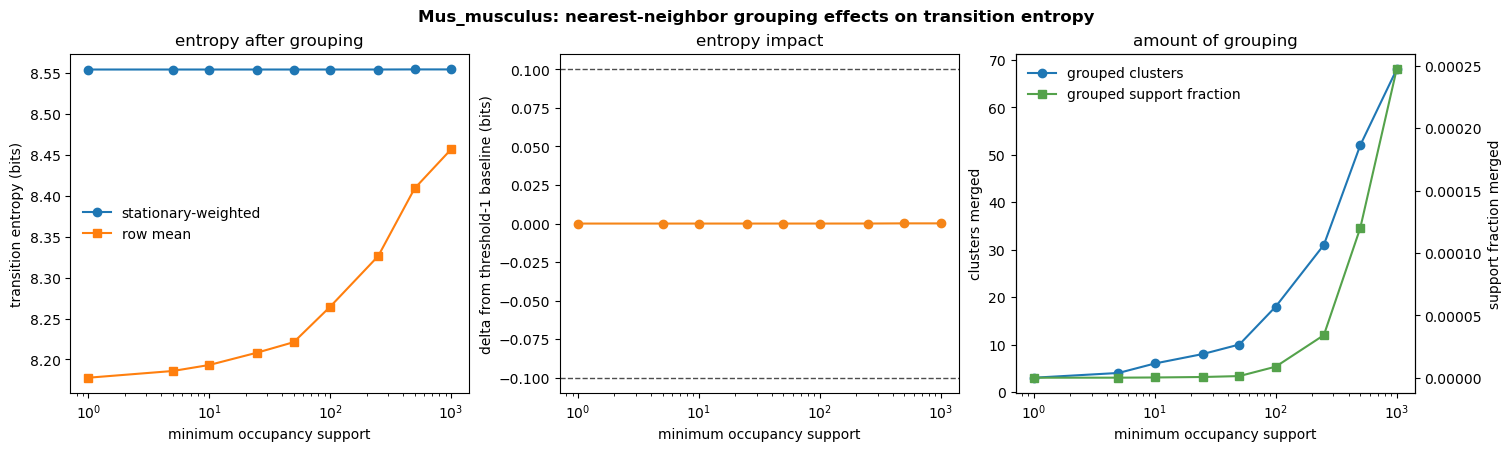

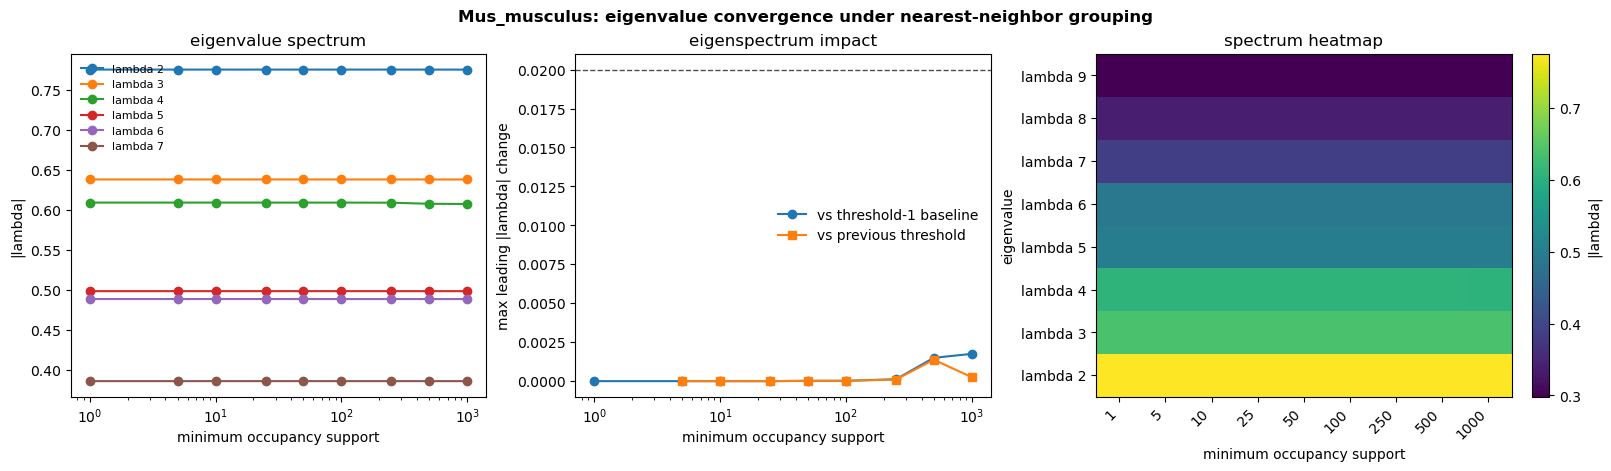

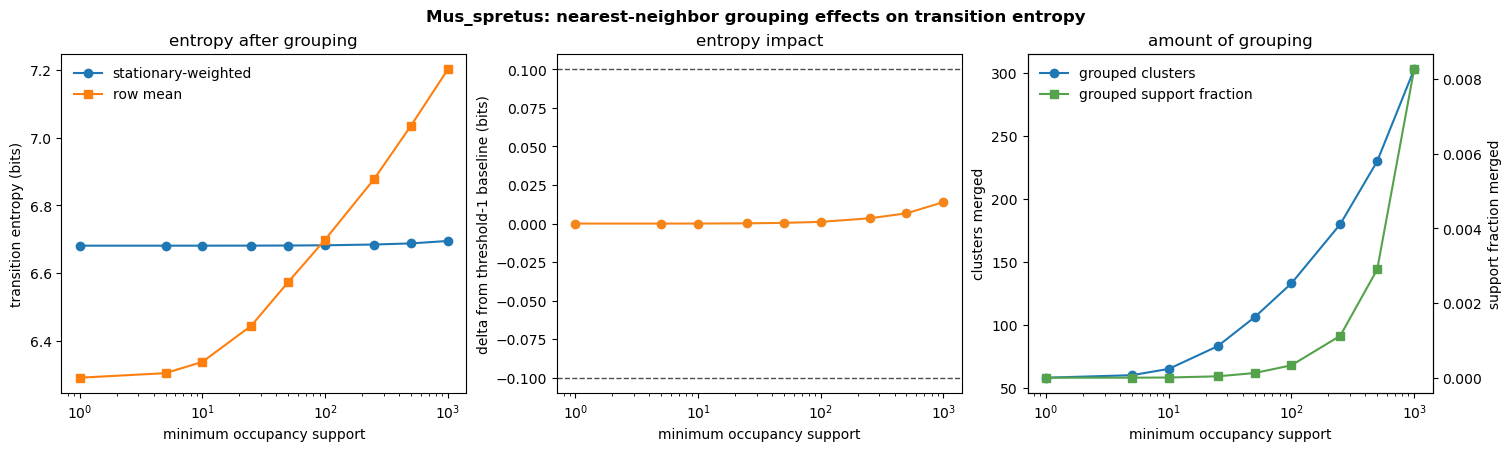

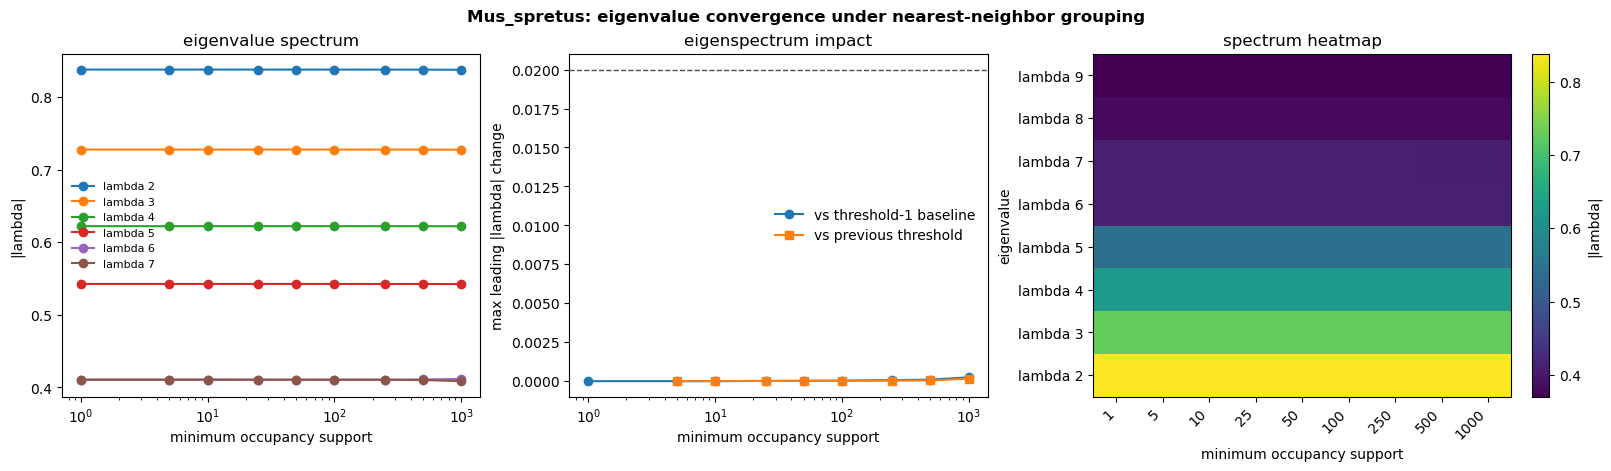

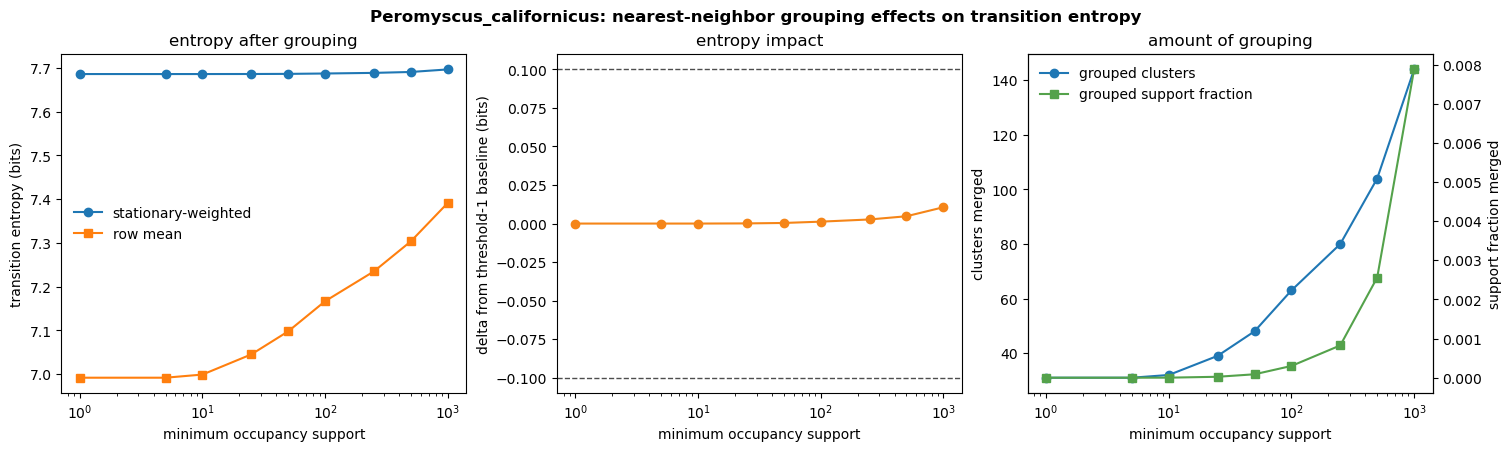

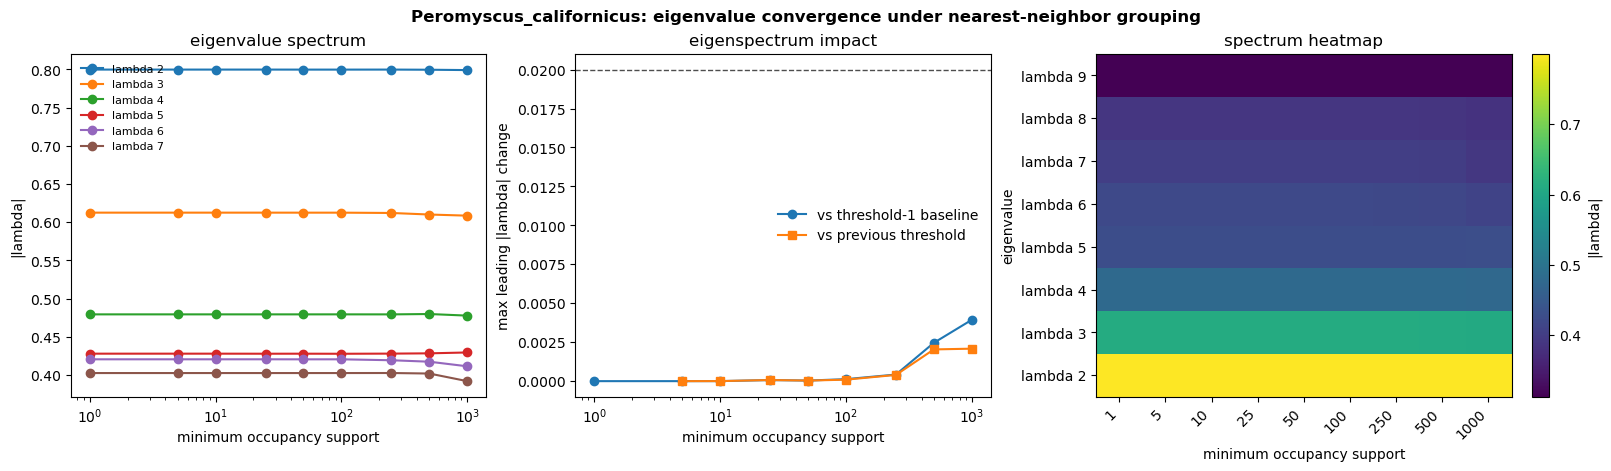

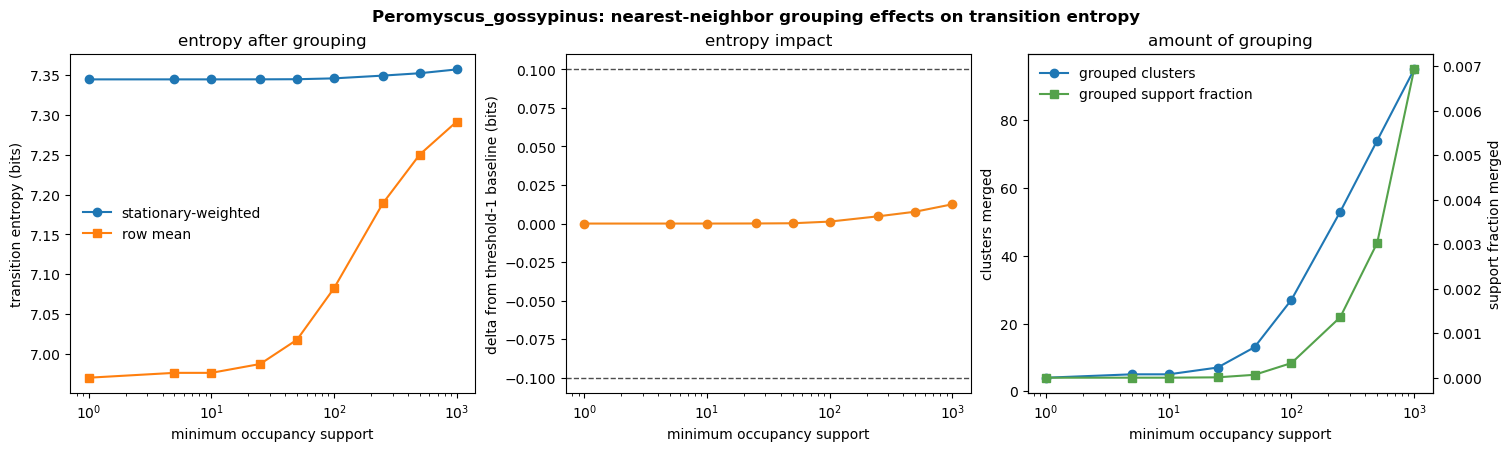

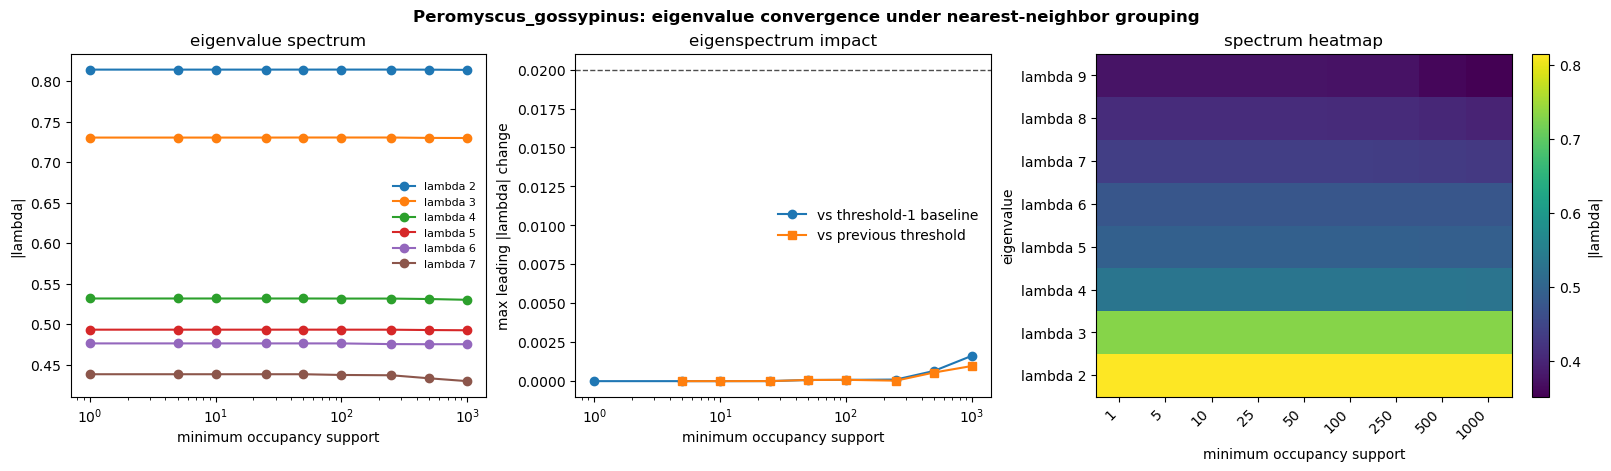

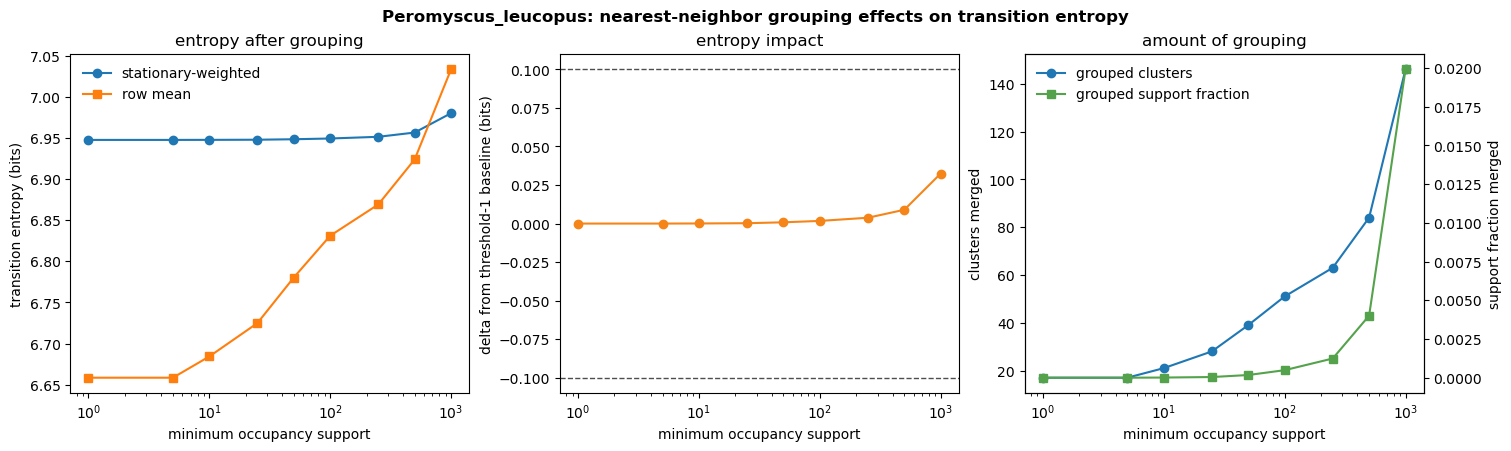

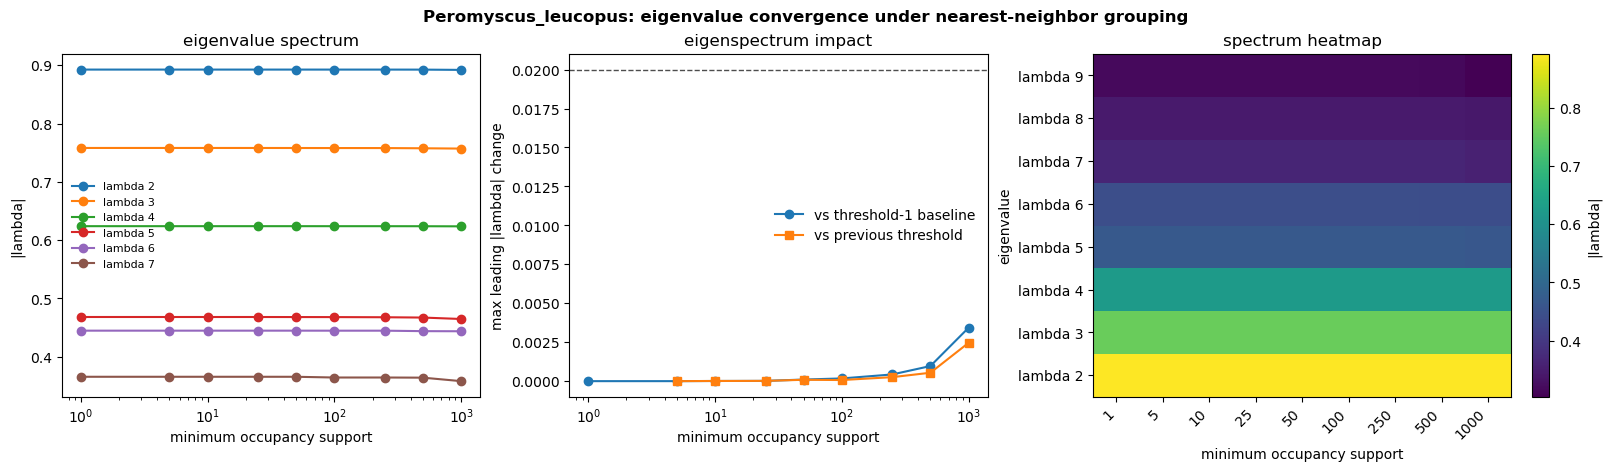

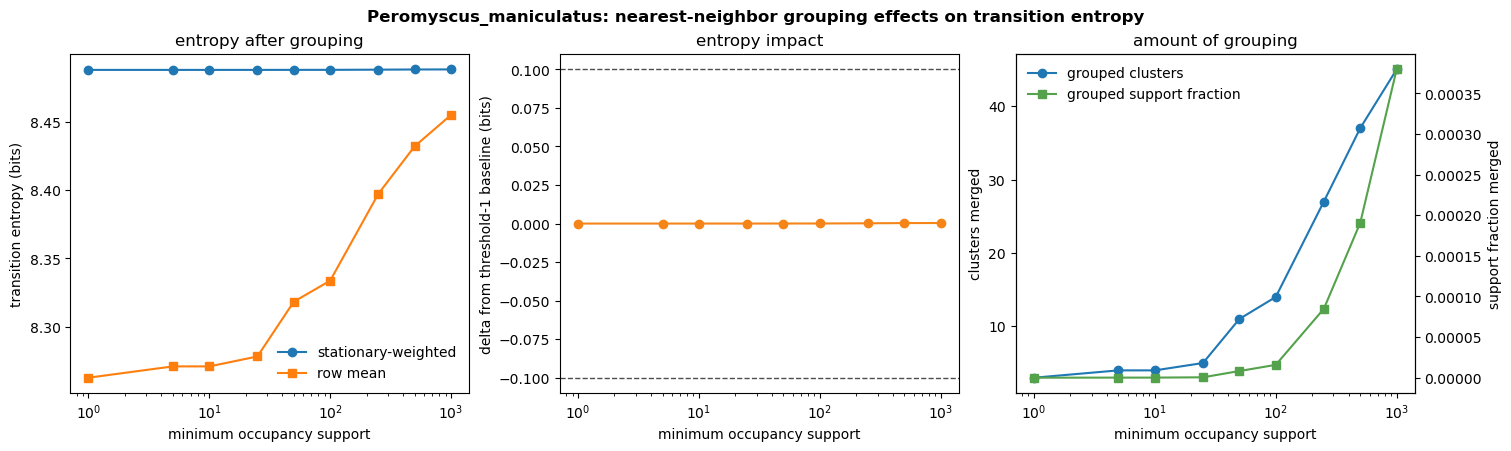

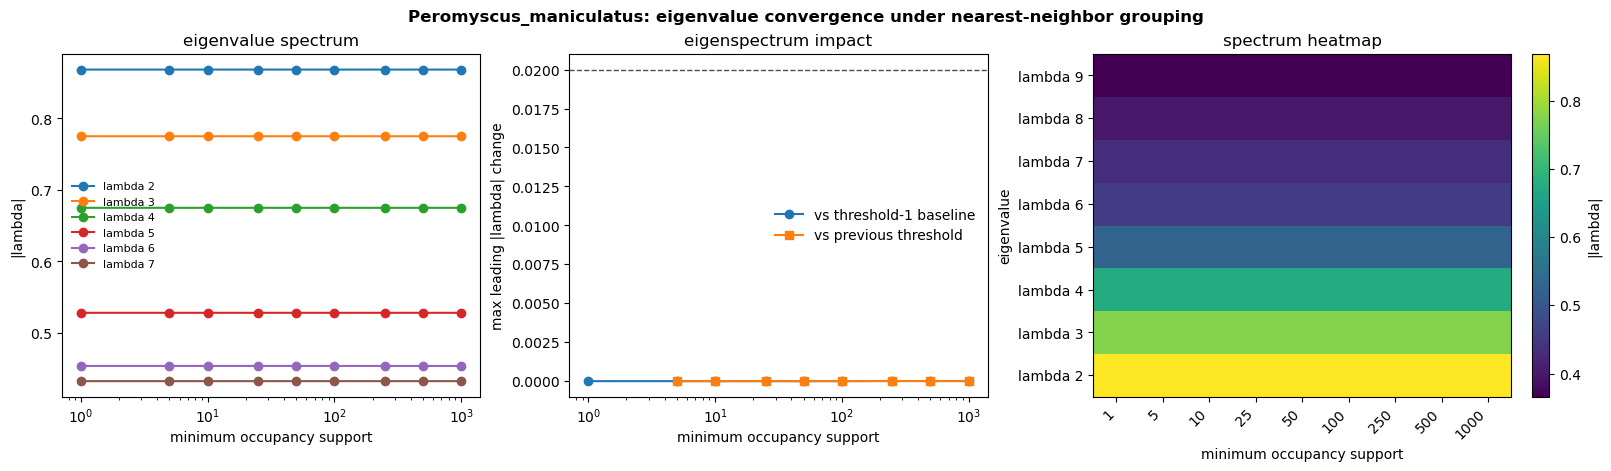

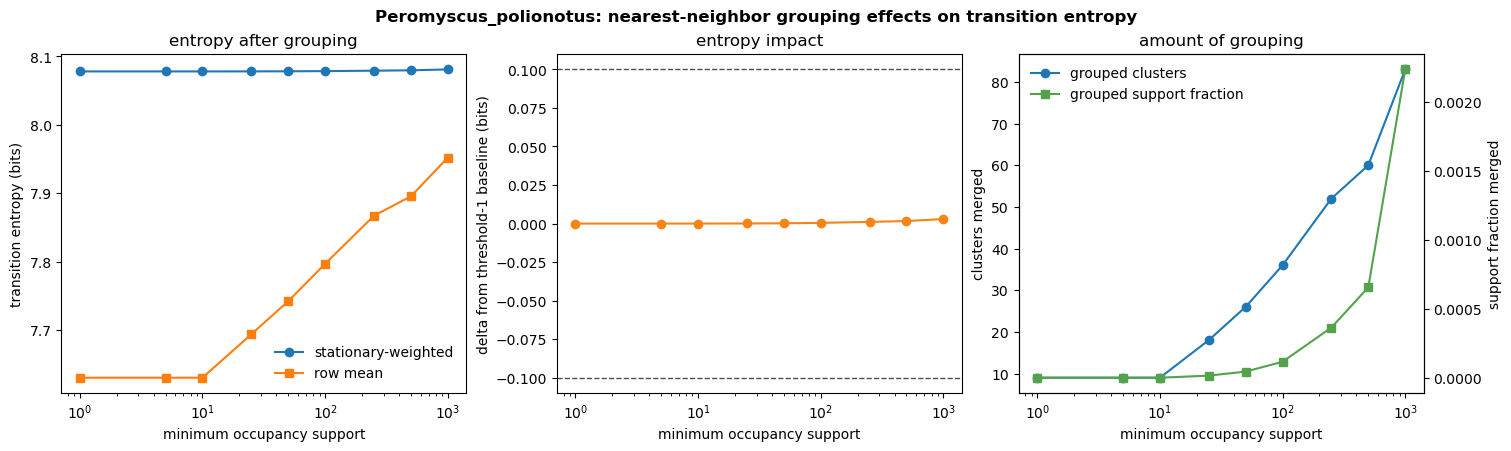

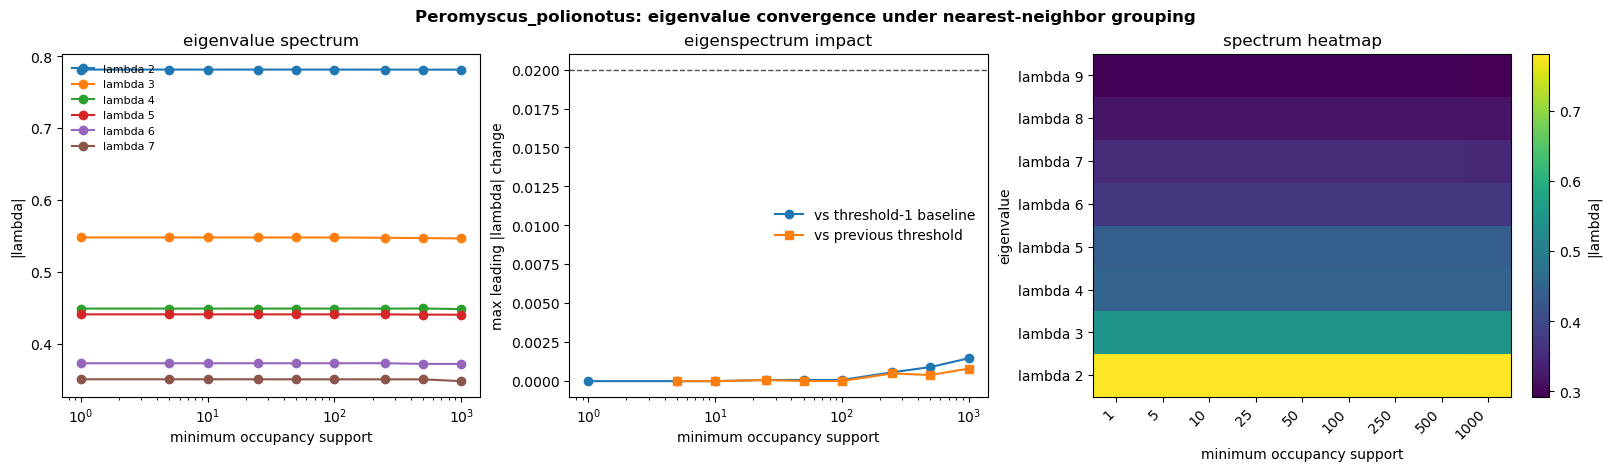

In [57]:
def plot_grouping_entropy_effects(species):
    df = grouping_sweep_results.loc[grouping_sweep_results['species'] == species].copy()
    if df.empty:
        print(f'No grouping sweep rows for {species}')
        return
    x = df['min_support'].to_numpy(int)

    fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.4), constrained_layout=True)

    ax = axes[0]
    ax.plot(x, df['stationary_weighted_transition_entropy_bits'], marker='o', label='stationary-weighted')
    ax.plot(x, df['mean_transition_entropy_bits'], marker='s', label='row mean')
    ax.set_xscale('log')
    ax.set_xlabel(f'minimum {GROUPING_SUPPORT_METRIC} support')
    ax.set_ylabel('transition entropy (bits)')
    ax.set_title('entropy after grouping')
    ax.legend(frameon=False)

    ax = axes[1]
    ax.plot(x, df['entropy_delta_from_baseline_bits'], marker='o', color='#F58518')
    ax.axhline(GROUPING_ENTROPY_IMPACT_TOLERANCE_BITS, color='0.3', linestyle='--', linewidth=1)
    ax.axhline(-GROUPING_ENTROPY_IMPACT_TOLERANCE_BITS, color='0.3', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_xlabel(f'minimum {GROUPING_SUPPORT_METRIC} support')
    ax.set_ylabel('delta from threshold-1 baseline (bits)')
    ax.set_title('entropy impact')

    ax = axes[2]
    ax.plot(x, df['n_grouped_clusters'], marker='o', label='grouped clusters')
    ax2 = ax.twinx()
    ax2.plot(x, df['grouped_support_fraction'], marker='s', color='#54A24B', label='grouped support fraction')
    ax.set_xscale('log')
    ax.set_xlabel(f'minimum {GROUPING_SUPPORT_METRIC} support')
    ax.set_ylabel('clusters merged')
    ax2.set_ylabel('support fraction merged')
    ax.set_title('amount of grouping')

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, frameon=False, loc='best')

    fig.suptitle(f'{species}: nearest-neighbor grouping effects on transition entropy', fontsize=12, fontweight='bold')
    fig.savefig(GROUPING_DIR / f'{species}_grouping_transition_entropy_effects.png', dpi=PLOT_DPI)
    plt.show()


def plot_grouping_eigen_convergence(species):
    df = grouping_sweep_results.loc[grouping_sweep_results['species'] == species].copy()
    if df.empty:
        print(f'No grouping sweep rows for {species}')
        return
    x = df['min_support'].to_numpy(int)
    lambda_cols = eigenvalue_columns(df, value='abs')[:8]

    fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6), constrained_layout=True)

    ax = axes[0]
    for col in lambda_cols[:6]:
        ax.plot(x, df[col], marker='o', label=col.replace('_abs', '').replace('_', ' '))
    ax.set_xscale('log')
    ax.set_xlabel(f'minimum {GROUPING_SUPPORT_METRIC} support')
    ax.set_ylabel('|lambda|')
    ax.set_title('eigenvalue spectrum')
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    ax.plot(x, df['max_leading_eigen_delta_from_baseline'], marker='o', label='vs threshold-1 baseline')
    ax.plot(x, df['max_leading_eigen_delta_from_previous_threshold'], marker='s', label='vs previous threshold')
    ax.axhline(GROUPING_EIGENVALUE_IMPACT_TOLERANCE, color='0.3', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_xlabel(f'minimum {GROUPING_SUPPORT_METRIC} support')
    ax.set_ylabel('max leading |lambda| change')
    ax.set_title('eigenspectrum impact')
    ax.legend(frameon=False)

    values = df[lambda_cols[:min(10, len(lambda_cols))]].to_numpy(float)
    ax = axes[2]
    image = ax.imshow(values.T, aspect='auto', origin='lower', cmap='viridis')
    ax.set_xticks(np.arange(len(x)))
    ax.set_xticklabels(x, rotation=45, ha='right')
    ax.set_yticks(np.arange(values.shape[1]))
    ax.set_yticklabels([col.replace('_abs', '').replace('_', ' ') for col in lambda_cols[:values.shape[1]]])
    ax.set_xlabel(f'minimum {GROUPING_SUPPORT_METRIC} support')
    ax.set_ylabel('eigenvalue')
    ax.set_title('spectrum heatmap')
    fig.colorbar(image, ax=ax, label='|lambda|')

    fig.suptitle(f'{species}: eigenvalue convergence under nearest-neighbor grouping', fontsize=12, fontweight='bold')
    fig.savefig(GROUPING_DIR / f'{species}_grouping_eigenvalue_convergence.png', dpi=PLOT_DPI)
    plt.show()


for species in species_names:
    plot_grouping_entropy_effects(species)
    plot_grouping_eigen_convergence(species)

In [58]:
def recommend_grouping_cutoffs():
    rows = []
    for species, df in grouping_sweep_results.groupby('species', sort=True):
        df = df.sort_values('min_support').copy()
        ok = (
            df['max_leading_eigen_delta_from_baseline'].fillna(0) <= GROUPING_EIGENVALUE_IMPACT_TOLERANCE
        ) & (
            df['entropy_delta_from_baseline_bits'].abs() <= GROUPING_ENTROPY_IMPACT_TOLERANCE_BITS
        )
        valid = df.loc[ok]
        if valid.empty:
            chosen = df.iloc[0]
            status = 'no_threshold_within_tolerance'
        else:
            chosen = valid.iloc[-1]
            status = 'within_tolerance'
        rows.append({
            'species': species,
            'recommended_min_support': int(chosen['min_support']),
            'support_metric': GROUPING_SUPPORT_METRIC,
            'status': status,
            'n_macro_clusters': int(chosen['n_macro_clusters']),
            'n_grouped_clusters': int(chosen['n_grouped_clusters']),
            'grouped_support_fraction': float(chosen['grouped_support_fraction']),
            'max_leading_eigen_delta_from_baseline': float(chosen['max_leading_eigen_delta_from_baseline']),
            'entropy_delta_from_baseline_bits': float(chosen['entropy_delta_from_baseline_bits']),
            'eigenvalue_impact_tolerance': float(GROUPING_EIGENVALUE_IMPACT_TOLERANCE),
            'entropy_impact_tolerance_bits': float(GROUPING_ENTROPY_IMPACT_TOLERANCE_BITS),
        })
    return pd.DataFrame(rows)


grouping_cutoff_recommendations = recommend_grouping_cutoffs()
grouping_cutoff_recommendations.to_csv(GROUPING_DIR / 'nearest_neighbor_grouping_cutoff_recommendations.csv', index=False)
display(grouping_cutoff_recommendations)

,species,recommended_min_support,support_metric,status,n_macro_clusters,n_grouped_clusters,grouped_support_fraction,max_leading_eigen_delta_from_baseline,entropy_delta_from_baseline_bits,eigenvalue_impact_tolerance,entropy_impact_tolerance_bits
0,Mus_caroli,500,occupancy,within_tolerance,913,87,0.001557,0.009933,0.003012,0.02,0.1
1,Mus_musculus,1000,occupancy,within_tolerance,932,68,0.000247,0.001751,0.000120,0.02,0.1
2,Mus_spretus,1000,occupancy,within_tolerance,697,303,0.008259,0.000245,0.013906,0.02,0.1
3,Peromyscus_californicus,1000,occupancy,within_tolerance,856,144,0.007878,0.003934,0.010584,0.02,0.1
4,Peromyscus_gossypinus,1000,occupancy,within_tolerance,905,95,0.006929,0.001623,0.012495,0.02,0.1
5,Peromyscus_leucopus,1000,occupancy,within_tolerance,854,146,0.019914,0.003426,0.032460,0.02,0.1
6,Peromyscus_maniculatus,1000,occupancy,within_tolerance,955,45,0.000380,0.000008,0.000358,0.02,0.1
7,Peromyscus_polionotus,1000,occupancy,within_tolerance,917,83,0.002235,0.001466,0.002934,0.02,0.1


## Full Nearest-Neighbor Absorption Trajectory

The threshold-grouping section above only tests a small set of support cutoffs. This section performs the stronger diagnostic: starting from the valid source-state set, repeatedly merge the lowest-support macro-cluster into its nearest surviving neighbor until only one macro-cluster remains.

This lets us ask where the eigenspectrum and transition entropy first become meaningfully perturbed as low-visited clusters are absorbed. That perturbation point is a natural candidate cutoff for the species-specific transfer operator.

In [66]:
ABSORB_SUPPORT_METRIC = 'occupancy'  # options: 'outgoing' or 'occupancy'
ABSORB_COMPARE_EIGENVALUES = [2, 3, 4, 5]
ABSORB_EIGENVALUE_IMPACT_TOLERANCE = 0.02
ABSORB_ENTROPY_IMPACT_TOLERANCE_BITS = 0.10
ABSORB_SNAPSHOT_MACRO_COUNTS = [
    1000, 975, 950, 925, 900, 850, 800, 750, 700, 650, 600, 550, 500,
    450, 400, 350, 300, 250, 200, 175, 150, 125, 100, 75, 50, 25, 10, 5, 2, 1,
]

ABSORB_DIR = OUT_DIR / f'full_nearest_neighbor_absorption_by_{ABSORB_SUPPORT_METRIC}'
ABSORB_DIR.mkdir(parents=True, exist_ok=True)


def absorption_support_values(species):
    counts = np.asarray(species_transition_counts[species])
    if ABSORB_SUPPORT_METRIC == 'outgoing':
        return counts.sum(axis=1)
    if ABSORB_SUPPORT_METRIC == 'occupancy':
        return species_cluster_occupancy[species]
    raise ValueError(f'Unknown ABSORB_SUPPORT_METRIC: {ABSORB_SUPPORT_METRIC}')


def nearest_active_cluster(cluster_id, active_clusters, centers):
    active_clusters = np.asarray(active_clusters, dtype=int)
    candidates = active_clusters[active_clusters != int(cluster_id)]
    if candidates.size == 0:
        return None
    delta = centers[candidates] - centers[int(cluster_id)]
    distances = np.einsum('ij,ij->i', delta, delta)
    return int(candidates[int(np.argmin(distances))])


def contiguous_mapping(old_to_rep):
    reps = np.array(sorted(np.unique(old_to_rep)), dtype=int)
    rep_to_idx = {int(rep): i for i, rep in enumerate(reps)}
    old_to_macro = np.array([rep_to_idx[int(rep)] for rep in old_to_rep], dtype=int)
    return old_to_macro, reps


def grouped_operator_from_representatives(counts, old_to_rep):
    old_to_macro, reps = contiguous_mapping(old_to_rep)
    grouped_counts = aggregate_transition_counts_by_mapping(counts, old_to_macro, len(reps))
    row_sums = grouped_counts.sum(axis=1, keepdims=True)
    active = np.flatnonzero(row_sums[:, 0] > 0)
    if active.size != grouped_counts.shape[0]:
        grouped_counts = grouped_counts[np.ix_(active, active)]
        reps = reps[active]
        row_sums = grouped_counts.sum(axis=1, keepdims=True)
    if grouped_counts.shape[0] == 1:
        return np.ones((1, 1), dtype=np.float64), grouped_counts, reps
    if np.any(row_sums[:, 0] <= 0):
        raise ValueError('Grouped operator still has empty outgoing rows.')
    return grouped_counts / row_sums, grouped_counts, reps


def summarize_absorbed_operator(species, counts, old_to_rep, target_macro_count, baseline_eigs=None, baseline_entropy=None):
    T, grouped_counts, reps = grouped_operator_from_representatives(counts, old_to_rep)
    if T.shape[0] > 1:
        pi = pp.stationary_distribution(T)
        eigvals = eigen_summary(T)
    else:
        pi = np.array([1.0])
        eigvals = np.array([], dtype=complex)
    weighted_entropy, _ = transition_entropy(T, pi=pi)
    mean_entropy, _ = transition_entropy(T, pi=None)
    abs_eigs = np.abs(eigvals)

    if baseline_eigs is None:
        baseline_eigs = abs_eigs.copy()
    if baseline_entropy is None:
        baseline_entropy = weighted_entropy

    n_compare = min(len(abs_eigs), len(baseline_eigs), max(ABSORB_COMPARE_EIGENVALUES) - 1)
    eig_delta = np.nan
    if n_compare:
        eig_delta = float(np.nanmax(np.abs(abs_eigs[:n_compare] - baseline_eigs[:n_compare])))

    row = {
        'species': species,
        'support_metric': ABSORB_SUPPORT_METRIC,
        'target_macro_count': int(target_macro_count),
        'n_macro_clusters': int(T.shape[0]),
        'stationary_weighted_transition_entropy_bits': float(weighted_entropy),
        'mean_transition_entropy_bits': float(mean_entropy),
        'entropy_delta_from_baseline_bits': float(weighted_entropy - baseline_entropy),
        'max_leading_eigen_delta_from_baseline': eig_delta,
        'pi_max': float(pi.max()),
        'pi_effective_macro_clusters': float(1.0 / np.sum(pi ** 2)),
        'total_within_macro_transitions': float(grouped_counts.sum()),
    }
    for i, value in enumerate(eigvals, start=2):
        row[f'lambda_{i}_real'] = float(np.real(value))
        row[f'lambda_{i}_imag'] = float(np.imag(value))
        row[f'lambda_{i}_abs'] = float(np.abs(value))
    return row, baseline_eigs, baseline_entropy


def absorption_trajectory_for_species(species):
    counts = np.asarray(species_transition_counts[species], dtype=np.float64)
    support = np.asarray(absorption_support_values(species), dtype=np.float64).copy()

    # Transfer operators need source states with observed exits. Zero-outgoing
    # clusters are absorbed into the nearest nonzero-outgoing cluster before the
    # trajectory begins; otherwise they recreate artificial empty rows.
    outgoing = counts.sum(axis=1)
    active_clusters = np.flatnonzero(outgoing > 0)
    if active_clusters.size == 0:
        raise ValueError(f'{species} has no clusters with outgoing transitions.')

    old_to_rep = np.arange(N_CLUSTERS, dtype=int)
    zero_outgoing = np.setdiff1d(np.arange(N_CLUSTERS, dtype=int), active_clusters, assume_unique=True)
    for cluster in zero_outgoing:
        neighbor = nearest_active_cluster(cluster, active_clusters, cluster_centers)
        if neighbor is not None:
            old_to_rep[cluster] = neighbor
            support[neighbor] += support[cluster]
            support[cluster] = 0.0

    snapshot_targets = sorted(
        {int(value) for value in ABSORB_SNAPSHOT_MACRO_COUNTS if int(value) <= active_clusters.size},
        reverse=True,
    )
    if 1 not in snapshot_targets:
        snapshot_targets.append(1)
    snapshot_targets = sorted(set(snapshot_targets), reverse=True)
    target_index = 0

    rows = []
    baseline_eigs = None
    baseline_entropy = None

    def maybe_record_snapshots():
        nonlocal target_index, baseline_eigs, baseline_entropy
        while target_index < len(snapshot_targets) and active_clusters.size <= snapshot_targets[target_index]:
            target = snapshot_targets[target_index]
            row, baseline_eigs, baseline_entropy = summarize_absorbed_operator(
                species,
                counts,
                old_to_rep,
                target,
                baseline_eigs=baseline_eigs,
                baseline_entropy=baseline_entropy,
            )
            rows.append(row)
            target_index += 1

    maybe_record_snapshots()
    while active_clusters.size > 1:
        active_support = support[active_clusters]
        merge_source = int(active_clusters[int(np.argmin(active_support))])
        merge_target = nearest_active_cluster(merge_source, active_clusters, cluster_centers)
        if merge_target is None:
            break

        old_to_rep[old_to_rep == merge_source] = merge_target
        support[merge_target] += support[merge_source]
        support[merge_source] = 0.0
        active_clusters = active_clusters[active_clusters != merge_source]
        maybe_record_snapshots()

    return pd.DataFrame(rows)


absorption_trajectory_results = pd.concat(
    [absorption_trajectory_for_species(species) for species in species_names],
    ignore_index=True,
)
absorption_trajectory_results.to_csv(ABSORB_DIR / 'full_nearest_neighbor_absorption_eigen_entropy_trajectory.csv', index=False)
display(absorption_trajectory_results.head(20))

,species,support_metric,target_macro_count,n_macro_clusters,stationary_weighted_transition_entropy_bits,mean_transition_entropy_bits,entropy_delta_from_baseline_bits,max_leading_eigen_delta_from_baseline,pi_max,pi_effective_macro_clusters,...,lambda_18_abs,lambda_19_real,lambda_19_imag,lambda_19_abs,lambda_20_real,lambda_20_imag,lambda_20_abs,lambda_21_real,lambda_21_imag,lambda_21_abs
0,Mus_caroli,occupancy,975,975,8.356515,7.591494,0.000000,0.000000,0.005917,578.754805,...,0.100459,0.099129,0.000000,0.099129,0.098394,0.003202,0.098447,0.098394,-0.003202,0.098447
1,Mus_caroli,occupancy,950,950,8.357154,7.722535,0.000639,0.005409,0.005917,578.618816,...,0.101829,0.099544,0.000000,0.099544,0.093674,0.009785,0.094183,0.093674,-0.009785,0.094183
2,Mus_caroli,occupancy,925,925,8.358506,7.819459,0.001991,0.005539,0.005917,578.224032,...,0.098521,0.092528,0.013703,0.093538,0.092528,-0.013703,0.093538,0.090151,0.022726,0.092972
3,Mus_caroli,occupancy,900,900,8.360424,7.899847,0.003909,0.011999,0.005917,577.531749,...,0.097963,0.091696,0.006504,0.091927,0.091696,-0.006504,0.091927,0.086932,0.021368,0.089520
4,Mus_caroli,occupancy,850,850,8.364167,8.016030,0.007652,0.019363,0.005917,574.528099,...,0.089417,0.088418,-0.013333,0.089417,0.080113,0.006345,0.080364,0.080113,-0.006345,0.080364
5,Mus_caroli,occupancy,800,800,8.367717,8.102519,0.011202,0.037116,0.005917,569.400691,...,0.080536,0.080371,-0.005143,0.080536,0.073898,0.007740,0.074302,0.073898,-0.007740,0.074302
6,Mus_caroli,occupancy,750,750,8.365452,8.159400,0.008936,0.065149,0.005917,558.517984,...,0.072176,0.070719,-0.014432,0.072176,0.065239,0.023200,0.069242,0.065239,-0.023200,0.069242
7,Mus_caroli,occupancy,700,700,8.354278,8.186504,-0.002237,0.063304,0.005917,541.072021,...,0.069337,0.068433,0.003519,0.068523,0.068433,-0.003519,0.068523,0.064272,0.003472,0.064365
8,Mus_caroli,occupancy,650,650,8.339370,8.215450,-0.017145,0.084666,0.005917,523.074857,...,0.069542,0.065925,0.001670,0.065946,0.065925,-0.001670,0.065946,0.060727,0.000000,0.060727
9,Mus_caroli,occupancy,600,600,8.310711,8.215460,-0.045805,0.084198,0.005917,497.740259,...,0.068071,0.067587,-0.008101,0.068071,0.063922,0.000000,0.063922,0.054488,0.006424,0.054866


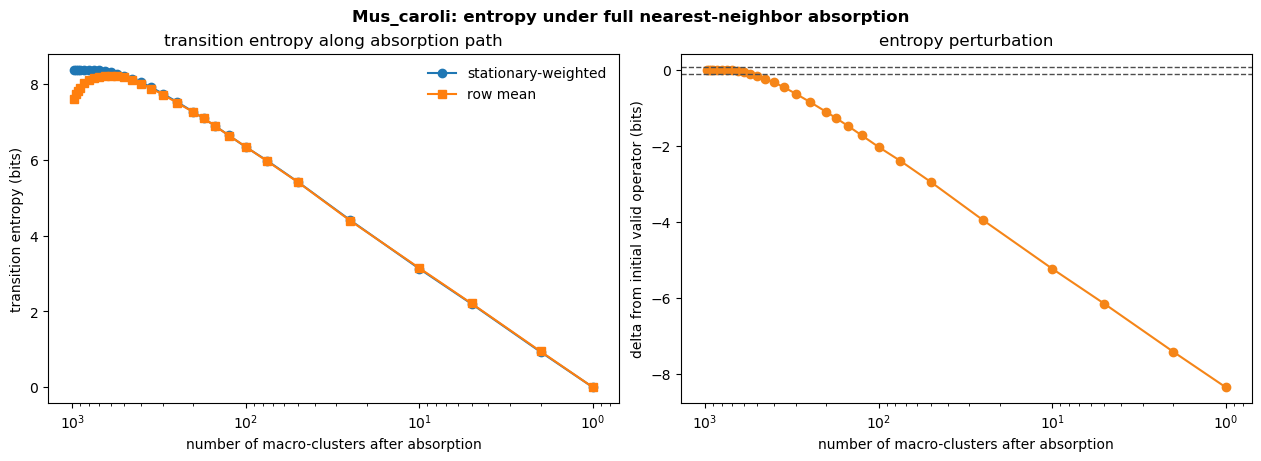

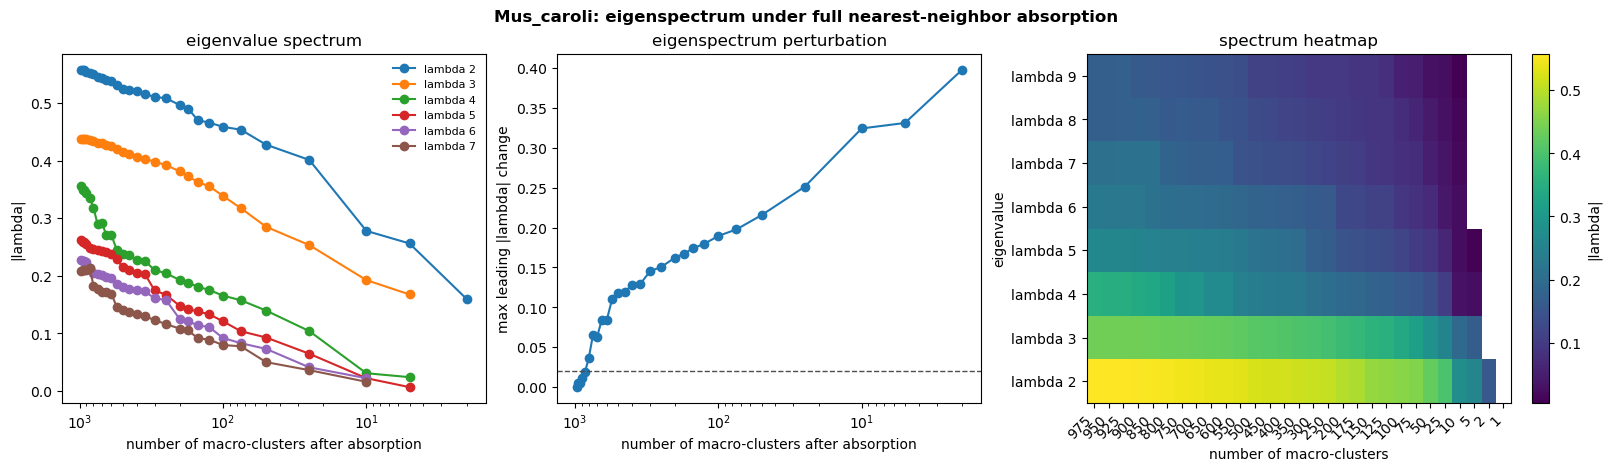

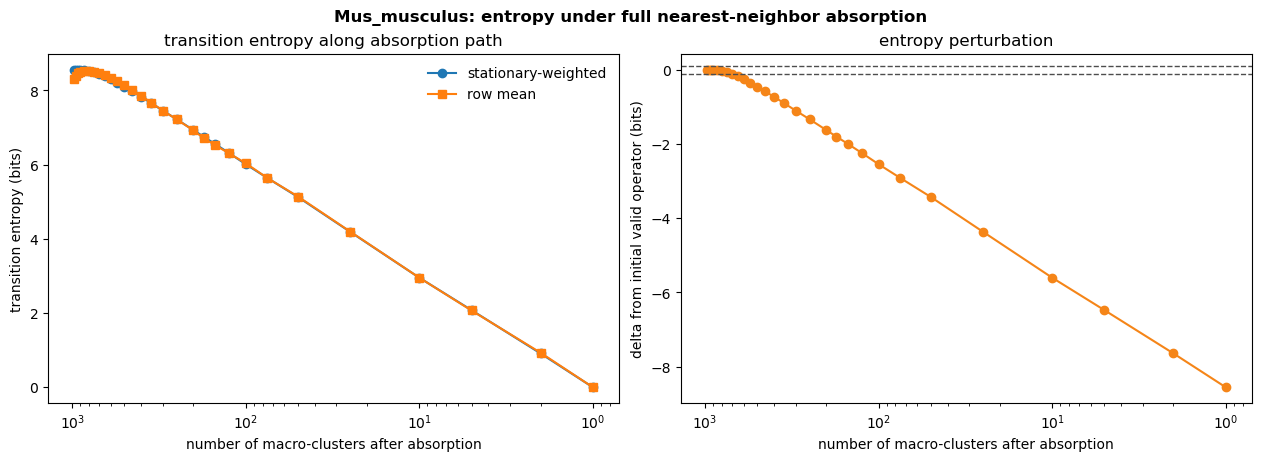

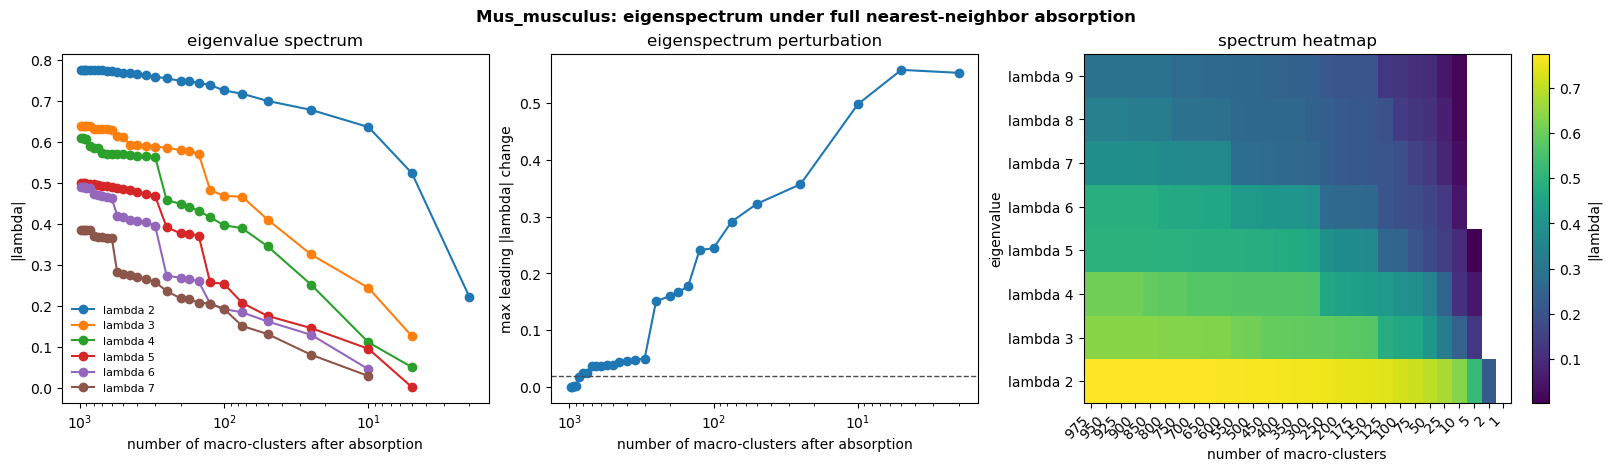

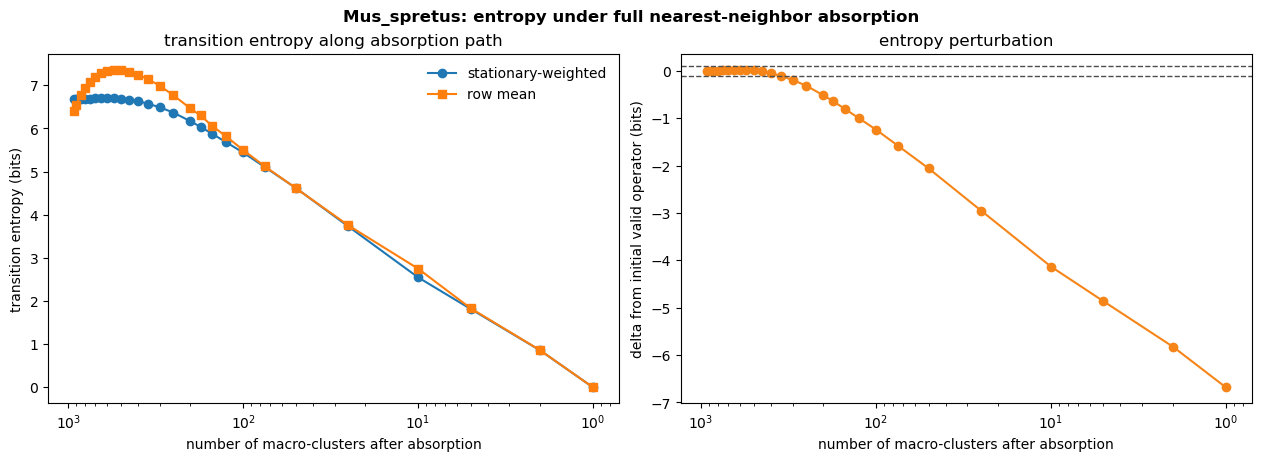

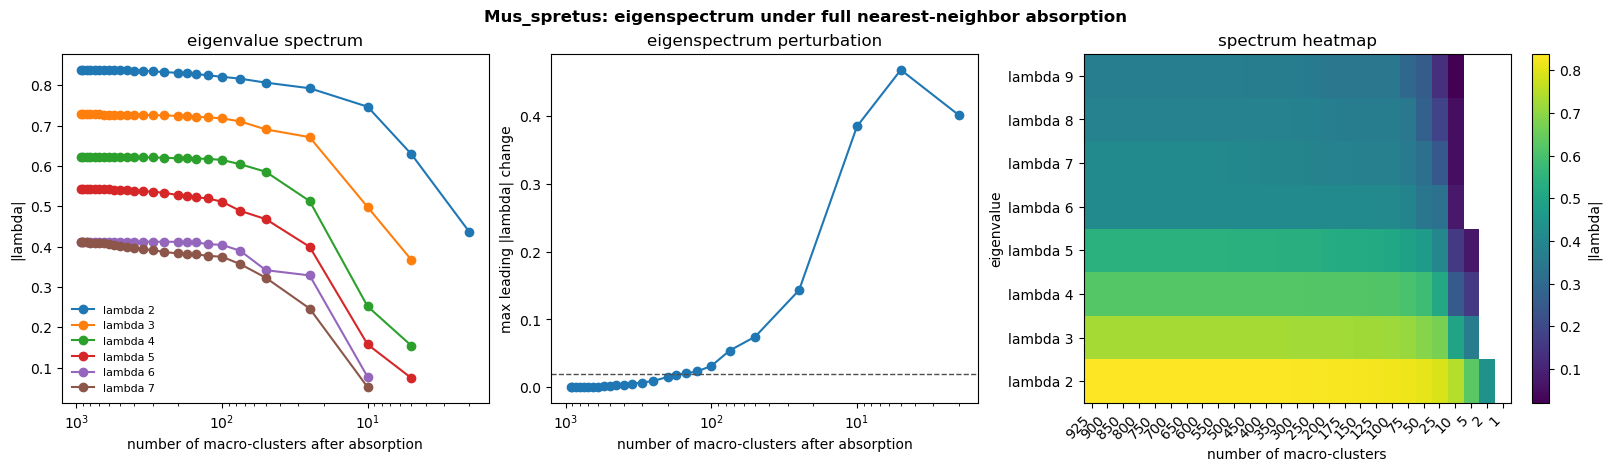

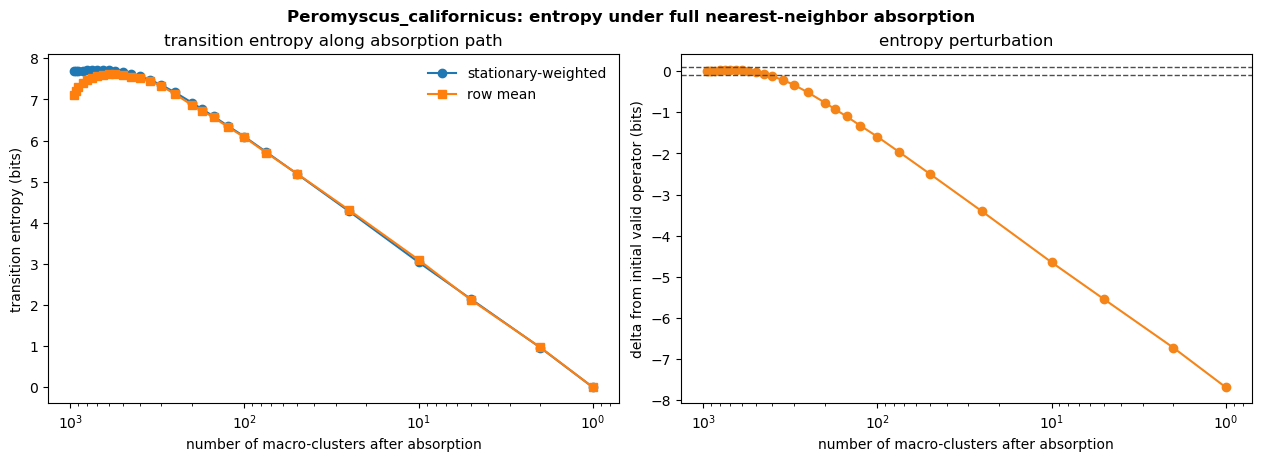

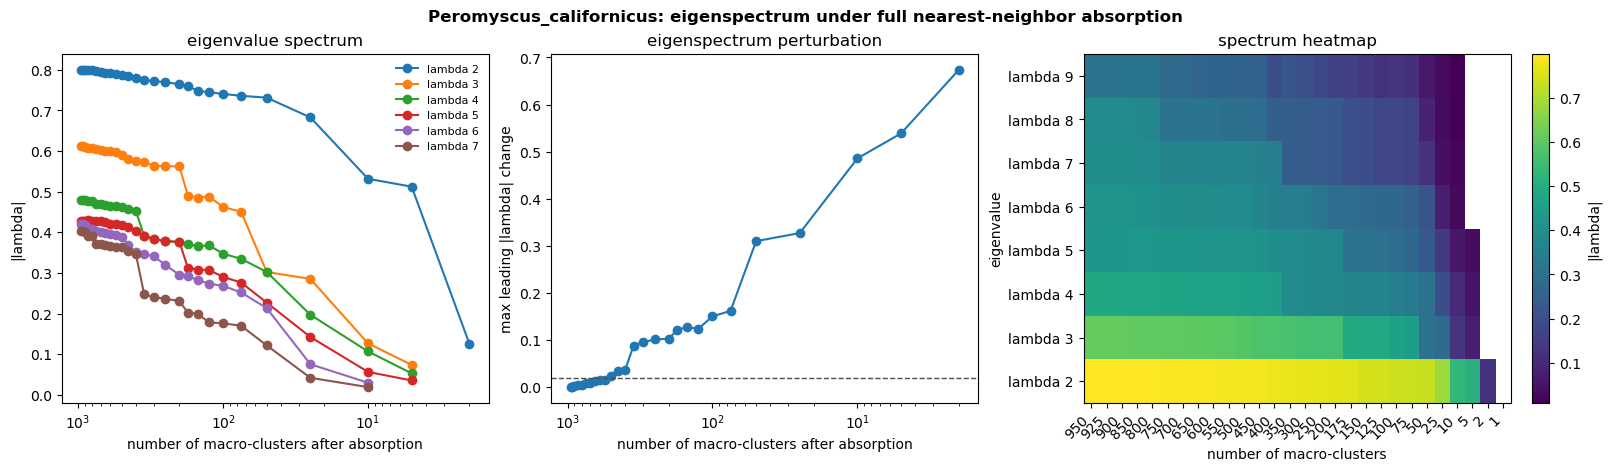

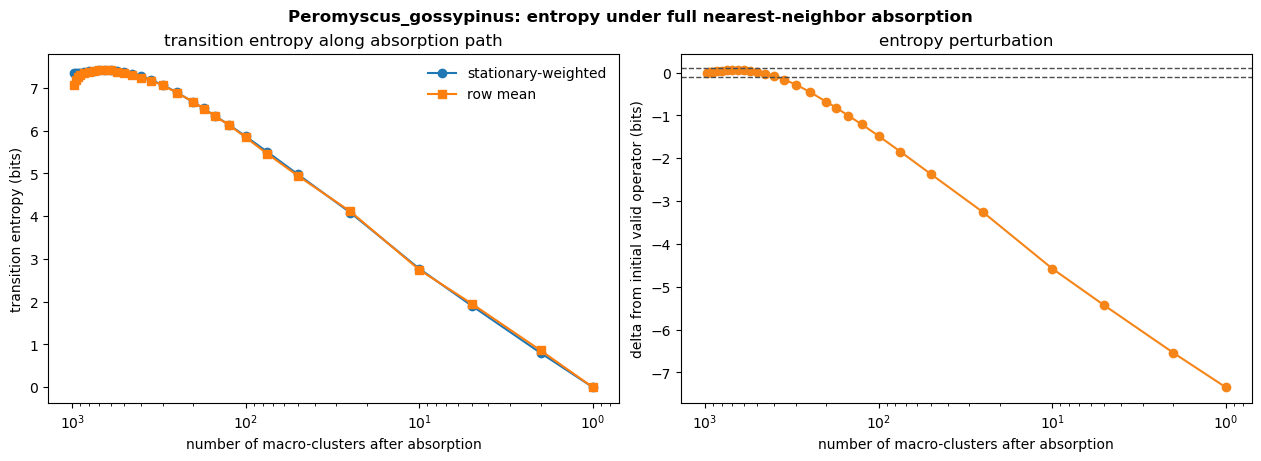

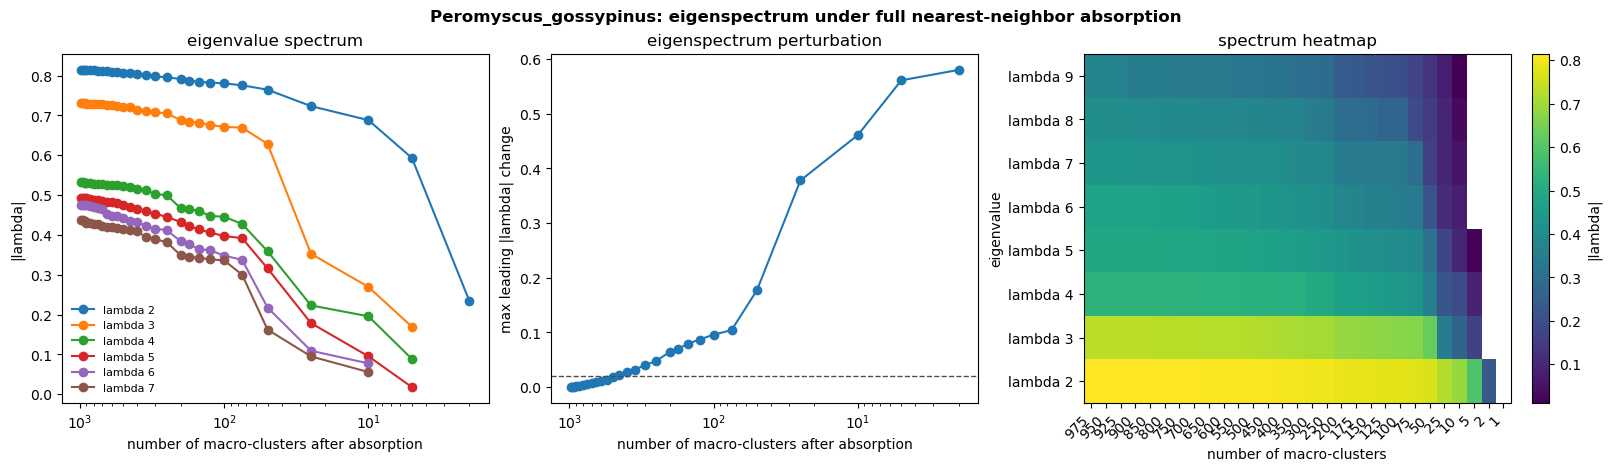

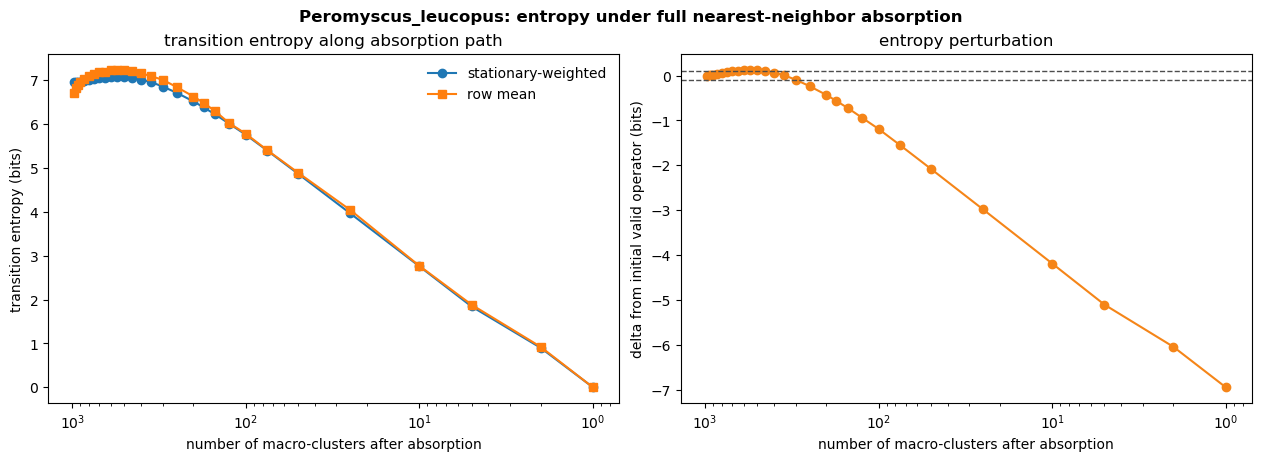

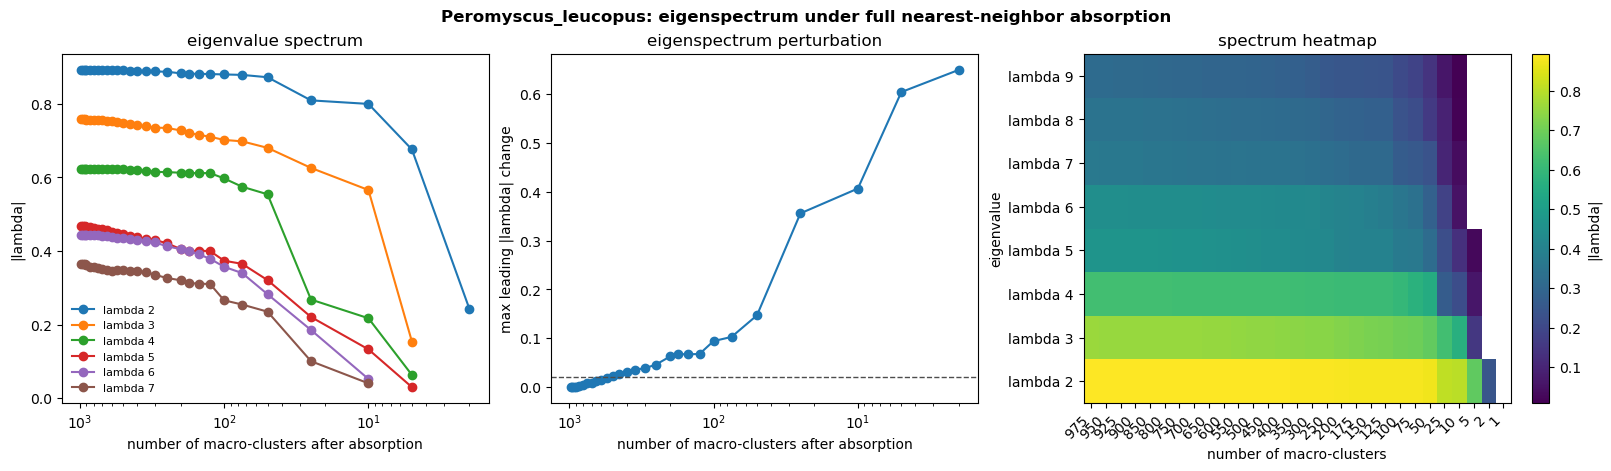

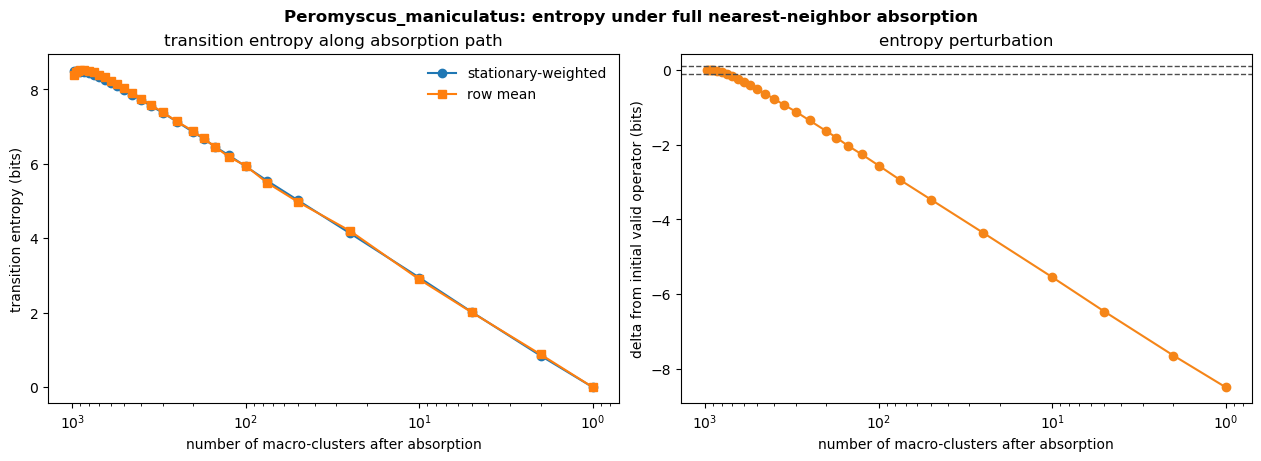

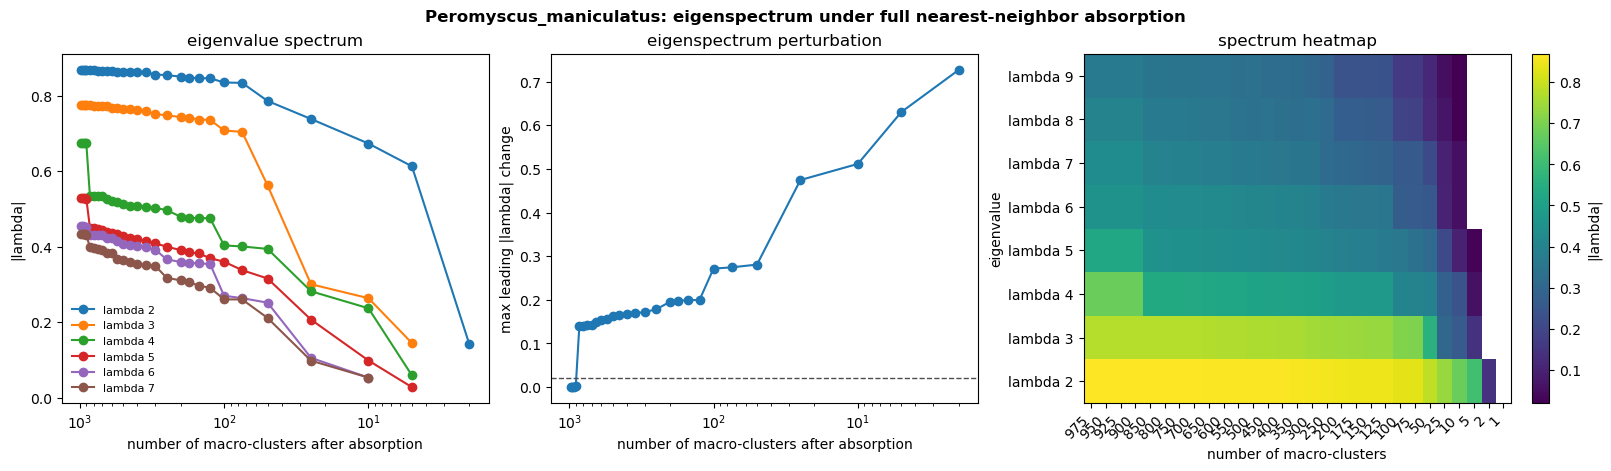

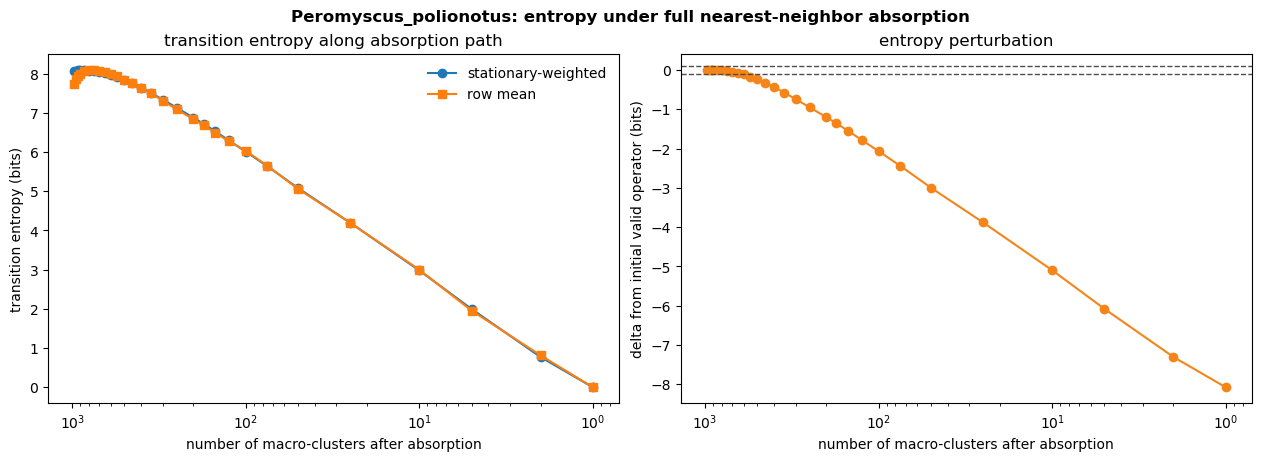

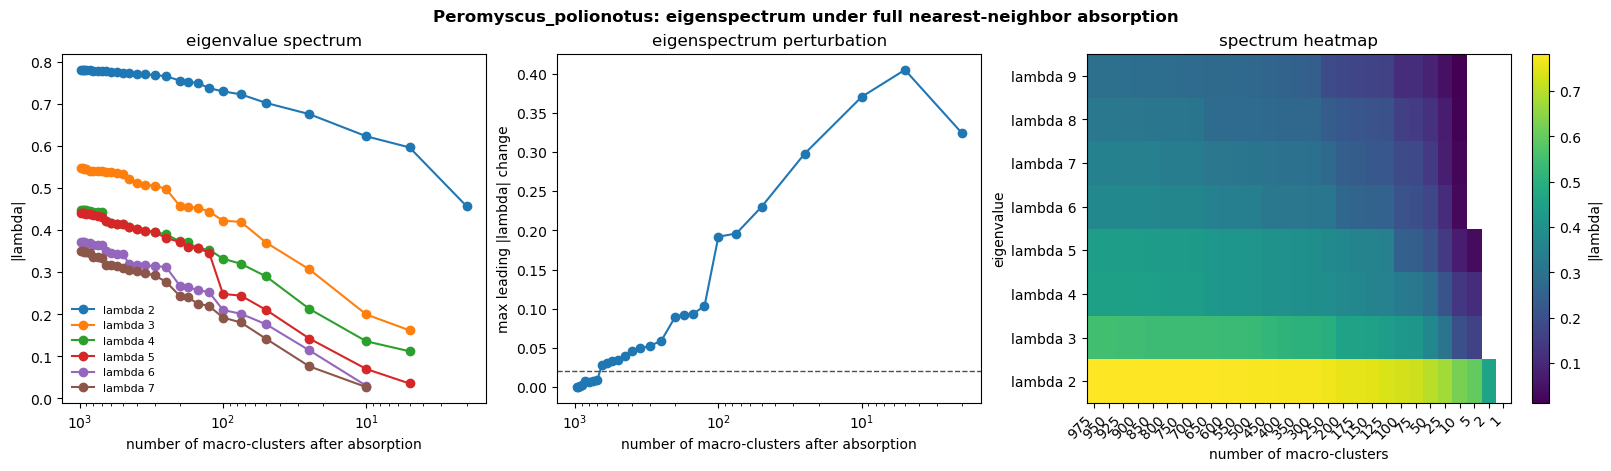

In [60]:
def plot_absorption_entropy(species):
    df = absorption_trajectory_results.loc[absorption_trajectory_results['species'] == species].copy()
    if df.empty:
        print(f'No absorption trajectory rows for {species}')
        return
    df = df.sort_values('n_macro_clusters', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), constrained_layout=True)

    ax = axes[0]
    ax.plot(df['n_macro_clusters'], df['stationary_weighted_transition_entropy_bits'], marker='o', label='stationary-weighted')
    ax.plot(df['n_macro_clusters'], df['mean_transition_entropy_bits'], marker='s', label='row mean')
    ax.invert_xaxis()
    ax.set_xscale('log')
    ax.set_xlabel('number of macro-clusters after absorption')
    ax.set_ylabel('transition entropy (bits)')
    ax.set_title('transition entropy along absorption path')
    ax.legend(frameon=False)

    ax = axes[1]
    ax.plot(df['n_macro_clusters'], df['entropy_delta_from_baseline_bits'], marker='o', color='#F58518')
    ax.axhline(ABSORB_ENTROPY_IMPACT_TOLERANCE_BITS, color='0.3', linestyle='--', linewidth=1)
    ax.axhline(-ABSORB_ENTROPY_IMPACT_TOLERANCE_BITS, color='0.3', linestyle='--', linewidth=1)
    ax.invert_xaxis()
    ax.set_xscale('log')
    ax.set_xlabel('number of macro-clusters after absorption')
    ax.set_ylabel('delta from initial valid operator (bits)')
    ax.set_title('entropy perturbation')

    fig.suptitle(f'{species}: entropy under full nearest-neighbor absorption', fontsize=12, fontweight='bold')
    fig.savefig(ABSORB_DIR / f'{species}_full_absorption_transition_entropy.png', dpi=PLOT_DPI)
    plt.show()


def plot_absorption_eigenspectrum(species):
    df = absorption_trajectory_results.loc[absorption_trajectory_results['species'] == species].copy()
    if df.empty:
        print(f'No absorption trajectory rows for {species}')
        return
    df = df.sort_values('n_macro_clusters', ascending=False)
    lambda_cols = eigenvalue_columns(df, value='abs')[:8]

    fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6), constrained_layout=True)

    ax = axes[0]
    for col in lambda_cols[:6]:
        ax.plot(df['n_macro_clusters'], df[col], marker='o', label=col.replace('_abs', '').replace('_', ' '))
    ax.invert_xaxis()
    ax.set_xscale('log')
    ax.set_xlabel('number of macro-clusters after absorption')
    ax.set_ylabel('|lambda|')
    ax.set_title('eigenvalue spectrum')
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1]
    ax.plot(df['n_macro_clusters'], df['max_leading_eigen_delta_from_baseline'], marker='o')
    ax.axhline(ABSORB_EIGENVALUE_IMPACT_TOLERANCE, color='0.3', linestyle='--', linewidth=1)
    ax.invert_xaxis()
    ax.set_xscale('log')
    ax.set_xlabel('number of macro-clusters after absorption')
    ax.set_ylabel('max leading |lambda| change')
    ax.set_title('eigenspectrum perturbation')

    heat_cols = lambda_cols[:min(10, len(lambda_cols))]
    values = df[heat_cols].to_numpy(float) if heat_cols else np.empty((len(df), 0))
    ax = axes[2]
    if values.size:
        image = ax.imshow(values.T, aspect='auto', origin='lower', cmap='viridis')
        ax.set_xticks(np.arange(len(df)))
        ax.set_xticklabels(df['n_macro_clusters'].astype(int), rotation=45, ha='right')
        ax.set_yticks(np.arange(values.shape[1]))
        ax.set_yticklabels([col.replace('_abs', '').replace('_', ' ') for col in heat_cols])
        fig.colorbar(image, ax=ax, label='|lambda|')
    ax.set_xlabel('number of macro-clusters')
    ax.set_ylabel('eigenvalue')
    ax.set_title('spectrum heatmap')

    fig.suptitle(f'{species}: eigenspectrum under full nearest-neighbor absorption', fontsize=12, fontweight='bold')
    fig.savefig(ABSORB_DIR / f'{species}_full_absorption_eigenvalue_convergence.png', dpi=PLOT_DPI)
    plt.show()


for species in species_names:
    plot_absorption_entropy(species)
    plot_absorption_eigenspectrum(species)

In [61]:
def recommend_absorption_cutoffs():
    rows = []
    for species, df in absorption_trajectory_results.groupby('species', sort=True):
        df = df.sort_values('n_macro_clusters', ascending=False).copy()
        ok = (
            df['max_leading_eigen_delta_from_baseline'].fillna(0) <= ABSORB_EIGENVALUE_IMPACT_TOLERANCE
        ) & (
            df['entropy_delta_from_baseline_bits'].abs() <= ABSORB_ENTROPY_IMPACT_TOLERANCE_BITS
        )
        valid = df.loc[ok]
        if valid.empty:
            chosen = df.iloc[0]
            status = 'no_absorption_level_within_tolerance'
        else:
            # Choose the most compressed operator that has not yet crossed the
            # perturbation tolerances.
            chosen = valid.sort_values('n_macro_clusters').iloc[0]
            status = 'within_tolerance'
        rows.append({
            'species': species,
            'recommended_n_macro_clusters': int(chosen['n_macro_clusters']),
            'support_metric': ABSORB_SUPPORT_METRIC,
            'status': status,
            'max_leading_eigen_delta_from_baseline': float(chosen['max_leading_eigen_delta_from_baseline']),
            'entropy_delta_from_baseline_bits': float(chosen['entropy_delta_from_baseline_bits']),
            'eigenvalue_impact_tolerance': float(ABSORB_EIGENVALUE_IMPACT_TOLERANCE),
            'entropy_impact_tolerance_bits': float(ABSORB_ENTROPY_IMPACT_TOLERANCE_BITS),
        })
    return pd.DataFrame(rows)


absorption_cutoff_recommendations = recommend_absorption_cutoffs()
absorption_cutoff_recommendations.to_csv(ABSORB_DIR / 'full_absorption_cutoff_recommendations.csv', index=False)
display(absorption_cutoff_recommendations)

,species,recommended_n_macro_clusters,support_metric,status,max_leading_eigen_delta_from_baseline,entropy_delta_from_baseline_bits,eigenvalue_impact_tolerance,entropy_impact_tolerance_bits
0,Mus_caroli,850,outgoing,within_tolerance,0.019363,0.007652,0.02,0.1
1,Mus_musculus,850,outgoing,within_tolerance,0.018194,-0.008889,0.02,0.1
2,Mus_spretus,400,outgoing,within_tolerance,0.003848,-0.045233,0.02,0.1
3,Peromyscus_californicus,550,outgoing,within_tolerance,0.015699,0.009450,0.02,0.1
4,Peromyscus_gossypinus,500,outgoing,within_tolerance,0.018531,0.017308,0.02,0.1
5,Peromyscus_leucopus,700,outgoing,within_tolerance,0.008390,0.093821,0.02,0.1
6,Peromyscus_maniculatus,900,outgoing,within_tolerance,0.001484,-0.008702,0.02,0.1
7,Peromyscus_polionotus,700,outgoing,within_tolerance,0.008885,-0.041208,0.02,0.1


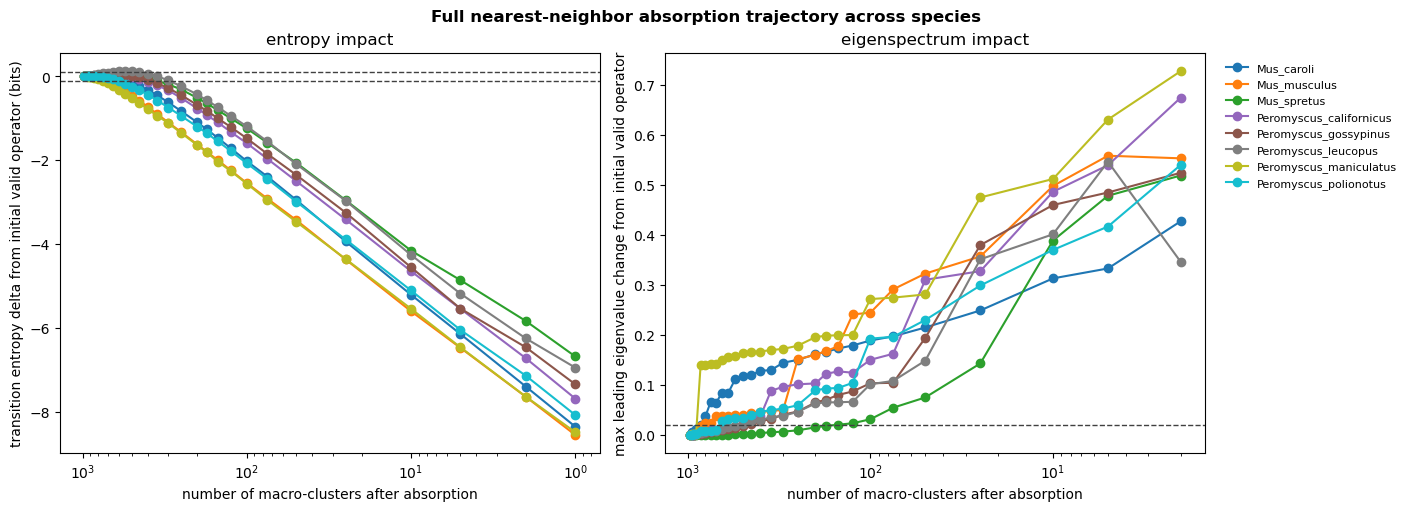

In [67]:
def plot_absorption_across_species():
    palette = dict(zip(species_names, plt.cm.tab10(np.linspace(0, 1, len(species_names)))))
    fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0), constrained_layout=True)

    ax = axes[0]
    for species in species_names:
        df = absorption_trajectory_results.loc[absorption_trajectory_results['species'] == species].sort_values('n_macro_clusters', ascending=False)
        ax.plot(
            df['n_macro_clusters'],
            df['entropy_delta_from_baseline_bits'],
            marker='o',
            linewidth=1.5,
            color=palette[species],
            label=species,
        )
    ax.axhline(ABSORB_ENTROPY_IMPACT_TOLERANCE_BITS, color='0.25', linestyle='--', linewidth=1)
    ax.axhline(-ABSORB_ENTROPY_IMPACT_TOLERANCE_BITS, color='0.25', linestyle='--', linewidth=1)
    ax.invert_xaxis()
    ax.set_xscale('log')
    ax.set_xlabel('number of macro-clusters after absorption')
    ax.set_ylabel('transition entropy delta from initial valid operator (bits)')
    ax.set_title('entropy impact')

    ax = axes[1]
    for species in species_names:
        df = absorption_trajectory_results.loc[absorption_trajectory_results['species'] == species].sort_values('n_macro_clusters', ascending=False)
        ax.plot(
            df['n_macro_clusters'],
            df['max_leading_eigen_delta_from_baseline'],
            marker='o',
            linewidth=1.5,
            color=palette[species],
            label=species,
        )
    ax.axhline(ABSORB_EIGENVALUE_IMPACT_TOLERANCE, color='0.25', linestyle='--', linewidth=1)
    ax.invert_xaxis()
    ax.set_xscale('log')
    ax.set_xlabel('number of macro-clusters after absorption')
    ax.set_ylabel('max leading eigenvalue change from initial valid operator')
    ax.set_title('eigenspectrum impact')
    ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

    fig.suptitle('Full nearest-neighbor absorption trajectory across species', fontsize=12, fontweight='bold')
    fig.savefig(ABSORB_DIR / 'all_species_full_absorption_entropy_and_eigen_impact.png', dpi=PLOT_DPI)
    plt.show()


plot_absorption_across_species()

In [68]:
def selected_operator_for_species(species, min_occupancy=SELECTED_MIN_OCCUPANCY, min_outgoing=SELECTED_MIN_OUTGOING):
    counts = np.asarray(species_transition_counts[species])
    occupancy = species_cluster_occupancy[species]
    active = active_clusters_for_threshold(
        counts,
        occupancy,
        min_occupancy=min_occupancy,
        min_outgoing=min_outgoing,
        require_incoming=REQUIRE_INCOMING_SUPPORT,
    )
    T_active = normalize_counts_on_active_set(counts, active)
    pi = pp.stationary_distribution(T_active)
    eigvals = eigen_summary(T_active)
    return active, T_active, pi, eigvals


if RUN_SELECTED_OPERATOR_EXPORT:
    selected_dir = OUT_DIR / f'selected_min_outgoing_{SELECTED_MIN_OUTGOING}_min_occupancy_{SELECTED_MIN_OCCUPANCY}'
    selected_dir.mkdir(parents=True, exist_ok=True)
    selected_rows = []
    for species in species_names:
        active, T_active, pi, eigvals = selected_operator_for_species(species)
        np.save(selected_dir / f'{species}_active_clusters.npy', active)
        np.save(selected_dir / f'{species}_active_transfer_operator.npy', T_active)
        np.save(selected_dir / f'{species}_active_stationary_distribution.npy', pi)
        np.save(selected_dir / f'{species}_active_eigenvalues.npy', eigvals)
        selected_rows.append({
            'species': species,
            'min_occupancy': int(SELECTED_MIN_OCCUPANCY),
            'min_outgoing': int(SELECTED_MIN_OUTGOING),
            'n_active_clusters': int(active.size),
            'pi_max': float(pi.max()),
            'lambda_2_abs': float(np.abs(eigvals[0])) if eigvals.size else np.nan,
            'lambda_3_abs': float(np.abs(eigvals[1])) if eigvals.size > 1 else np.nan,
            'lambda_4_abs': float(np.abs(eigvals[2])) if eigvals.size > 2 else np.nan,
        })
    selected_summary = pd.DataFrame(selected_rows)
    selected_summary.to_csv(selected_dir / 'selected_threshold_operator_summary.csv', index=False)
    display(selected_summary)

,species,min_occupancy,min_outgoing,n_active_clusters,pi_max,lambda_2_abs,lambda_3_abs,lambda_4_abs
0,Mus_caroli,1,50,972,0.005918,0.557373,0.438058,0.354997
1,Mus_musculus,1,50,990,0.005378,0.775107,0.637989,0.609128
2,Mus_spretus,1,50,894,0.019835,0.837956,0.727720,0.622197
3,Peromyscus_californicus,1,50,952,0.005917,0.799681,0.612424,0.479287
4,Peromyscus_gossypinus,1,50,987,0.008263,0.814261,0.730329,0.531640
5,Peromyscus_leucopus,1,50,961,0.019906,0.892648,0.758074,0.623886
6,Peromyscus_maniculatus,1,50,989,0.004179,0.868313,0.775044,0.674942
7,Peromyscus_polionotus,1,50,974,0.004374,0.781580,0.547691,0.448650


In [64]:
# Inspect Mus musculus specifically, since the previous species operator was
# distorted by a visited cluster with incoming transitions and zero outgoing support.
mus = 'Mus_musculus'
if mus in species_names:
    counts = np.asarray(species_transition_counts[mus])
    occupancy = species_cluster_occupancy[mus]
    outgoing = counts.sum(axis=1)
    incoming = counts.sum(axis=0)
    artifact_candidates = np.flatnonzero((occupancy > 0) & (incoming > 0) & (outgoing == 0))
    print(f'{mus}: incoming-but-no-outgoing clusters = {artifact_candidates.tolist()}')
    if artifact_candidates.size:
        display(pd.DataFrame({
            'cluster': artifact_candidates,
            'occupancy_frames': occupancy[artifact_candidates].astype(int),
            'incoming_transitions': incoming[artifact_candidates].astype(int),
            'outgoing_transitions': outgoing[artifact_candidates].astype(int),
        }))

    display(sweep_results.loc[sweep_results['species'] == mus, [
        'species', 'min_outgoing', 'n_active_clusters', 'retained_occupancy_fraction',
        'retained_within_active_transition_fraction', 'pi_max',
        'stationary_weighted_transition_entropy_bits', 'lambda_2_abs', 'lambda_3_abs',
        'lambda_4_abs', 'status',
    ]])

Mus_musculus: incoming-but-no-outgoing clusters = [637]


,cluster,occupancy_frames,incoming_transitions,outgoing_transitions
0,637,5,5,0


,species,min_outgoing,n_active_clusters,retained_occupancy_fraction,retained_within_active_transition_fraction,pi_max,stationary_weighted_transition_entropy_bits,lambda_2_abs,lambda_3_abs,lambda_4_abs,status
9,Mus_musculus,1,996,1.000000,1.000000,0.005378,8.554482,0.775107,0.637989,0.609128,ok
10,Mus_musculus,5,995,1.000000,1.000000,0.005378,8.554483,0.775107,0.637989,0.609128,ok
11,Mus_musculus,10,994,1.000000,1.000000,0.005378,8.554483,0.775107,0.637989,0.609128,ok
12,Mus_musculus,25,992,0.999999,0.999999,0.005378,8.554483,0.775107,0.637989,0.609128,ok
13,Mus_musculus,50,990,0.999999,0.999997,0.005378,8.554483,0.775107,0.637989,0.609128,ok
14,Mus_musculus,100,982,0.999991,0.999982,0.005378,8.554481,0.775095,0.637778,0.609128,ok
15,Mus_musculus,250,969,0.999966,0.999932,0.005379,8.554462,0.775097,0.637777,0.609211,ok
16,Mus_musculus,500,948,0.999880,0.999760,0.005380,8.554343,0.775104,0.637774,0.609313,ok
17,Mus_musculus,1000,932,0.999753,0.999506,0.005381,8.554028,0.775099,0.637774,0.609425,ok


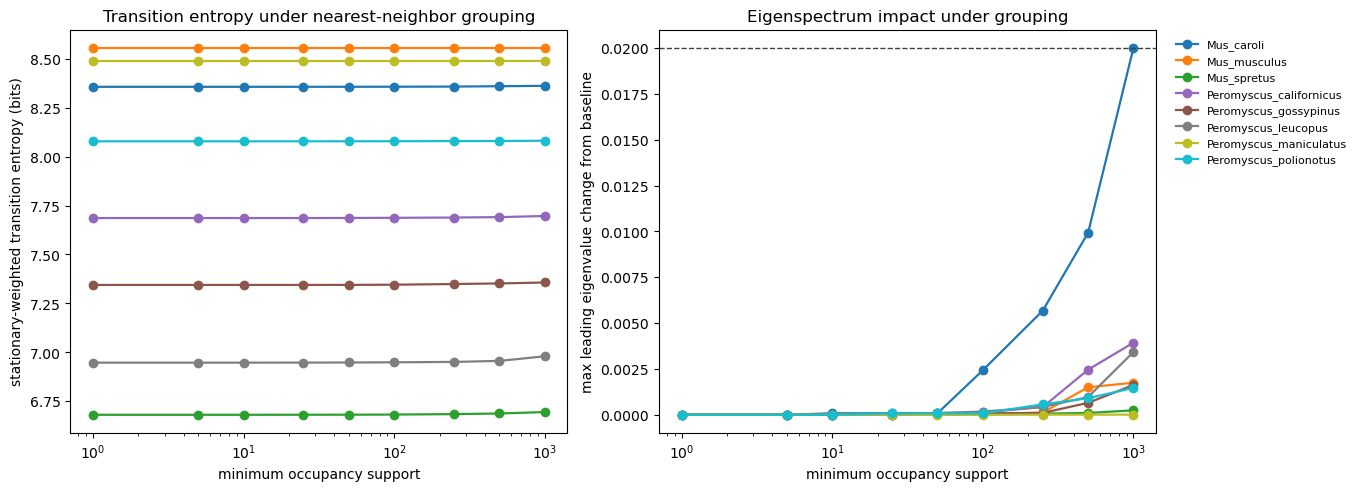

In [69]:
species_palette = dict(zip(
    species_names,
    plt.cm.tab10(np.linspace(0, 1, len(species_names)))
))

def plot_grouping_summary_across_species():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True)

    ax = axes[0]
    for species in species_names:
        df = grouping_sweep_results.loc[grouping_sweep_results['species'] == species].sort_values('min_support')
        ax.plot(
            df['min_support'],
            df['stationary_weighted_transition_entropy_bits'],
            marker='o',
            linewidth=1.6,
            color=species_palette[species],
            label=species,
        )
    ax.set_xscale('log')
    ax.set_xlabel(f'minimum {GROUPING_SUPPORT_METRIC} support')
    ax.set_ylabel('stationary-weighted transition entropy (bits)')
    ax.set_title('Transition entropy under nearest-neighbor grouping')

    ax = axes[1]
    for species in species_names:
        df = grouping_sweep_results.loc[grouping_sweep_results['species'] == species].sort_values('min_support')
        ax.plot(
            df['min_support'],
            df['max_leading_eigen_delta_from_baseline'],
            marker='o',
            linewidth=1.6,
            color=species_palette[species],
            label=species,
        )
    ax.axhline(GROUPING_EIGENVALUE_IMPACT_TOLERANCE, color='0.25', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_xlabel(f'minimum {GROUPING_SUPPORT_METRIC} support')
    ax.set_ylabel('max leading eigenvalue change from baseline')
    ax.set_title('Eigenspectrum impact under grouping')

    axes[1].legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.savefig(GROUPING_DIR / 'all_species_grouping_entropy_and_eigen_impact.png', dpi=PLOT_DPI)
    plt.show()

plot_grouping_summary_across_species()